<a href="https://colab.research.google.com/github/ottrindade1963/analise-industrialXL/blob/main/Pipeline_Africa_MO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline de Análise Industrial - África e Médio Oriente

## Passos 1 a 9 com Geração Automática de Metadados

Este notebook executa o fluxo completo de análise de dados para 37 países da África e Médio Oriente, utilizando dados do Banco Mundial (WDI + WGI).

**Características:**
- Clonagem automática do repositório GitHub
- Extração automática via API (WDI + WGI)
- Agregação INNER JOIN + Dados Sintéticos (500 anos)
- Engenharia de Features avançada (lags, MA, deltas, interações)
- 7 Modelos (5 Clássicos + 2 Bayesianos)
- Interpretabilidade SHAP + Análise Geográfica
- **Sincronização simultânea de TODOS os ficheiros no Google Drive**
- **Visualização inline de TODAS as imagens geradas em cada passo**

## 0. Configuração Inicial do Colab

In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive montado em /content/drive")

Mounted at /content/drive
✓ Google Drive montado em /content/drive


In [2]:
# Instalar dependências
!pip install -q wbgapi pmdarima xgboost shap geopandas pymc arviz tensorflow scipy
print("✓ Dependências instaladas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.3 MB/s eta 0:00:00
✓ Dependências instaladas


In [3]:
# Clonar repositório GitHub
!git clone https://github.com/ottrindade1963/analise-industrialXL.git /content/repo
print("✓ Repositório clonado do GitHub")

Cloning into '/content/repo'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 69 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 164.17 KiB | 1.26 MiB/s, done.
Resolving deltas: 100% (27/27), done.
✓ Repositório clonado do GitHub


In [4]:
import os
import sys
import time
import shutil
import glob
from datetime import datetime
from pathlib import Path
from IPython.display import display, Image, HTML

# Configurar paths
REPO_DIR = '/content/repo'  # Repositório clonado do GitHub
PIPELINE_DIR = os.path.join(REPO_DIR, 'pipeline_africa_mo')  # Subdiretório do pipeline
DRIVE_DIR = '/content/drive/MyDrive/pipeline_africa_mo_resultados'  # Resultados no Drive

# Verificar se o pipeline está no subdiretório ou na raiz
if not os.path.exists(PIPELINE_DIR):
    PIPELINE_DIR = REPO_DIR  # Se estiver na raiz

os.chdir(PIPELINE_DIR)
sys.path.insert(0, PIPELINE_DIR)

# Criar diretório de resultados no Drive
os.makedirs(DRIVE_DIR, exist_ok=True)

print(f"✓ Diretório de trabalho: {PIPELINE_DIR}")
print(f"✓ Diretório de resultados (Drive): {DRIVE_DIR}")
print(f"\n  Ficheiros do pipeline:")
for f in sorted(os.listdir(PIPELINE_DIR)):
    if f.endswith('.py') or f.endswith('.md'):
        print(f"    {f}")

✓ Diretório de trabalho: /content/repo
✓ Diretório de resultados (Drive): /content/drive/MyDrive/pipeline_africa_mo_resultados

  Ficheiros do pipeline:
    Pipeline_Africa_MO_Completo.py
    README.md
    config_global.py
    metadata_generator.py
    passo1_extracao.py
    passo2_1_limpeza.py
    passo2_2_agregacao_sinteticos.py
    passo2_3_eda_agregados.py
    passo2_eda_brutos.py
    passo3_engenharia_features.py
    passo4_treino_modelos.py
    passo5_avaliacao.py
    passo6_estrategias.py
    passo7_shap.py
    passo8_geografica.py
    passo9_avancada.py


In [5]:
# Função auxiliar para sincronizar TODOS os ficheiros gerados com o Drive
def sincronizar_todos_drive():
    """
    Sincroniza TODOS os diretórios de resultados com o Google Drive.
    Chamada após cada passo para backup simultâneo.
    """
    diretorio_saida = [
        'dados_brutos',
        'dados_limpos',
        'dados_agregados',
        'dados_sinteticos',
        'dados_engenharia',
        'eda_brutos',
        'eda_agregados',
        'eda_engenharia',
        'modelos_treinados',
        'resultados_avaliacao',
        'analise_estrategias',
        'shap_analysis',
        'analise_geografica',
        'analise_avancada',
        'metadados'
    ]

    ficheiros_sincronizados = 0

    for dir_name in diretorio_saida:
        origem = os.path.join(PIPELINE_DIR, dir_name)
        if not os.path.exists(origem):
            continue

        destino = os.path.join(DRIVE_DIR, dir_name)
        os.makedirs(destino, exist_ok=True)

        # Sincronizar ficheiros (incluindo subdirectórios)
        for root, dirs, files in os.walk(origem):
            rel_path = os.path.relpath(root, origem)
            dest_root = os.path.join(destino, rel_path) if rel_path != '.' else destino
            os.makedirs(dest_root, exist_ok=True)
            for f in files:
                src = os.path.join(root, f)
                dst = os.path.join(dest_root, f)
                shutil.copy2(src, dst)
                ficheiros_sincronizados += 1

    return ficheiros_sincronizados


def mostrar_imagens(diretorios, titulo=None):
    """
    Mostra inline TODAS as imagens PNG encontradas nos directórios especificados.
    Pesquisa recursivamente em subdirectórios.

    Args:
        diretorios: lista de caminhos absolutos ou relativos a PIPELINE_DIR
        titulo: título opcional para o bloco de imagens
    """
    imagens = []
    for d in diretorios:
        # Resolver caminho absoluto
        if not os.path.isabs(d):
            d = os.path.join(PIPELINE_DIR, d)
        if not os.path.exists(d):
            continue
        # Buscar PNGs recursivamente
        for root, dirs, files in os.walk(d):
            for f in sorted(files):
                if f.lower().endswith('.png'):
                    imagens.append(os.path.join(root, f))

    if not imagens:
        print("  (Nenhuma imagem gerada neste passo)")
        return

    if titulo:
        display(HTML(f'<h3>📊 {titulo} ({len(imagens)} imagens)</h3>'))
    else:
        display(HTML(f'<h3>📊 Visualizações geradas ({len(imagens)} imagens)</h3>'))

    for img_path in imagens:
        # Mostrar nome do ficheiro como legenda
        nome_ficheiro = os.path.basename(img_path)
        subdir = os.path.basename(os.path.dirname(img_path))
        display(HTML(f'<hr><b>{subdir}/{nome_ficheiro}</b>'))
        display(Image(filename=img_path, width=900))

    print(f"\n  ✓ {len(imagens)} imagens visualizadas")


print("✓ Funções auxiliares definidas (sincronização + visualização de imagens)")

✓ Funções auxiliares definidas (sincronização + visualização de imagens)


---
## 1. Extração de Dados (WDI + WGI)

In [6]:
print("\n" + "="*70)
print("  PASSO 1: EXTRAÇÃO DE DADOS VIA API")
print("="*70)

t0 = time.time()
from passo1_extracao import executar_passo1
executar_passo1()

tempo_p1 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p1:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")
# Passo 1 não gera imagens (apenas CSVs de dados brutos)


  PASSO 1: EXTRAÇÃO DE DADOS VIA API

  PASSO 1: EXTRAÇÃO DE DADOS - INÍCIO
PASSO 1.1: Extração de dados WDI
  Países: 37
  Indicadores: 19
  Período: 1996-2023
  Extraindo: valor_agregado_industrial_percent_pib (NV.IND.TOTL.ZS)...
    ✓ 1036 registos
  Extraindo: pib_per_capita_ppc (NY.GDP.PCAP.PP.KD)...
    ✓ 1036 registos
  Extraindo: crescimento_pib_anual (NY.GDP.MKTP.KD.ZG)...
    ✓ 1036 registos
  Extraindo: formacao_bruta_capital_fixo_percent_pib (NE.GDI.FTOT.ZS)...
    ✓ 1036 registos
  Extraindo: ied_percent_pib (BX.KLT.DINV.WD.GD.ZS)...
    ✓ 1036 registos
  Extraindo: comercio_percent_pib (NE.TRD.GNFS.ZS)...
    ✓ 1036 registos
  Extraindo: exportacoes_percent_pib (NE.EXP.GNFS.ZS)...
    ✓ 1036 registos
  Extraindo: importacoes_percent_pib (NE.IMP.GNFS.ZS)...
    ✓ 1036 registos
  Extraindo: consumo_eletricidade_per_capita (EG.USE.ELEC.KH.PC)...
    ✓ 1036 registos
  Extraindo: utilizadores_internet_percent (IT.NET.USER.ZS)...
    ✓ 1036 registos
  Extraindo: despesa_id_per

---
## 2. EDA dos Dados Brutos

In [7]:
print("\n" + "="*70)
print("  PASSO 2: EDA DOS DADOS BRUTOS")
print("="*70)

t0 = time.time()
from passo2_eda_brutos import executar_passo2
executar_passo2()

tempo_p2 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p2:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 2: EDA DOS DADOS BRUTOS

PASSO 2: ANÁLISE EXPLORATÓRIA DOS DADOS BRUTOS

  === EDA: WDI ===
  Shape: (1036, 22)
  Países: 37
  Anos: 1996-2023

  === EDA: WGI ===
  Shape: (925, 9)
  Países: 37
  Anos: 1996-2023
[METADADOS] passo2_eda_brutos → /content/repo/metadados/passo2_eda_brutos_metadata.json
[AUTO-SAVE] 9 ficheiros copiados para Google Drive

  ✓ PASSO 2 CONCLUÍDO

  ⏱ Tempo: 9.9s
  📁 13 ficheiros sincronizados com o Drive


In [ ]:
# Visualizar imagens geradas no Passo 2
mostrar_imagens(['eda_brutos'], titulo='Passo 2 - EDA Dados Brutos')

---
## 2.1. Limpeza de Dados

In [8]:
print("\n" + "="*70)
print("  PASSO 2.1: LIMPEZA DE DADOS")
print("="*70)

t0 = time.time()
from passo2_1_limpeza import executar_passo2_1
executar_passo2_1()

tempo_p2_1 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p2_1:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 2.1: LIMPEZA DE DADOS

PASSO 2.1: LIMPEZA E EDA - MICE SEM WINSORIZAÇÃO

  WDI bruto: (1036, 22)
  WGI bruto: (925, 9)

  === LIMPEZA WDI (Quantitativo - MICE) ===
  Shape original: (1036, 22)
  Missing: 2348 valores

  [1] MICE (IterativeImputer) por país...
      Variáveis numéricas: 19
      max_iter=20, random_state=42
      Valores imputados por MICE: 1824
      Missing residuais após MICE: 524

  [2] Preenchimento de NaN residuais (mediana por país)...

  [✓] Winsorização NÃO aplicada (preserva eventos extremos reais)
      Justificação: outliers em economias emergentes representam
      eventos reais (crises, recuperações pós-conflito).
      Modelos de árvores (RF, XGBoost) são robustos a outliers.

  Shape final: (1036, 22)
  Missing residuais: 0

  === LIMPEZA WGI (Qualitativo - Governança - MICE) ===
  Shape original: (925, 9)
  Missing: 0 valores

  [✓] Sem valores faltantes - nenhuma imputação necessária
  [✓] Escala WGI original preservada (-2.5 a +2.5)

  Shape 

In [ ]:
# Visualizar imagens geradas no Passo 2.1 (EDA WDI + WGI limpos)
mostrar_imagens(
    [os.path.join('dados_limpos', 'eda_wdi'), os.path.join('dados_limpos', 'eda_wgi')],
    titulo='Passo 2.1 - EDA após Limpeza (WDI + WGI)'
)

---
## 2.2. Agregação INNER JOIN + Dados Sintéticos

In [9]:
print("\n" + "="*70)
print("  PASSO 2.2: AGREGAÇÃO INNER JOIN + DADOS SINTÉTICOS (500 ANOS)")
print("="*70)

t0 = time.time()
from passo2_2_agregacao_sinteticos import executar_passo2_2
executar_passo2_2()

tempo_p2_2 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p2_2:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")
# Passo 2.2 não gera imagens (apenas CSVs de dados agregados e sintéticos)


  PASSO 2.2: AGREGAÇÃO INNER JOIN + DADOS SINTÉTICOS (500 ANOS)

PASSO 2.2: AGREGAÇÃO INNER JOIN + DADOS SINTÉTICOS

  === Agregação: INNER JOIN ===
  WDI: (1036, 22)
  WGI: (925, 9)
  Resultado INNER JOIN: (925, 28)
  Países no resultado: 37
  Anos: 1996-2023
  ✓ Integridade verificada: 925 registos únicos

  ✓ Agregado salvo: /content/repo/dados_agregados/agregado_inner_join.csv

  === Geração de Dados Sintéticos (500 anos) ===
    Processando país 10/37: ETH
    Processando país 20/37: MAR
    Processando país 30/37: SEN
  Dataset sintético: (18500, 28)
  Países: 37
  Anos: 2024-2523
  ✓ Sintético salvo: /content/repo/dados_sinteticos/sintetico_500anos.csv
  ✓ Combinado salvo: /content/repo/dados_sinteticos/combinado_real_sintetico.csv

  === Geração de WDI Sintético (500 anos, sem WGI) ===

  === Geração de Dados Sintéticos (500 anos) ===
    Processando país 10/37: ETH
    Processando país 20/37: MAR
    Processando país 30/37: SEN
  Dataset sintético: (18500, 22)
  Países: 37
  

---
## 2.3. EDA Agregados + Sintéticos

In [10]:
print("\n" + "="*70)
print("  PASSO 2.3: EDA AGREGADOS + SINTÉTICOS")
print("="*70)

t0 = time.time()
from passo2_3_eda_agregados import executar_passo2_3
executar_passo2_3()

tempo_p2_3 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p2_3:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 2.3: EDA AGREGADOS + SINTÉTICOS

PASSO 2.3: EDA AGREGADOS + SINTÉTICOS

  === EDA: agregado_real ===

  === EDA: sintetico_500 ===
[METADADOS] passo2_3_eda_agregados → /content/repo/metadados/passo2_3_eda_agregados_metadata.json
[AUTO-SAVE] 11 ficheiros copiados para Google Drive

  ✓ PASSO 2.3 CONCLUÍDO

  ⏱ Tempo: 16.3s
  📁 40 ficheiros sincronizados com o Drive


In [ ]:
# Visualizar imagens geradas no Passo 2.3
mostrar_imagens(['eda_agregados'], titulo='Passo 2.3 - EDA Agregados e Sintéticos')

---
## 3. Engenharia de Features

In [11]:
print("\n" + "="*70)
print("  PASSO 3: ENGENHARIA DE FEATURES AVANÇADA")
print("="*70)

t0 = time.time()
from passo3_engenharia_features import executar_passo3
executar_passo3()

tempo_p3 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p3:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")



  PASSO 3: ENGENHARIA DE FEATURES AVANÇADA

PASSO 3: ENGENHARIA DE FEATURES - ESTRATÉGIA PARCIMONIOSA (A2)
  Princípios: PCA train-only | Lags max=2 | WGI removidos | Ratio >3

----------------------------------------------------------------------
DATASET 1: WDI LIMPO (SEM WGI)
----------------------------------------------------------------------

  === Engenharia de Features (Parcimoniosa): wdi_limpo ===
  Shape original: (1036, 22)

  [PCA] Estratégia A2 - Fator Latente (train-only)...
    (Sem variáveis WGI - PCA não aplicável a este dataset)
  [2] Lags quantitativos (1): 16 features
  [3] Lags target (1,2): 2 features
  [6] Log-retornos: 4 features

  Total features criadas: 22
  Shape final: (962, 44)
  Ratio observações/features: 43.7 (recomendado >3)
  Salvo: /content/repo/dados_engenharia/wdi_limpo_features.csv

----------------------------------------------------------------------
DATASET 2: AGREGADO (WDI + WGI) — DATASET PRINCIPAL
-------------------------------------------

In [ ]:
# Visualizar imagens geradas no Passo 3 (PCA e análise de features)
mostrar_imagens(['eda_engenharia'], titulo='Passo 3 - Engenharia de Features (PCA e Análise)')

---
## 4. Treinamento de 7 Modelos

In [12]:
print("\n" + "="*70)
print("  PASSO 4: TREINAMENTO DE 7 MODELOS")
print("  (5 Clássicos: RF, XGBoost, GradientBoosting, SARIMAX, LSTM)")
print("  (2 Bayesianos: PartialPooling, CompletePooling)")
print("="*70)

t0 = time.time()
from passo4_treino_modelos import executar_passo4
executar_passo4()

tempo_p4 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p4:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")
# Passo 4 não gera imagens (apenas modelos .pkl e metadados)


  PASSO 4: TREINAMENTO DE 7 MODELOS
  (5 Clássicos: RF, XGBoost, GradientBoosting, SARIMAX, LSTM)
  (2 Bayesianos: PartialPooling, CompletePooling)

  PASSO 4: TREINO COM VALIDAÇÃO WALK-FORWARD TEMPORAL
  Walk-forward: 5 folds (expanding window)
  Modelo final: split 85/15 temporal
  Regularização: forte (L1+L2) para parcimónia com ~25 anos

  MODELOS PCA (do Passo 3): /content/repo/dados_engenharia/pca_models
    ✓ agregado: PCA(3 comp, 94.8% var) + StandardScaler(6 features)
      WGI inputs: ['wgi_controle_corrupcao', 'wgi_eficacia_governo', 'wgi_estabilidade_politica', 'wgi_qualidade_regulatoria', 'wgi_estado_direito', 'wgi_voz_responsabilizacao']
    ✓ sintetico: PCA(3 comp, 92.4% var) + StandardScaler(6 features)
      WGI inputs: ['wgi_controle_corrupcao', 'wgi_eficacia_governo', 'wgi_estabilidade_politica', 'wgi_qualidade_regulatoria', 'wgi_estado_direito', 'wgi_voz_responsabilizacao']

  WDI_Limpo: (962, 44)

  Agregado: (888, 53)
    PCA features (9): ['wgi_pca1', 'wgi_pca1_

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 RMSE=2.490±0.399 | Final:

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 RMSE=2.264 R²=0.922 (64.9s)

    [LSTM] WF: RMSE=2.999±0.316 | Final: RMSE=3.340 R²=0.829 (136.3s)

    [Bayes_PartialPooling] WF: RMSE=10.081±1.393 | Final: RMSE=7.072 R²=0.235 (203.5s)

    [Bayes_CompletePooling] WF: RMSE=5.894±0.984 | Final: RMSE=7.533 R²=0.132 (52.6s)

══════════════════════════════════════════════════════════════════════
  DATASET: Agregado (888 obs × 53 cols)
══════════════════════════════════════════════════════════════════════
    Features: 49 total (PCA: 9, Interações: 4, Quantitativas: 36)
    Walk-forward: 5 folds
      Fold 1: treino (np.int64(1998), np.int64(2011)) (444 obs) → teste (np.int64(2012), np.int64(2013)) (74 obs)
      Fold 2: treino (np.int64(1998), np.int64(2013)) (518 obs) → teste (np.int64(2014), np.int64(2015)) (74 obs)
      Fold 3: treino (np.int64(1998), np.int64(2015)) (592 obs) → teste (np.int64(2016), np.int64(2017)) (74 obs)
      Fold 4: treino (np.int64(1998), np.int64(2017)) (666 obs) → teste (np.int64(2018), np.int64(2019)) (74

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 RMSE=2.648±1.031 | Final: RMSE=2.634 R²=0.891 (55.4s)

    [LSTM] WF:

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 RMSE=3.303±0.605 | Final: RMSE=2.926 R²=0.866 (118.3s)

    [Bayes_PartialPooling] WF: RMSE=9.762±1.183 | Final: RMSE=7.214 R²=0.183 (167.4s)

    [Bayes_CompletePooling] WF: RMSE=6.045±0.962 | Final: RMSE=7.269 R²=0.170 (47.5s)

══════════════════════════════════════════════════════════════════════
  DATASET: Sintetico_Agregado (18426 obs × 53 cols)
  ⚠ SINTÉTICO — apenas para testes de robustez
══════════════════════════════════════════════════════════════════════
    Features: 49 total (PCA: 9, Interações: 4, Quantitativas: 36)
    Walk-forward: 5 folds
      Fold 1: treino (np.int64(2026), np.int64(2274)) (9213 obs) → teste (np.int64(2275), np.int64(2323)) (1813 obs)
      Fold 2: treino (np.int64(2026), np.int64(2323)) (11026 obs) → teste (np.int64(2324), np.int64(2372)) (1813 obs)
      Fold 3: treino (np.int64(2026), np.int64(2372)) (12839 obs) → teste (np.int64(2373), np.int64(2421)) (1813 obs)
      Fold 4: treino (np.int64(2026), np.int64(2421)) (14652 obs) → teste (np.int64

---
## 5. Avaliação de Performance

In [13]:
print("\n" + "="*70)
print("  PASSO 5: AVALIAÇÃO DE PERFORMANCE")
print("="*70)

t0 = time.time()
from passo5_avaliacao import executar_passo5
executar_passo5()

tempo_p5 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p5:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 5: AVALIAÇÃO DE PERFORMANCE

  PASSO 5: AVALIACAO DE PERFORMANCE - 28 MODELOS

  [1/7] Carregando modelos e avaliando em dados de teste...
    Modelos avaliados: 28

  [2/7] Tabela resumo por modelo (media dos 4 datasets)...
    Melhor modelo: SARIMAX (RMSE=2.8674)

  [3/7] Teste Diebold-Mariano (WDI_Limpo vs Agregado)...
    RandomForest: DM=-0.273, p=0.7855, Ganho=-4.4%
    XGBoost: DM=-0.469, p=0.6398, Ganho=-7.2%
    GradientBoosting: DM=-1.604, p=0.1112, Ganho=-27.3%
    SARIMAX: DM=-0.971, p=0.3331, Ganho=-19.9%
    LSTM: DM=1.003, p=0.3175, Ganho=10.2%
    Bayes_PartialPooling: DM=-0.093, p=0.9260, Ganho=-0.8%
    Bayes_CompletePooling: DM=0.922, p=0.3580, Ganho=5.5%
    Significativos (p<0.05): 0/7

  [4/7] IC 95% via bootstrap (1000 iteracoes)...
    IC calculados para 28 combinacoes modelo-dataset

  [5/7] Ganho percentual de WGI...
    Ganho medio RMSE: -4.14%
    Ganho medio R2: -0.0125

  [6/7] Ranking final de modelos...
    Ranking (RMSE medio):
      1. SARIMAX

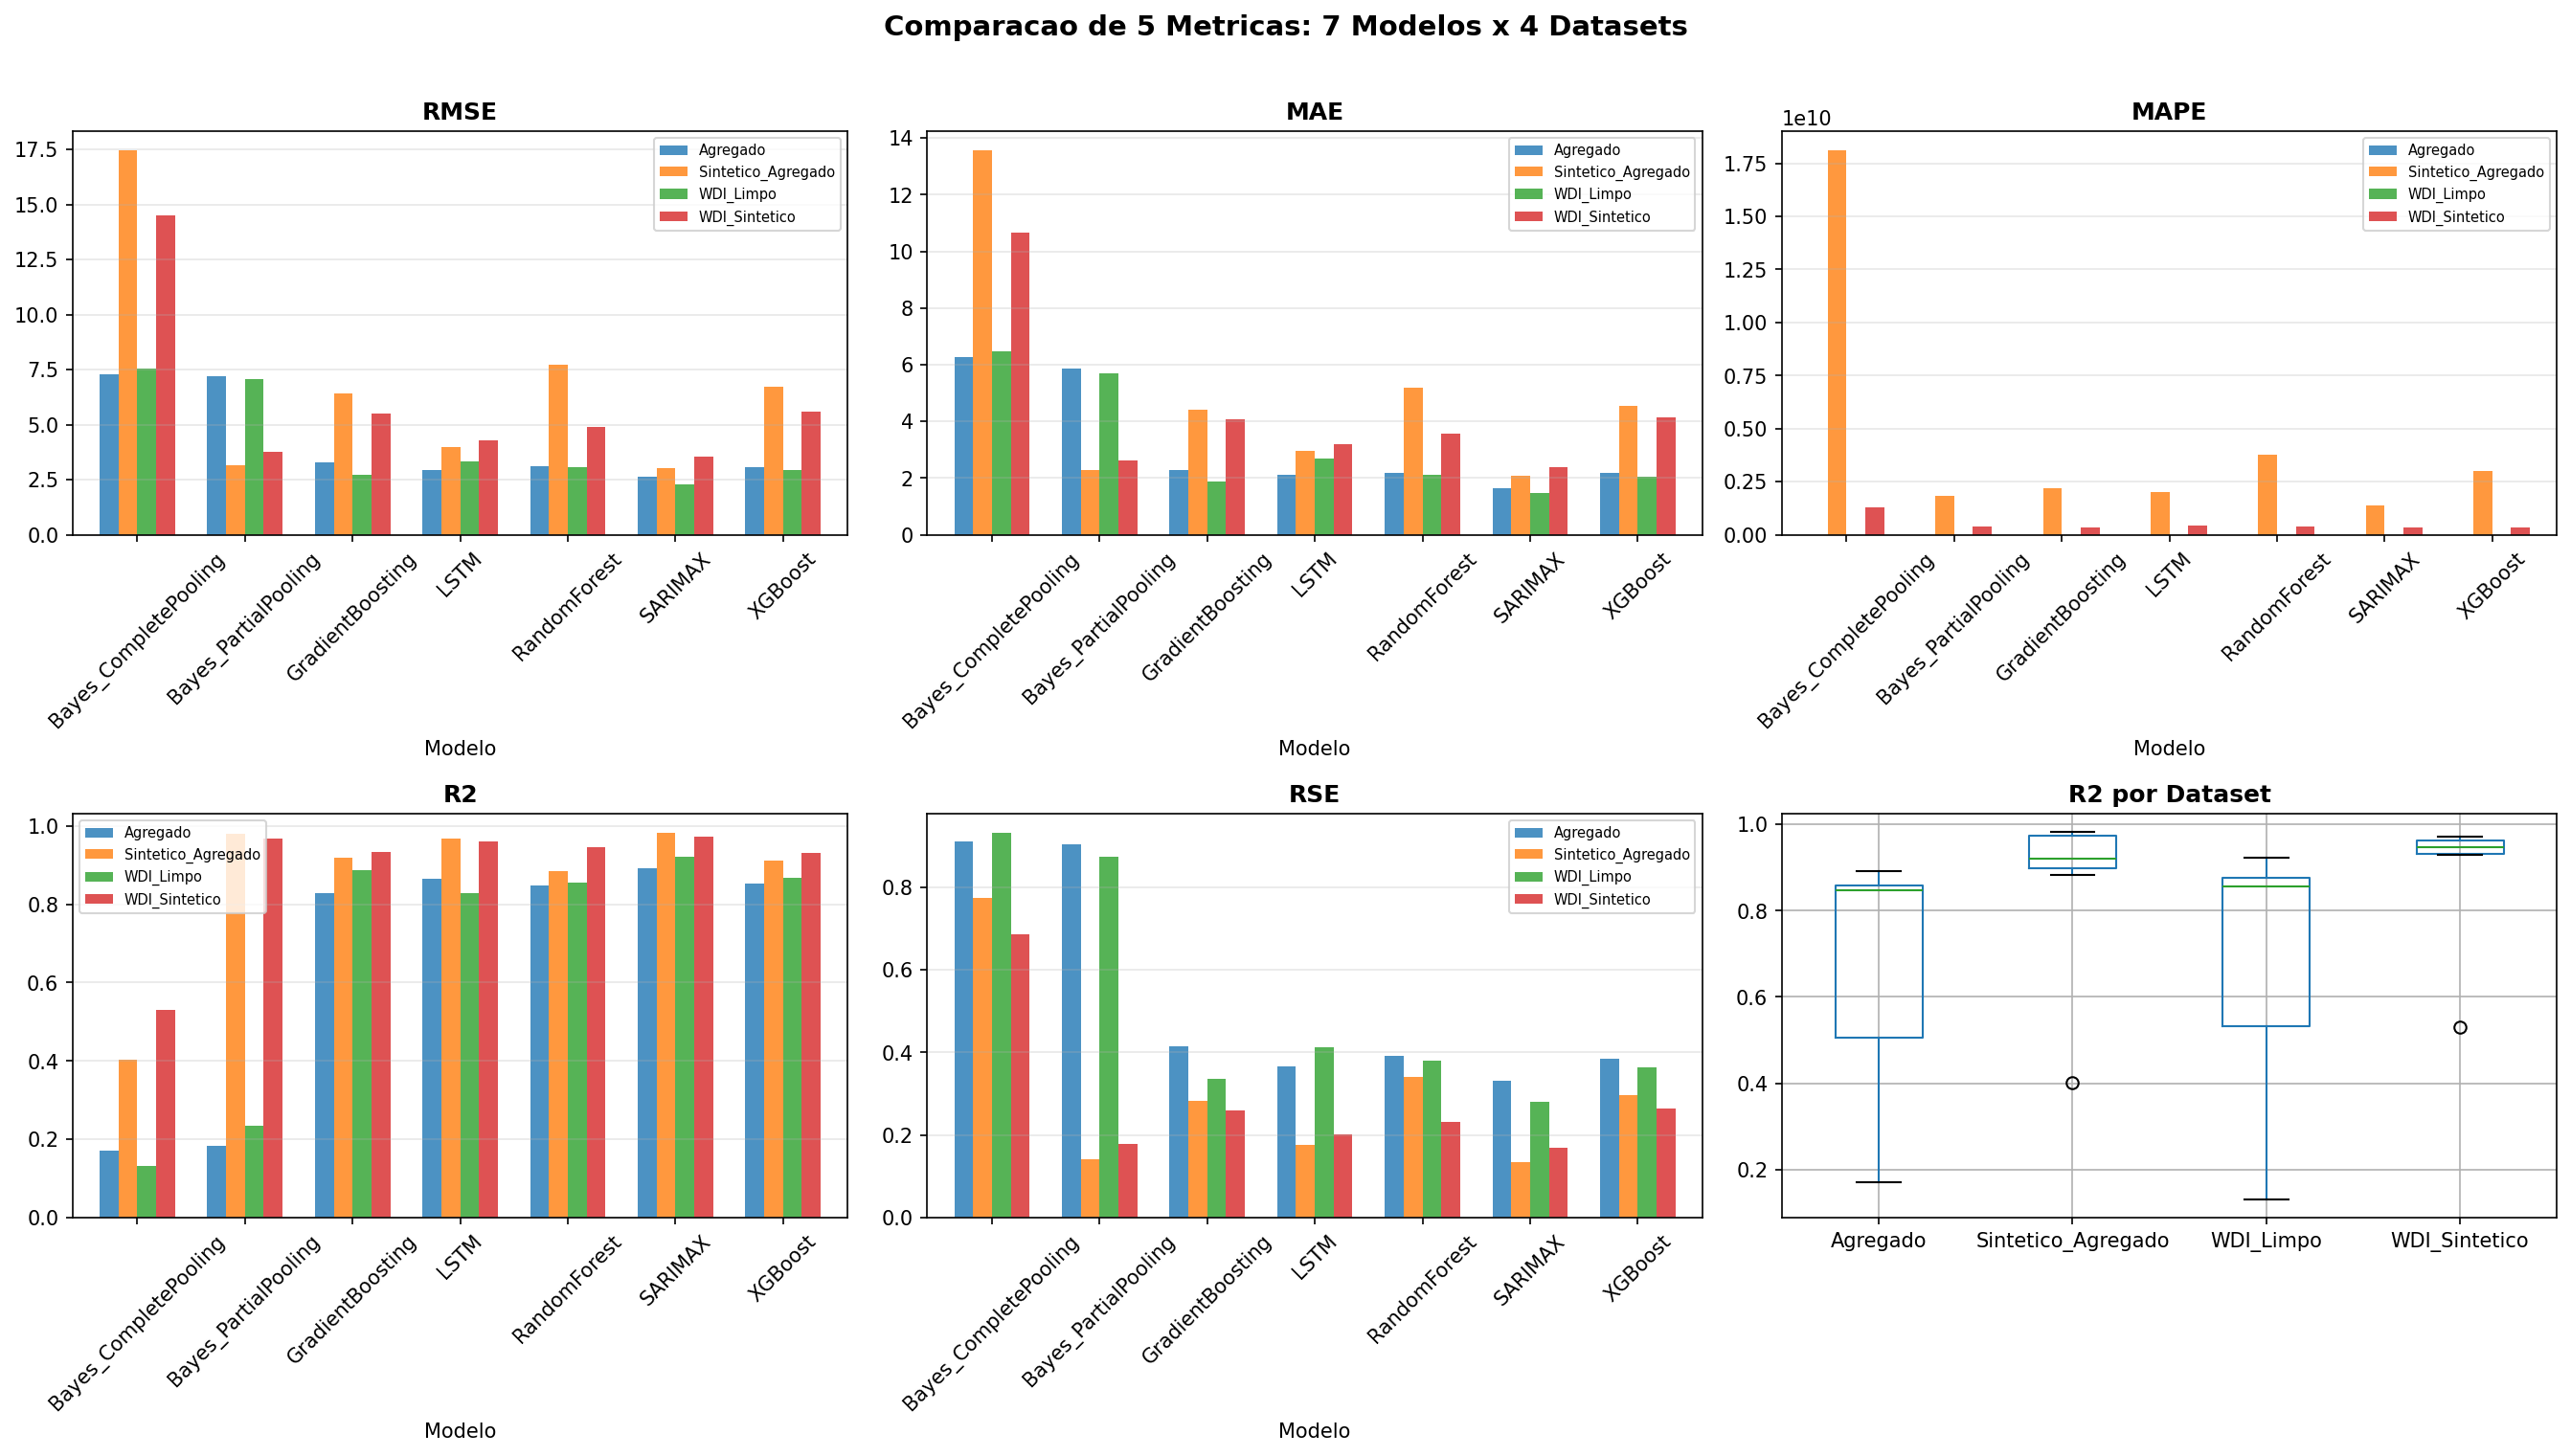

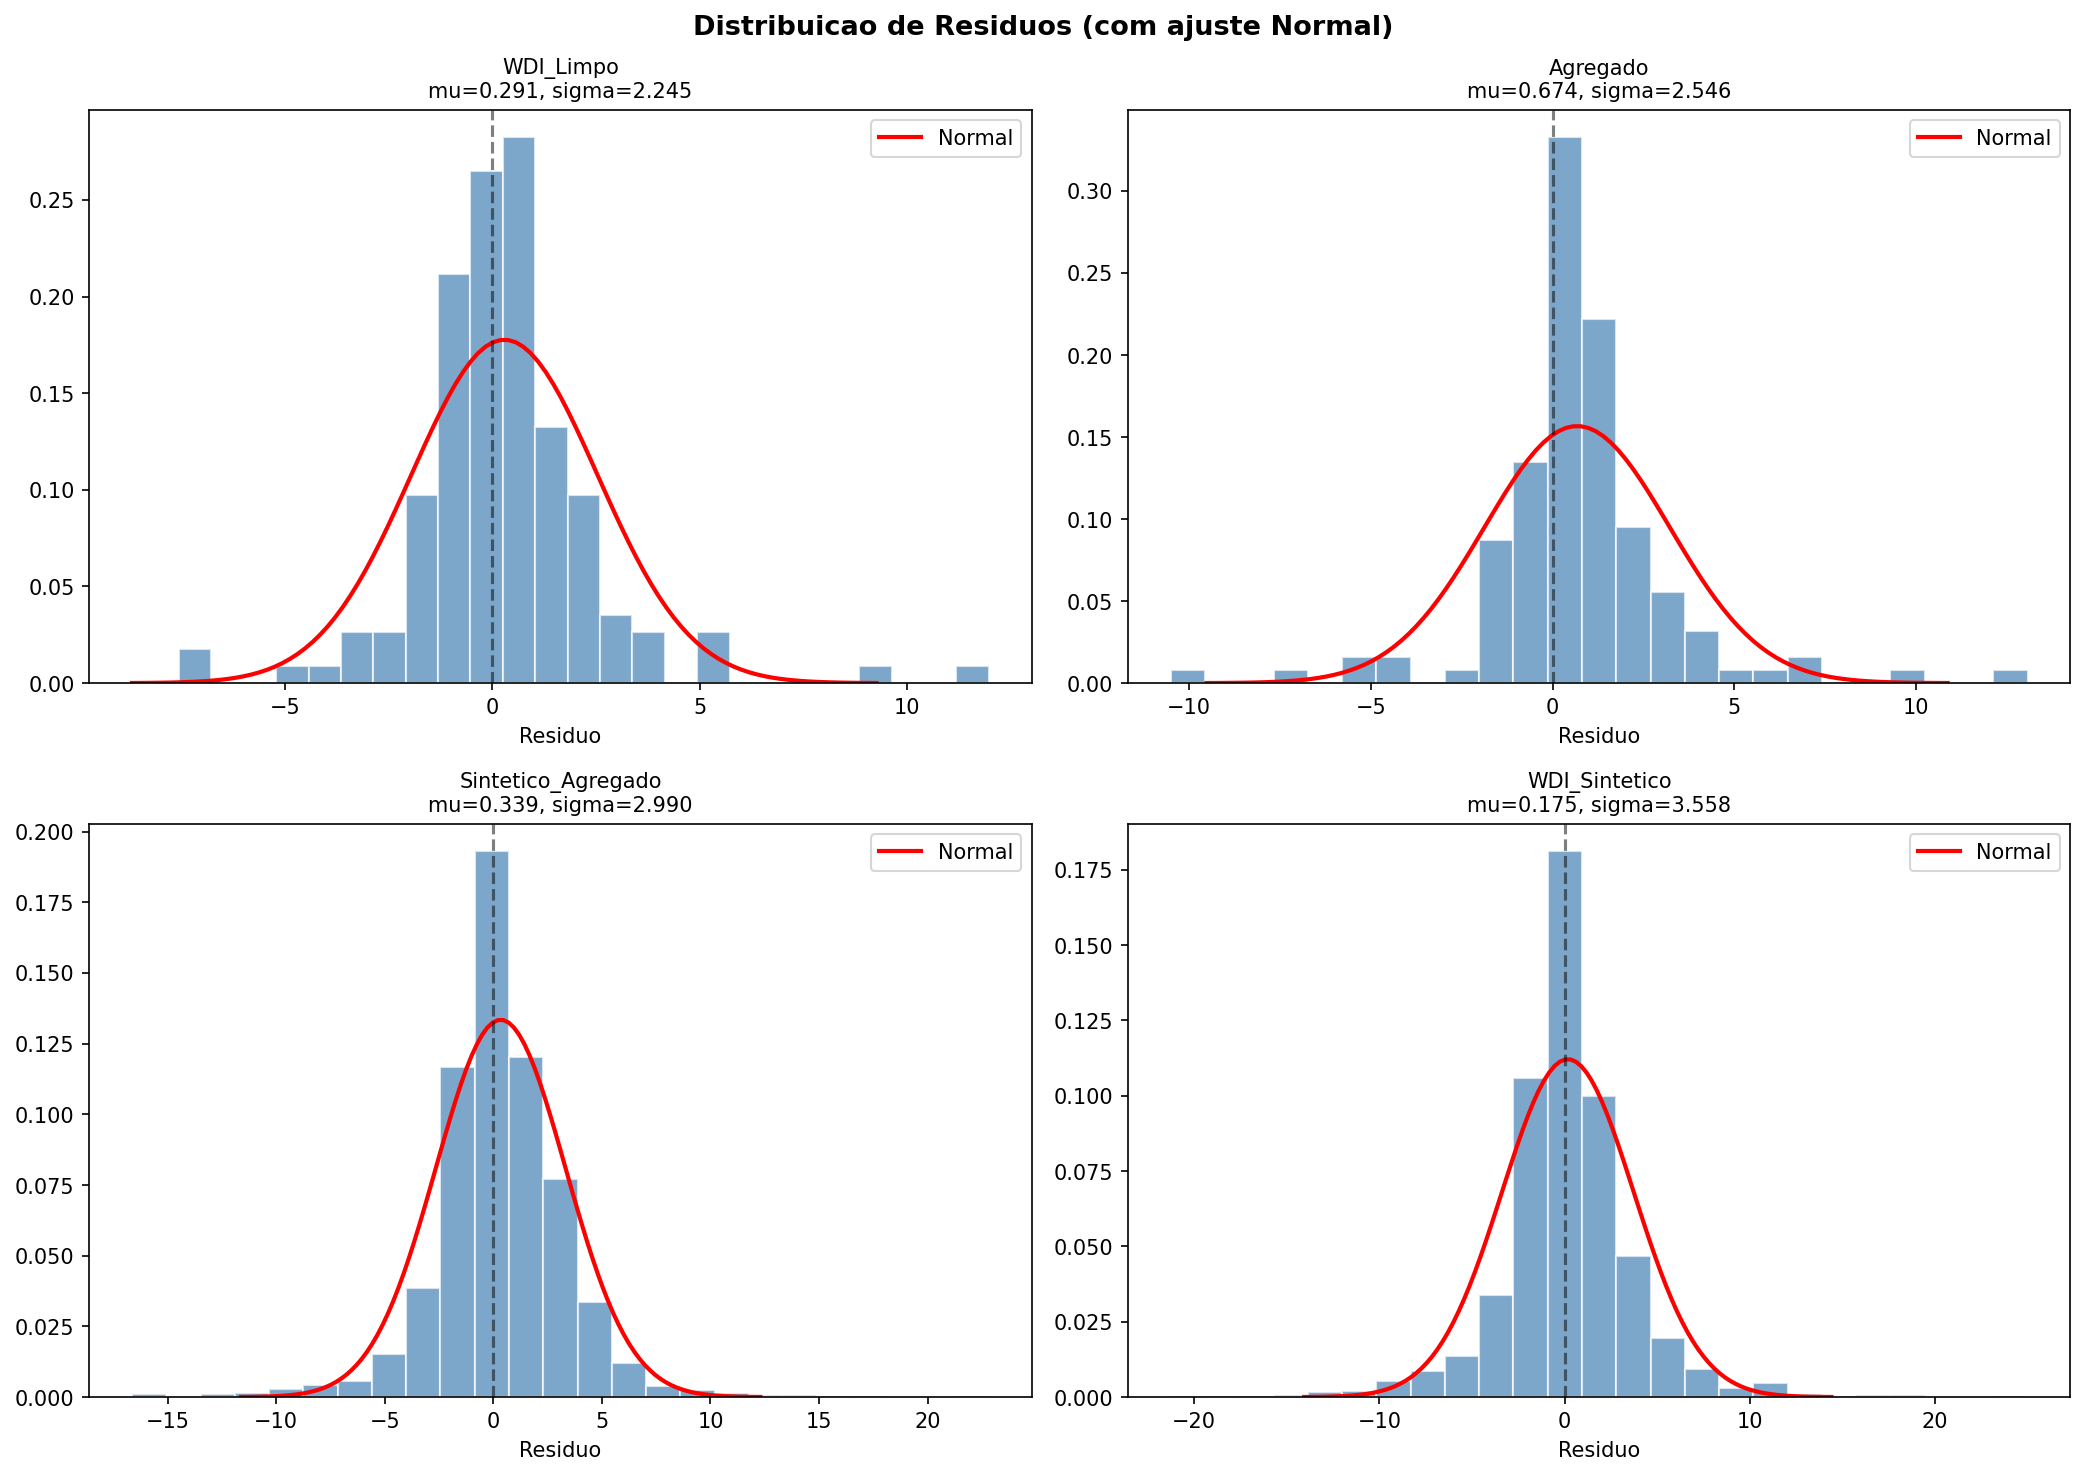

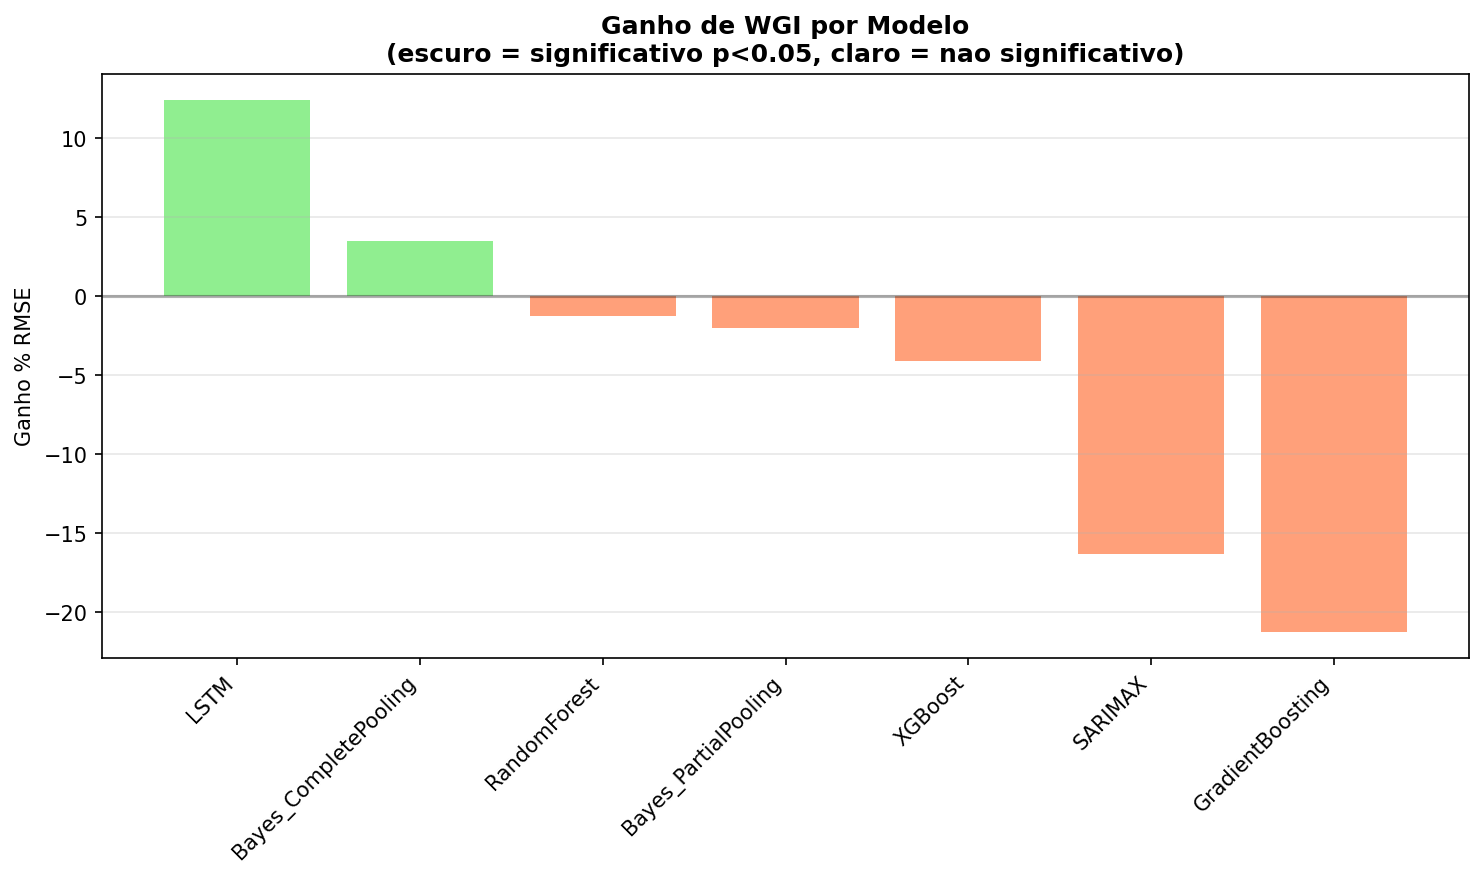

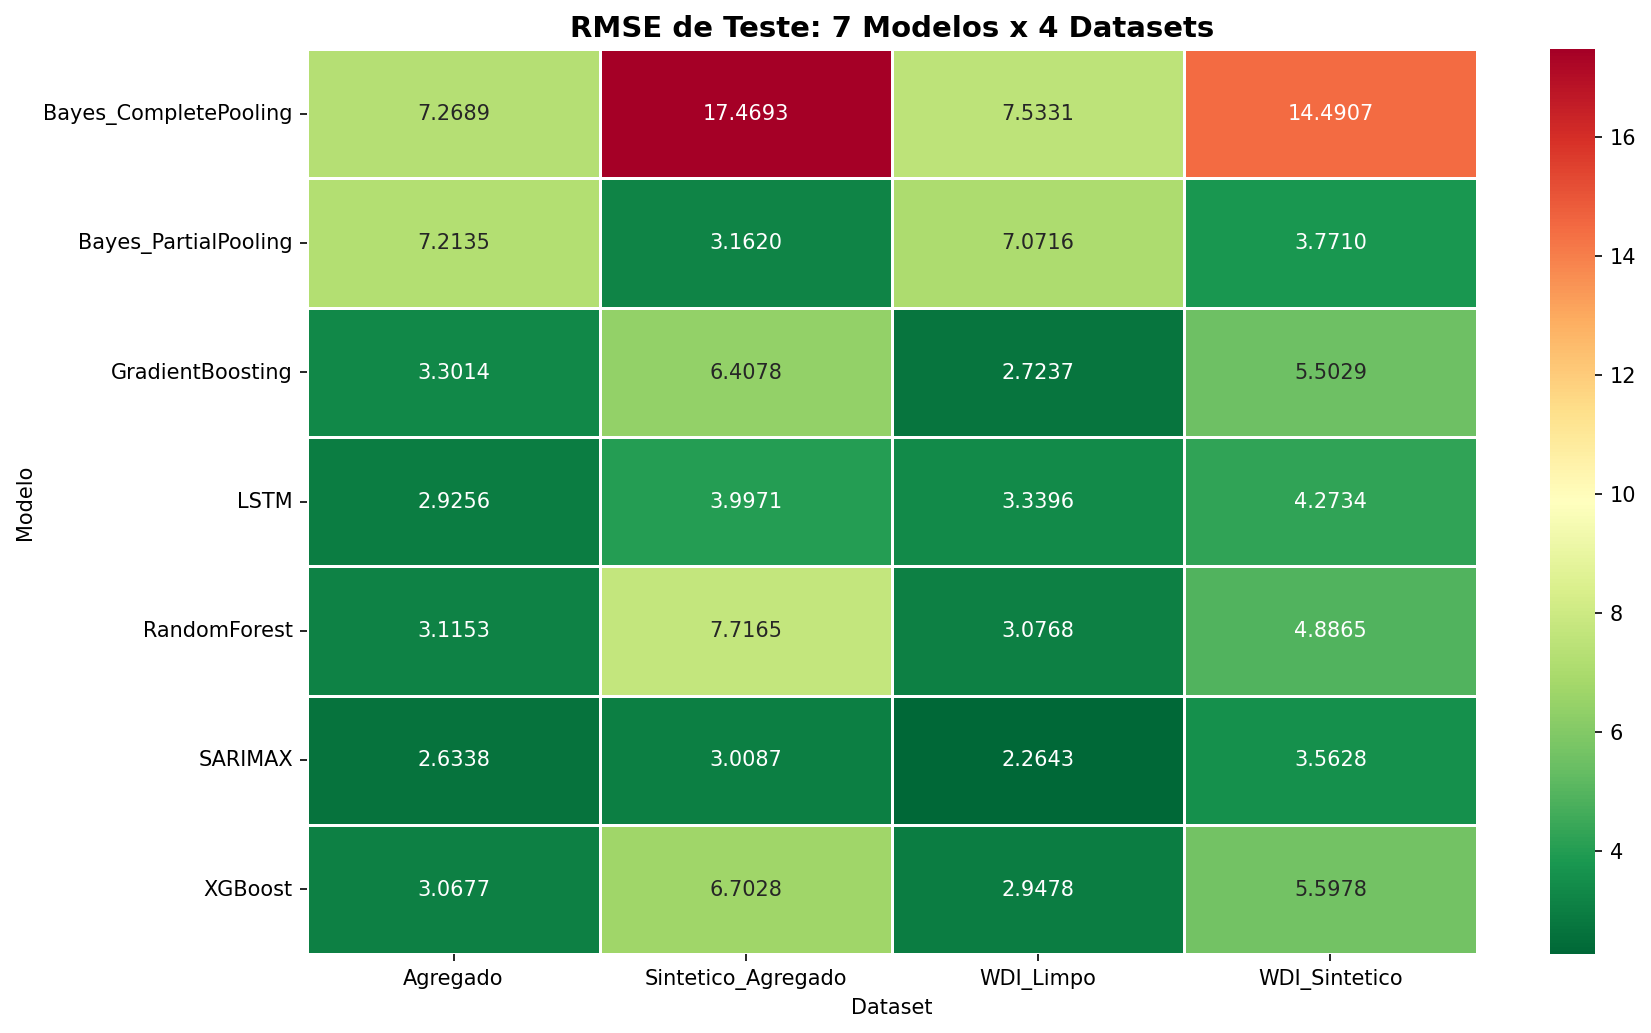

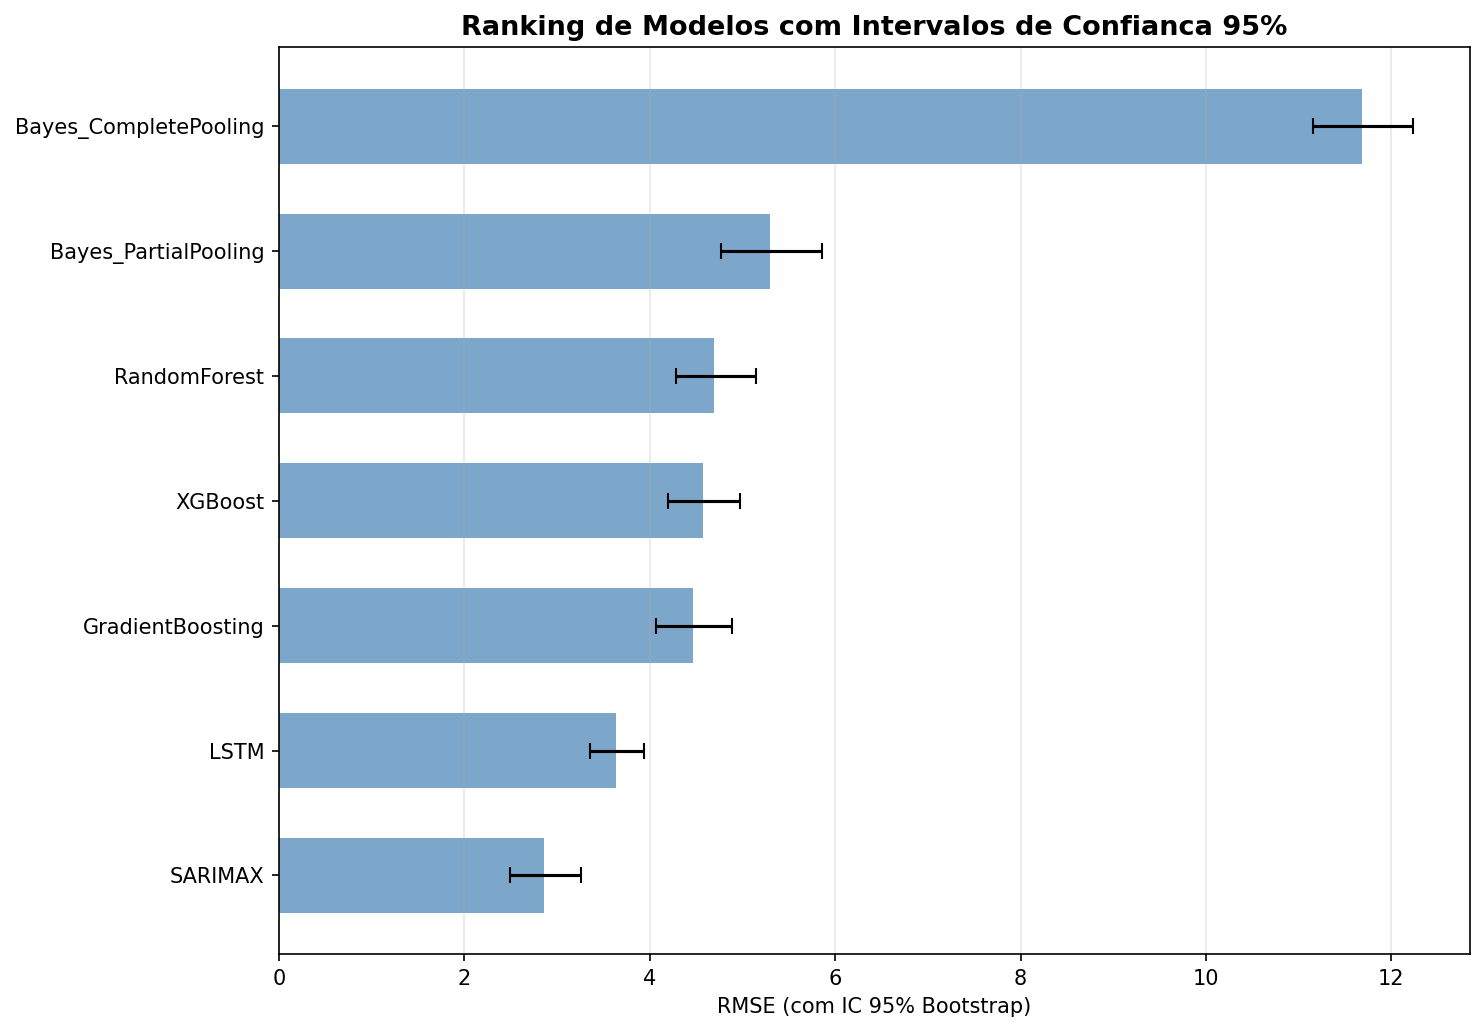

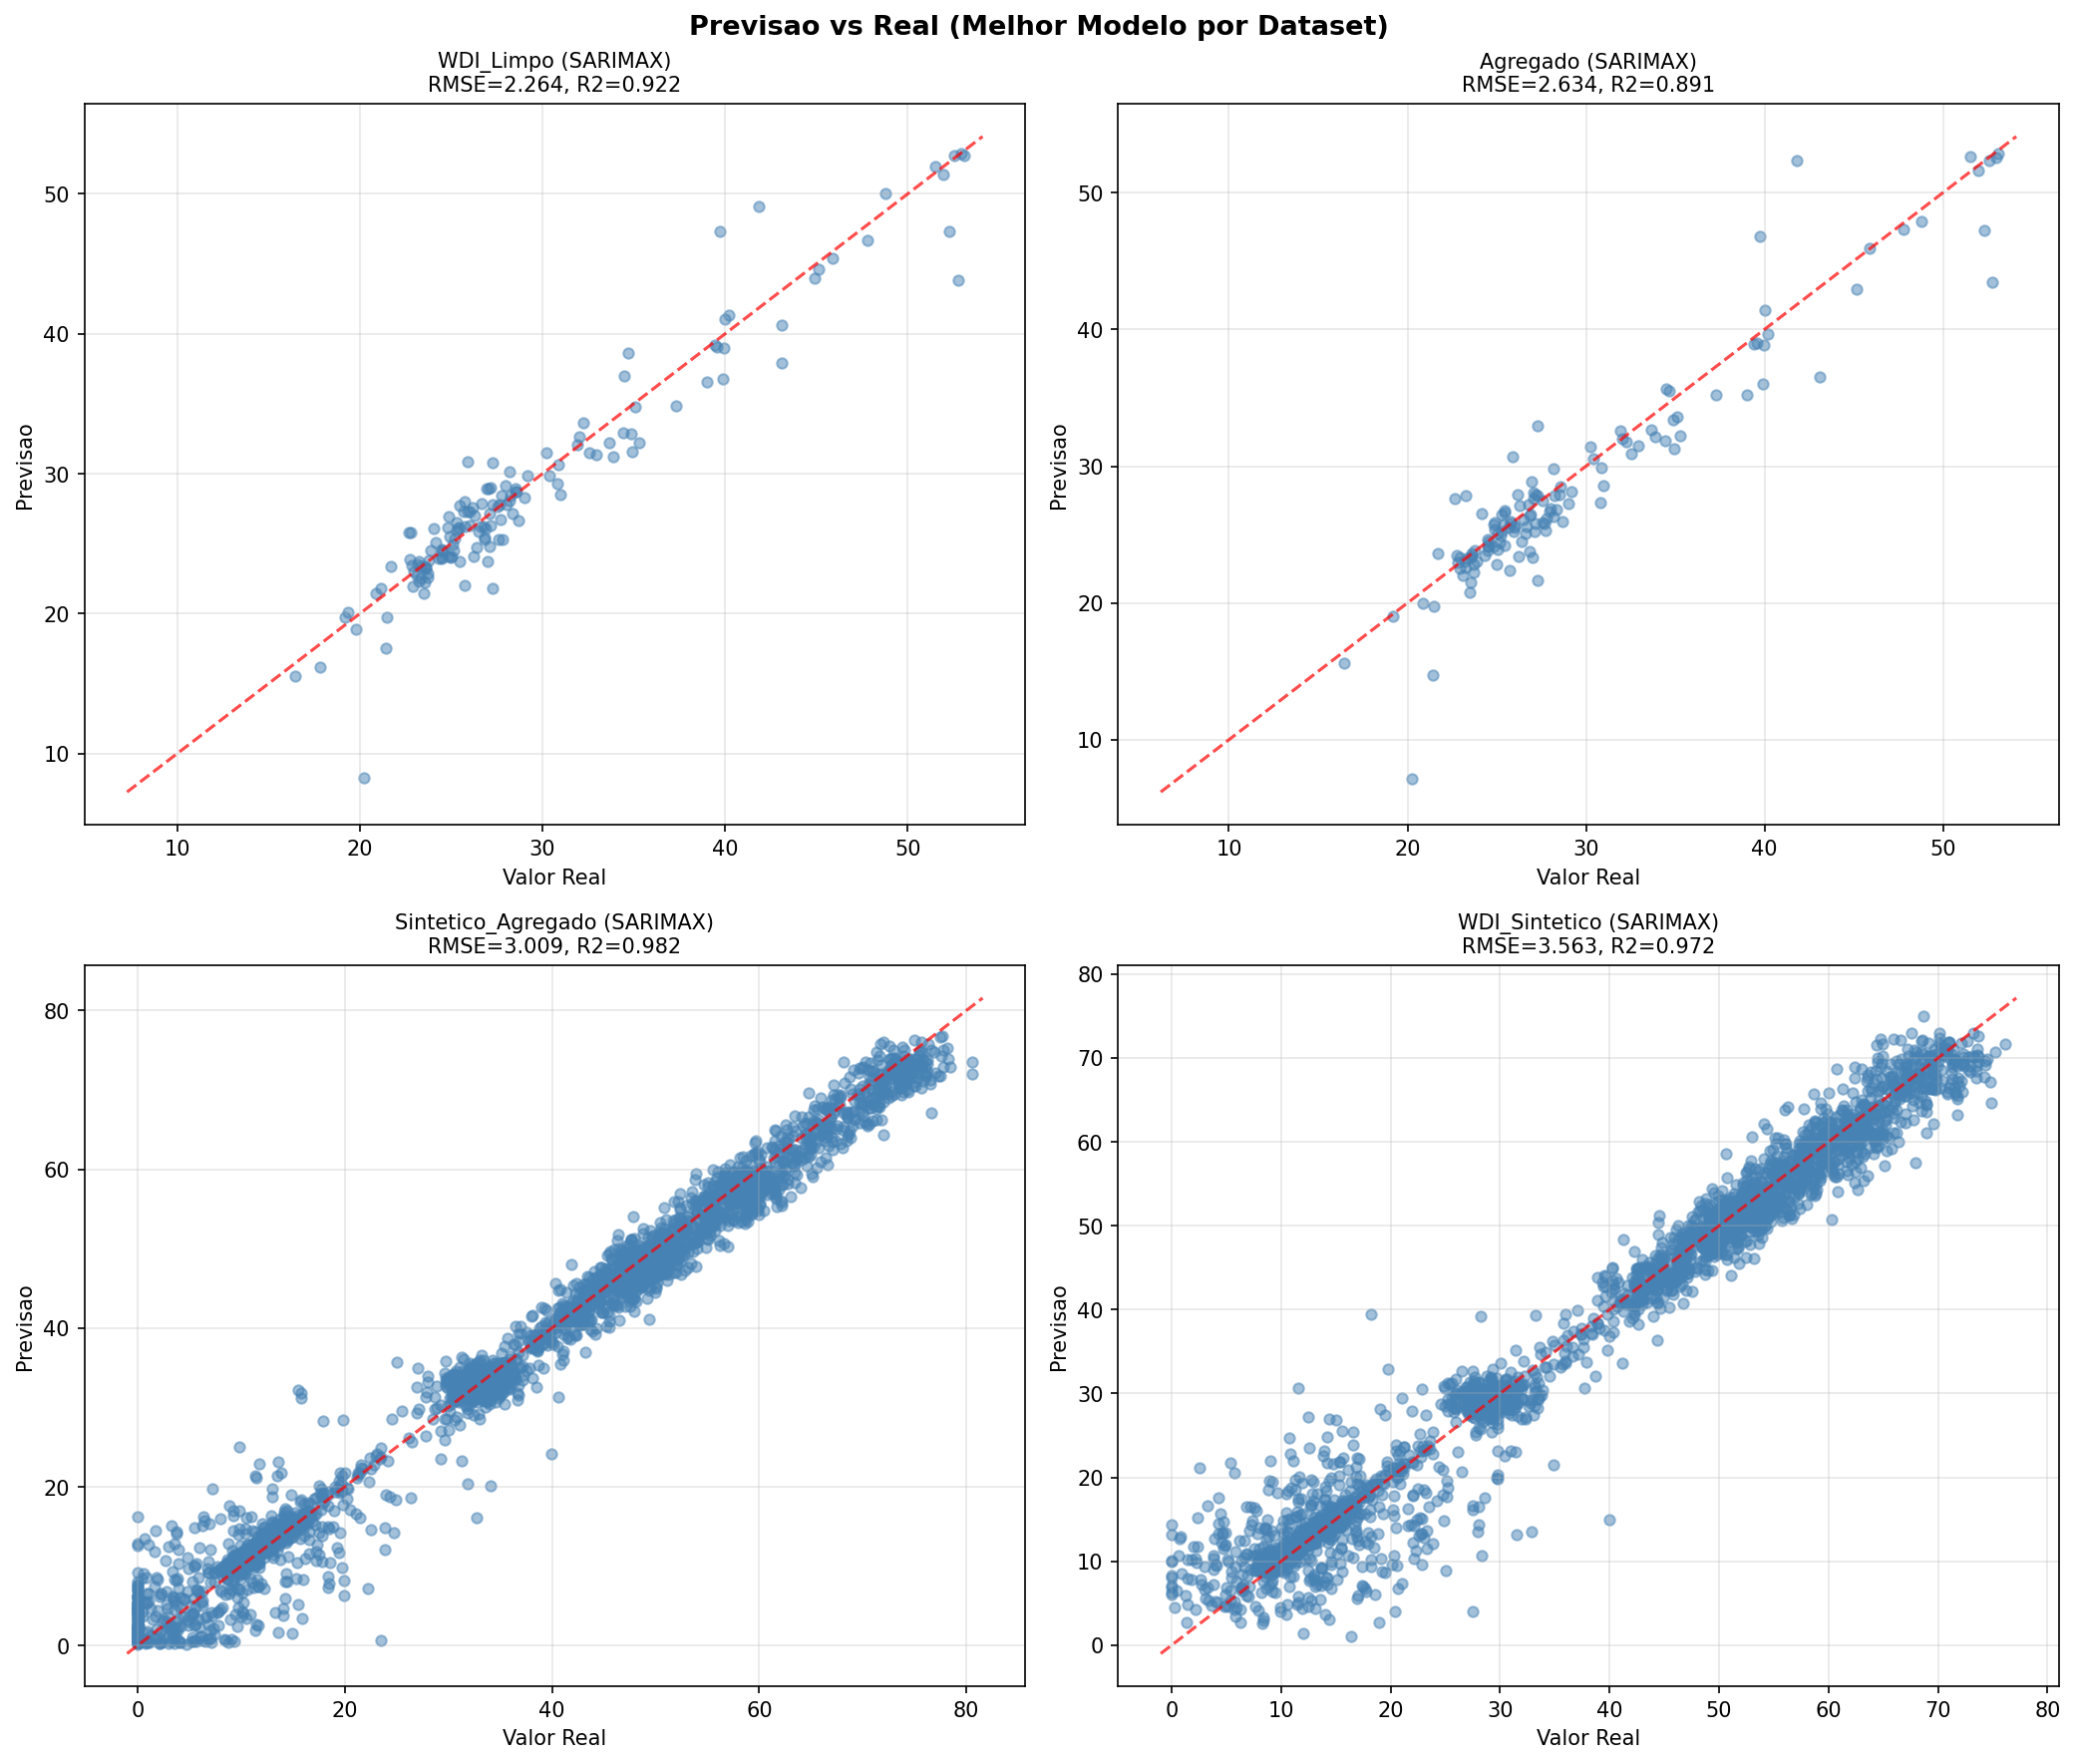


  ✓ 6 imagens visualizadas


In [14]:
# Visualizar imagens geradas no Passo 5
mostrar_imagens(['resultados_avaliacao'], titulo='Passo 5 - Avaliação de Performance')

### **SEGUNDA PARTE (OS FICHEIROS TEMPORÁRIOS PRECISAM SER RESTURADOS**

**Instalando dependência**

In [19]:
!pip install gdown -q


**FORÇAR NOVA CLONAGEM**

In [20]:
import os

# 1. Vai para um diretório seguro (o /content sempre existe)
os.chdir('/content')

# 2. Remove qualquer resquício antigo (ignora erros se não existir)
!rm -rf /content/repo

# 3. Clona novamente
!git clone https://github.com/ottrindade1963/analise-industrialXL.git /content/repo

# 4. Entra no diretório clonado
os.chdir('/content/repo')

# 5. Verifica o commit desejado (use o hash real, sem <>)
!git checkout 434a91d

print("✓ Repositório clonado e posicionado no commit 434a91d")

Cloning into '/content/repo'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 94 (delta 41), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 179.85 KiB | 3.33 MiB/s, done.
Resolving deltas: 100% (41/41), done.
Note: switching to '434a91d'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 434a91d Add files via upload
✓ Repositório clonado e posicionado no commit 434a91d


**RESTAURAR FICHEIROS DO DRIVE**

In [21]:
import os
import urllib.request

os.makedirs('/content/repo/pipeline_africa_mo/dados_engenharia', exist_ok=True)
os.makedirs('/content/repo/pipeline_africa_mo/modelos', exist_ok=True)

files_to_download = {
    '/content/repo/pipeline_africa_mo/dados_engenharia/agregado_features.csv': '1CaMqimq95jdytm6E2jQL9d-MxTIc9m0D',
    '/content/repo/pipeline_africa_mo/dados_engenharia/wdi_limpo_features.csv': '1u4F8Yie3dALIGtqpcV2eEX0bbuy5xdwy',
    '/content/repo/pipeline_africa_mo/dados_engenharia/wdi_sintetico_features.csv': '1nZmubk6frjFXHWt2YoDMH4Zb6lUvlVog',
    '/content/repo/pipeline_africa_mo/modelos/modelo_Agregado_RandomForest.pkl': '1-PMLqrCACC4rvquBXUc8Oa4f0JQ0kNXD',
    '/content/repo/pipeline_africa_mo/modelos/modelo_Agregado_XGBoost.pkl': '1HmA9j2vjOY5Ch7LMTcGeRjNEOBEwLijF',
    '/content/repo/pipeline_africa_mo/modelos/modelo_Agregado_GradientBoosting.pkl': '1o3falNn2CERgeriJmizdBoyMXeFJRJi2',
    '/content/repo/pipeline_africa_mo/modelos/modelo_Agregado_LSTM.pkl': '1WtjjrMCQXdqxANiuzm-d8uzAWZN4sFsQ',
    '/content/repo/pipeline_africa_mo/modelos/modelo_Agregado_SARIMAX.pkl': '1hg-rx5hjyMTtEIV2mOEq28AU4hWBvLeI',
    '/content/repo/pipeline_africa_mo/modelos/modelo_Agregado_Bayes_PartialPooling.pkl': '1m7_LPBZ-heYkI5qPs5BwFVgPMEsM57f7',
    '/content/repo/pipeline_africa_mo/modelos/modelo_Agregado_Bayes_CompletePooling.pkl': '1NGd4GGBQuUblkA44hy1UqFQJoJ9mGCXp',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Limpo_RandomForest.pkl': '1RiRLsFZ9Ng8pLQK6Itn9pi2xCU94StDe',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Limpo_XGBoost.pkl': '1JumCqePIh3I2ytKjblfE0oQ29UqoRr5y',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Limpo_GradientBoosting.pkl': '1G564nDLbxLU7Ze19fnDr2JsvDNM6NqHP',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Limpo_LSTM.pkl': '1fWS0hv3DVB_Qt20AXS_DPrb7C898WY4A',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Limpo_SARIMAX.pkl': '1DzsLJ_qHXzQvtQYNoE1a48gogdZKXlQT',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Limpo_Bayes_PartialPooling.pkl': '1j5j0SEXuw7MglAsrs7lW3M4qOmKr_Xcx',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Limpo_Bayes_CompletePooling.pkl': '1OhPSvEmg1RzZyMIfumIlsdayQ8wvPSAq',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Sintetico_RandomForest.pkl': '1PWkNzNLTmFFinoGMurbTg82t0ApIcxqY',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Sintetico_XGBoost.pkl': '15lX3PwHMSFT5X5oLOG5KpHzuMi4tx1Ee',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Sintetico_GradientBoosting.pkl': '1w70rZvXjmdqVjd44TDsnEkQszYMUIHgM',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Sintetico_LSTM.pkl': '1CWvjC4uNqvAEsX6udWmoED_UlJM0qdIJ',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Sintetico_SARIMAX.pkl': '1Ran84IJ_vpDKoAexneNATLEaFcrUbgVn',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Sintetico_Bayes_PartialPooling.pkl': '1wtd28C2ti-tr9rn_Wzfq4hbiXyP6GQ7l',
    '/content/repo/pipeline_africa_mo/modelos/modelo_WDI_Sintetico_Bayes_CompletePooling.pkl': '1li5I-Tcj8uZeBrt14rRBaoSsWz6REClE',
}

print("Baixando ficheiros...")
for destination, file_id in files_to_download.items():
    url = f"https://drive.google.com/uc?id={file_id}&export=download"
    try:
        urllib.request.urlretrieve(url, destination )
        print(f"✓ {os.path.basename(destination)}")
    except Exception as e:
        print(f"✗ {os.path.basename(destination)}: {e}")

print("\n✓ Concluído!")



Baixando ficheiros...
✓ agregado_features.csv
✓ wdi_limpo_features.csv
✓ wdi_sintetico_features.csv
✓ modelo_Agregado_RandomForest.pkl
✓ modelo_Agregado_XGBoost.pkl
✓ modelo_Agregado_GradientBoosting.pkl
✓ modelo_Agregado_LSTM.pkl
✓ modelo_Agregado_SARIMAX.pkl
✓ modelo_Agregado_Bayes_PartialPooling.pkl
✓ modelo_Agregado_Bayes_CompletePooling.pkl
✓ modelo_WDI_Limpo_RandomForest.pkl
✓ modelo_WDI_Limpo_XGBoost.pkl
✓ modelo_WDI_Limpo_GradientBoosting.pkl
✓ modelo_WDI_Limpo_LSTM.pkl
✓ modelo_WDI_Limpo_SARIMAX.pkl
✓ modelo_WDI_Limpo_Bayes_PartialPooling.pkl
✓ modelo_WDI_Limpo_Bayes_CompletePooling.pkl
✓ modelo_WDI_Sintetico_RandomForest.pkl
✓ modelo_WDI_Sintetico_XGBoost.pkl
✓ modelo_WDI_Sintetico_GradientBoosting.pkl
✓ modelo_WDI_Sintetico_LSTM.pkl
✓ modelo_WDI_Sintetico_SARIMAX.pkl
✓ modelo_WDI_Sintetico_Bayes_PartialPooling.pkl
✓ modelo_WDI_Sintetico_Bayes_CompletePooling.pkl

✓ Concluído!


**VERIFICAÇÃO E ORDENAÇÃO DOS CAMINHO PARA O PASSO6**

In [27]:
import os
import sys

# Corrigir caminhos para o Colab
sys.path.insert(0, '/content/repo/pipeline_africa_mo')
import config_global as config

# Sobrescrever caminhos
config.DADOS_ENGENHARIA_DIR = '/content/repo/pipeline_africa_mo/dados_engenharia'
config.MODELOS_DIR = '/content/repo/pipeline_africa_mo/modelos'
config.ESTRATEGIAS_DIR = '/content/repo/pipeline_africa_mo/analise_estrategias'

# Verificar
print("Caminhos corrigidos:")
print(f"  Dados: {config.DADOS_ENGENHARIA_DIR}")
print(f"  Modelos: {config.MODELOS_DIR}")

# Agora execute o passo 6
from passo6_estrategias import executar_passo6
executar_passo6()


Caminhos corrigidos:
  Dados: /content/repo/pipeline_africa_mo/dados_engenharia
  Modelos: /content/repo/pipeline_africa_mo/modelos

  PASSO 6: ANALISE DE ESTRATEGIAS E MODERACAO

  [1/7] Carregando dados...
    Dataset: (888, 53)
    WGI: 1 variaveis
    WDI: 12 variaveis

  [2/7] Correlacoes WGI x Target...
    Correlacoes significativas: 0/1

  [3/7] Efeitos de moderacao (interacoes WGI x WDI com OLS)...
    Interacoes testadas: 4
    Significativas (p<0.05): 2
    Melhor: wgi_pca1 x pib_per_capita_ppc (beta=-6.833, p=0.0000)

  [4/7] Clusters de governanca (K-Means)...
    Clusters: {'Governanca_Media': 16, 'Governanca_Baixa': 11, 'Governanca_Alta': 10}

  [5/7] Performance dos modelos por cluster...

  [6/7] Impacto WGI por pais...

  [7/7] Gerando 6 visualizacoes...
[METADADOS] passo6_estrategias → /content/repo/metadados/passo6_estrategias_metadata.json
[AUTO-SAVE] 4 ficheiros copiados para Google Drive

  RESUMO PASSO 6:
  Correlacoes WGI significativas: 0/1
  Interacoes signif

---
## 6. Análise de Estratégias

In [30]:
import time
import os
import sys

print("\n" + "="*70)
print("  PASSO 6: ANÁLISE DE ESTRATÉGIAS")
print("="*70)

t0 = time.time()
from passo6_estrategias import executar_passo6
executar_passo6()

tempo_p6 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p6:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
#n_sync = sincronizar_todos_drive()
#print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 6: ANÁLISE DE ESTRATÉGIAS

  PASSO 6: ANALISE DE ESTRATEGIAS E MODERACAO

  [1/7] Carregando dados...
    Dataset: (888, 53)
    WGI: 1 variaveis
    WDI: 12 variaveis

  [2/7] Correlacoes WGI x Target...
    Correlacoes significativas: 0/1

  [3/7] Efeitos de moderacao (interacoes WGI x WDI com OLS)...
    Interacoes testadas: 4
    Significativas (p<0.05): 2
    Melhor: wgi_pca1 x pib_per_capita_ppc (beta=-6.833, p=0.0000)

  [4/7] Clusters de governanca (K-Means)...
    Clusters: {'Governanca_Media': 16, 'Governanca_Baixa': 11, 'Governanca_Alta': 10}

  [5/7] Performance dos modelos por cluster...

  [6/7] Impacto WGI por pais...

  [7/7] Gerando 6 visualizacoes...
[METADADOS] passo6_estrategias → /content/repo/metadados/passo6_estrategias_metadata.json
[AUTO-SAVE] 4 ficheiros copiados para Google Drive

  RESUMO PASSO 6:
  Correlacoes WGI significativas: 0/1
  Interacoes significativas (p<0.05): 2/4
  Clusters de governanca: 3
  Ficheiros CSV: 4 | Graficos PNG: 6
  Tempo: 

CÓDIGO PARA FORÇAR A VISUALIZAÇÃO NESTA SESSÃO

In [44]:
import os
from IPython.display import display, Image, HTML

def mostrar_imagens(diretorios, titulo=None):
    """
    Mostra inline TODAS as imagens PNG encontradas nos directórios especificados.
    Compatível com Colab e sandbox.

    Args:
        diretorios: Lista de nomes de directórios (ex: ['analise_estrategias', 'shap_analysis'])
        titulo: Título opcional para a galeria
    """
    PIPELINE_DIR = '/content/repo/pipeline_africa_mo'  # Ajuste se necessário

    imagens = []

    for d in diretorios:
        # Resolver caminho absoluto
        if not os.path.isabs(d):
            d = os.path.join(PIPELINE_DIR, d)

        if not os.path.exists(d):
            print(f"  ⚠️ Directório não encontrado: {d}")
            continue

        # Buscar PNGs recursivamente
        for root, dirs, files in os.walk(d):
            for f in sorted(files):
                if f.lower().endswith('.png'):
                    imagens.append(os.path.join(root, f))

    if not imagens:
        print("  (Nenhuma imagem gerada neste passo)")
        return

    # Mostrar título
    if titulo:
        display(HTML(f'<h2>📊 {titulo}</h2>'))
        display(HTML(f'<p><b>Total: {len(imagens)} imagens</b></p>'))
    else:
        display(HTML(f'<h2>📊 Visualizações geradas ({len(imagens)} imagens)</h2>'))

    # Mostrar cada imagem
    for i, img_path in enumerate(imagens, 1):
        nome_ficheiro = os.path.basename(img_path)
        subdir = os.path.basename(os.path.dirname(img_path))

        display(HTML(f'<hr><p><b>[{i}/{len(imagens)}] {subdir}/{nome_ficheiro}</b></p>'))
        display(Image(filename=img_path, width=900))

    print(f"\n✓ {len(imagens)} imagens visualizadas com sucesso!")

print("✓ Função mostrar_imagens() definida com sucesso!")


✓ Função mostrar_imagens() definida com sucesso!



  VISUALIZANDO PASSO 6 - ANÁLISE DE ESTRATÉGIAS


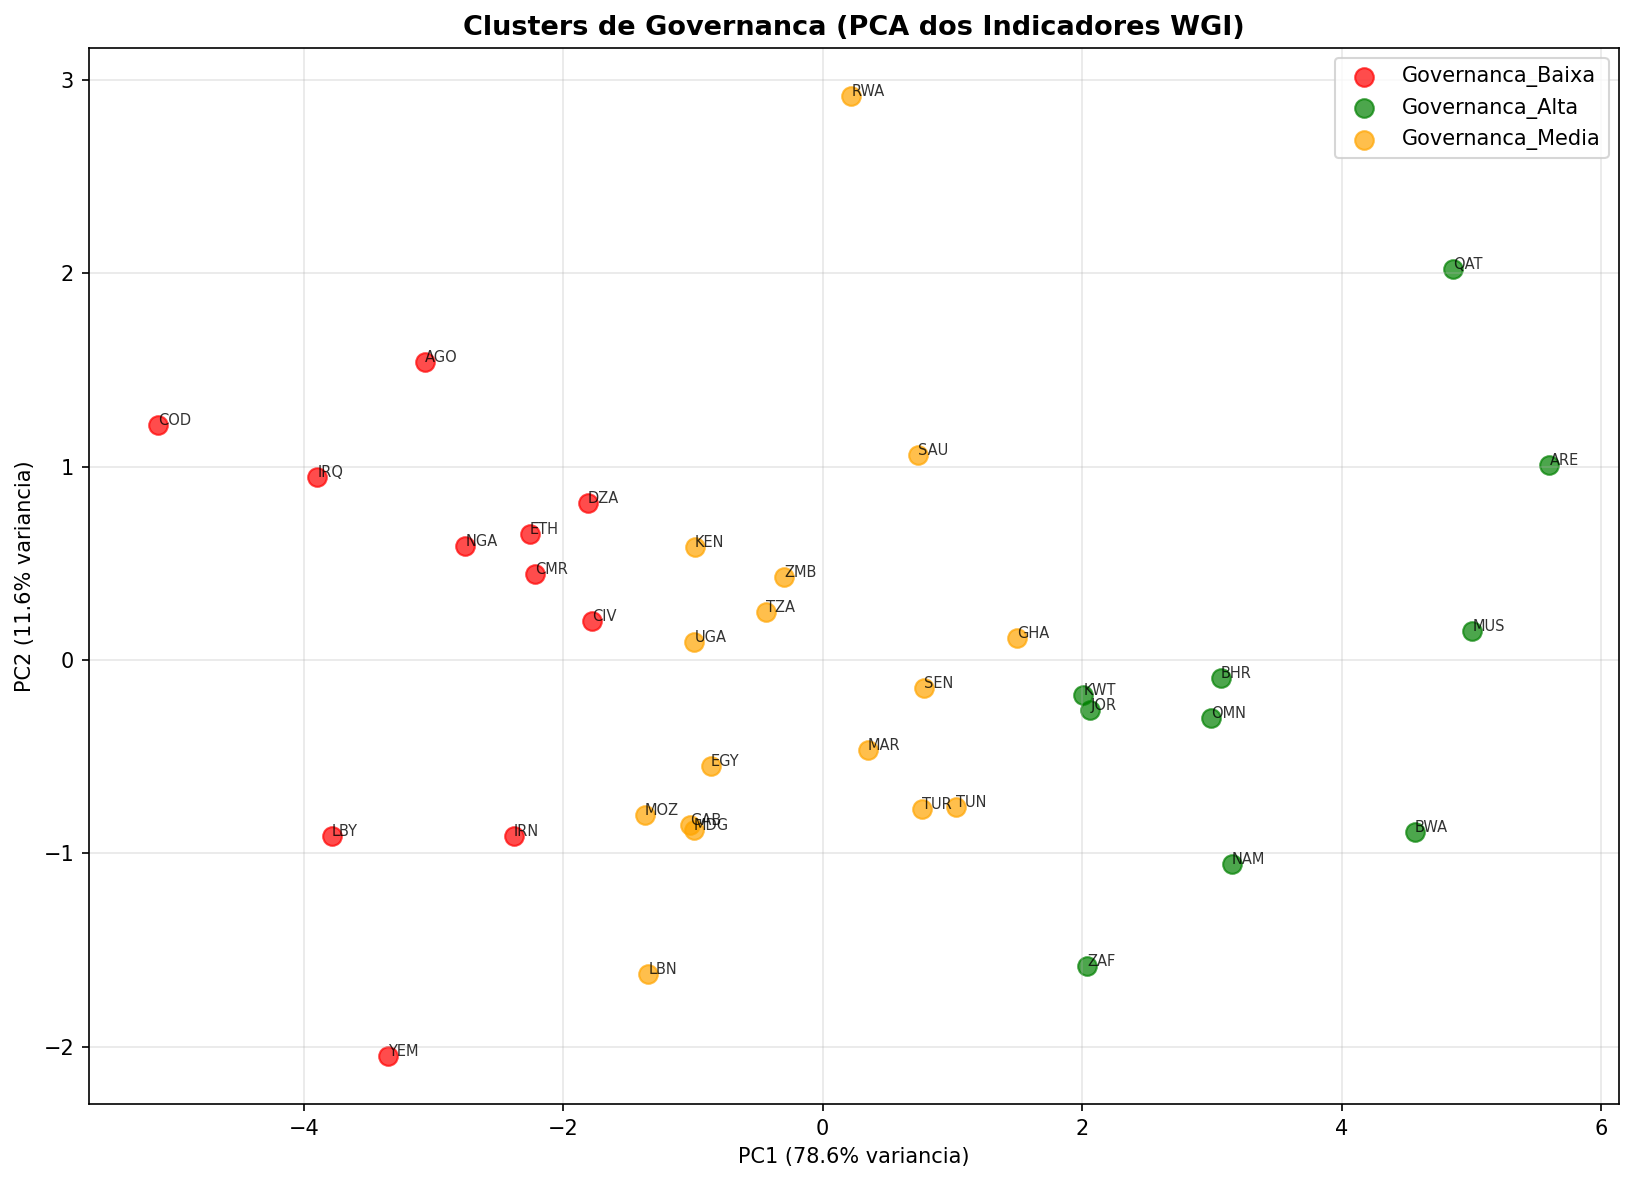

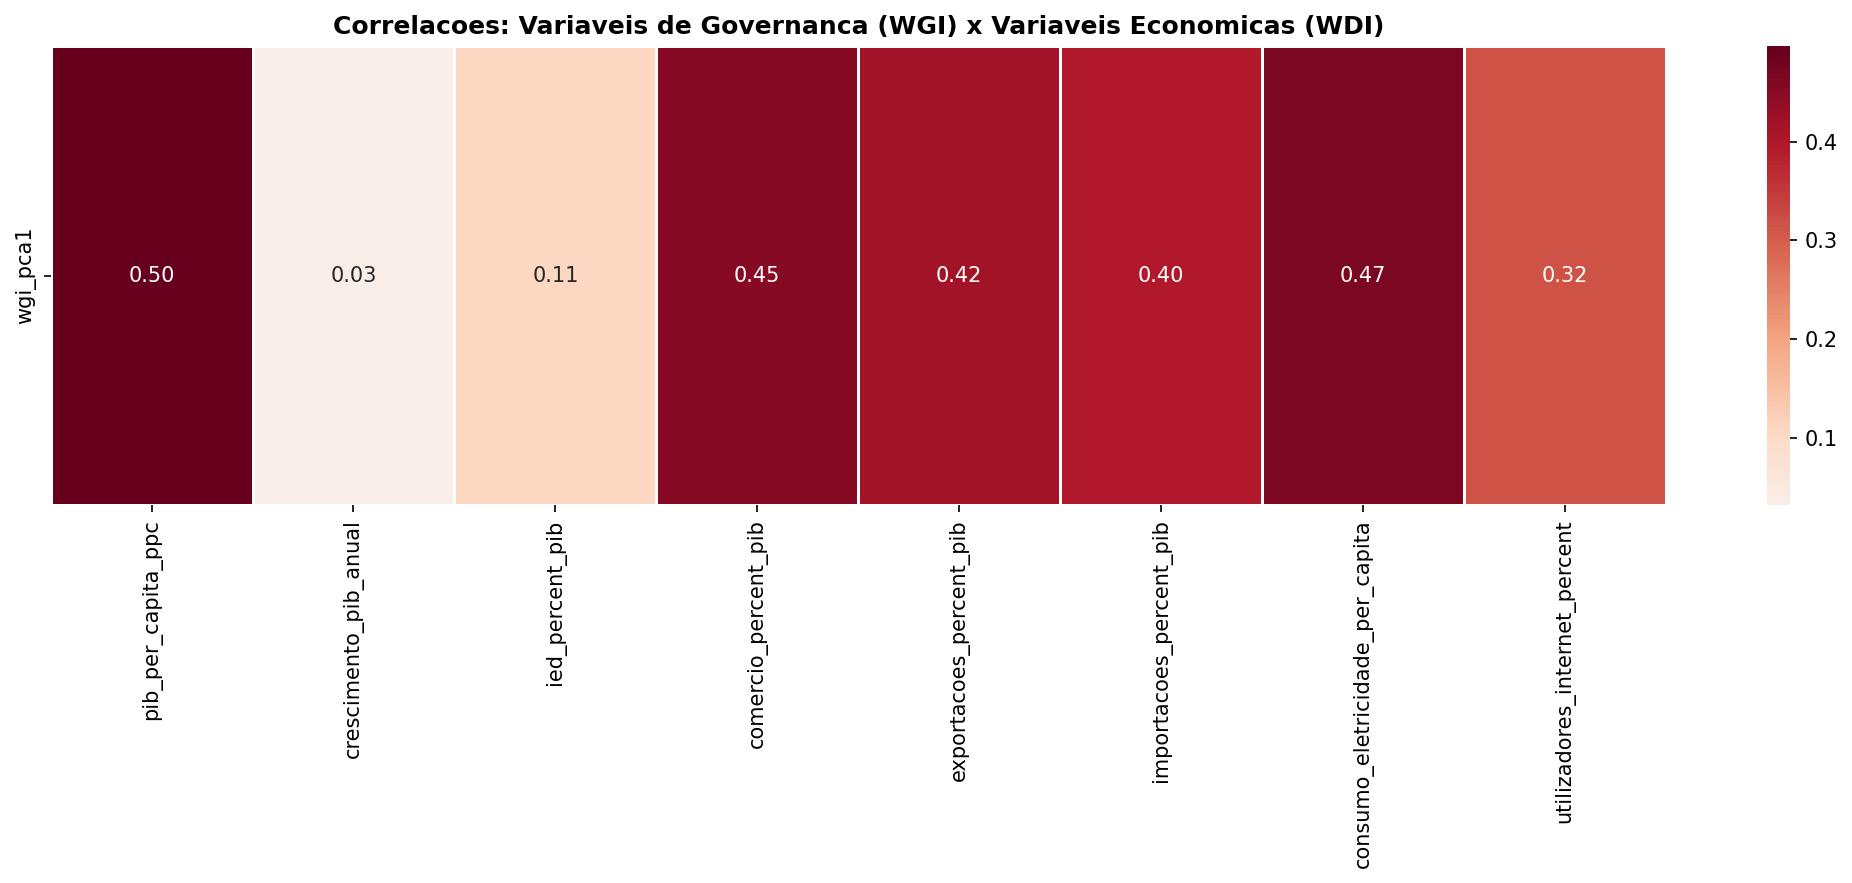

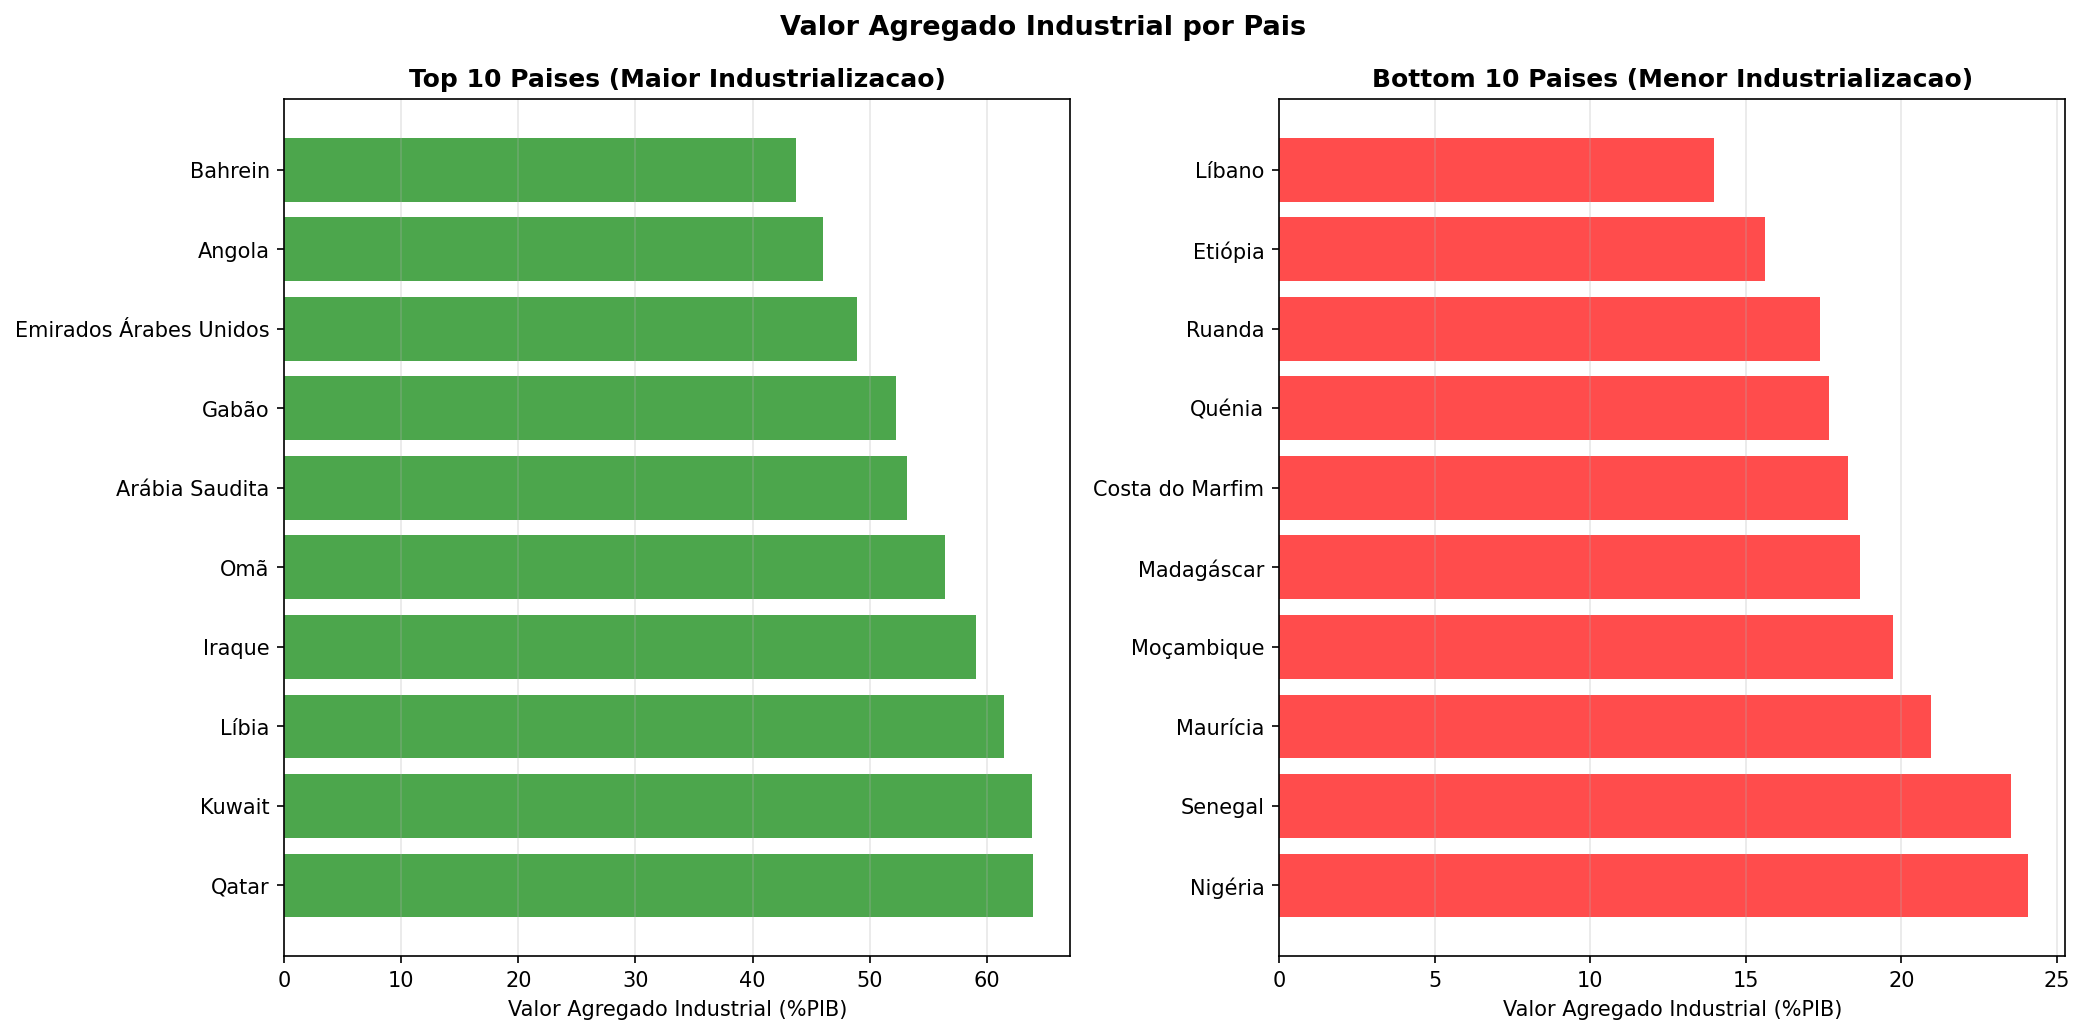

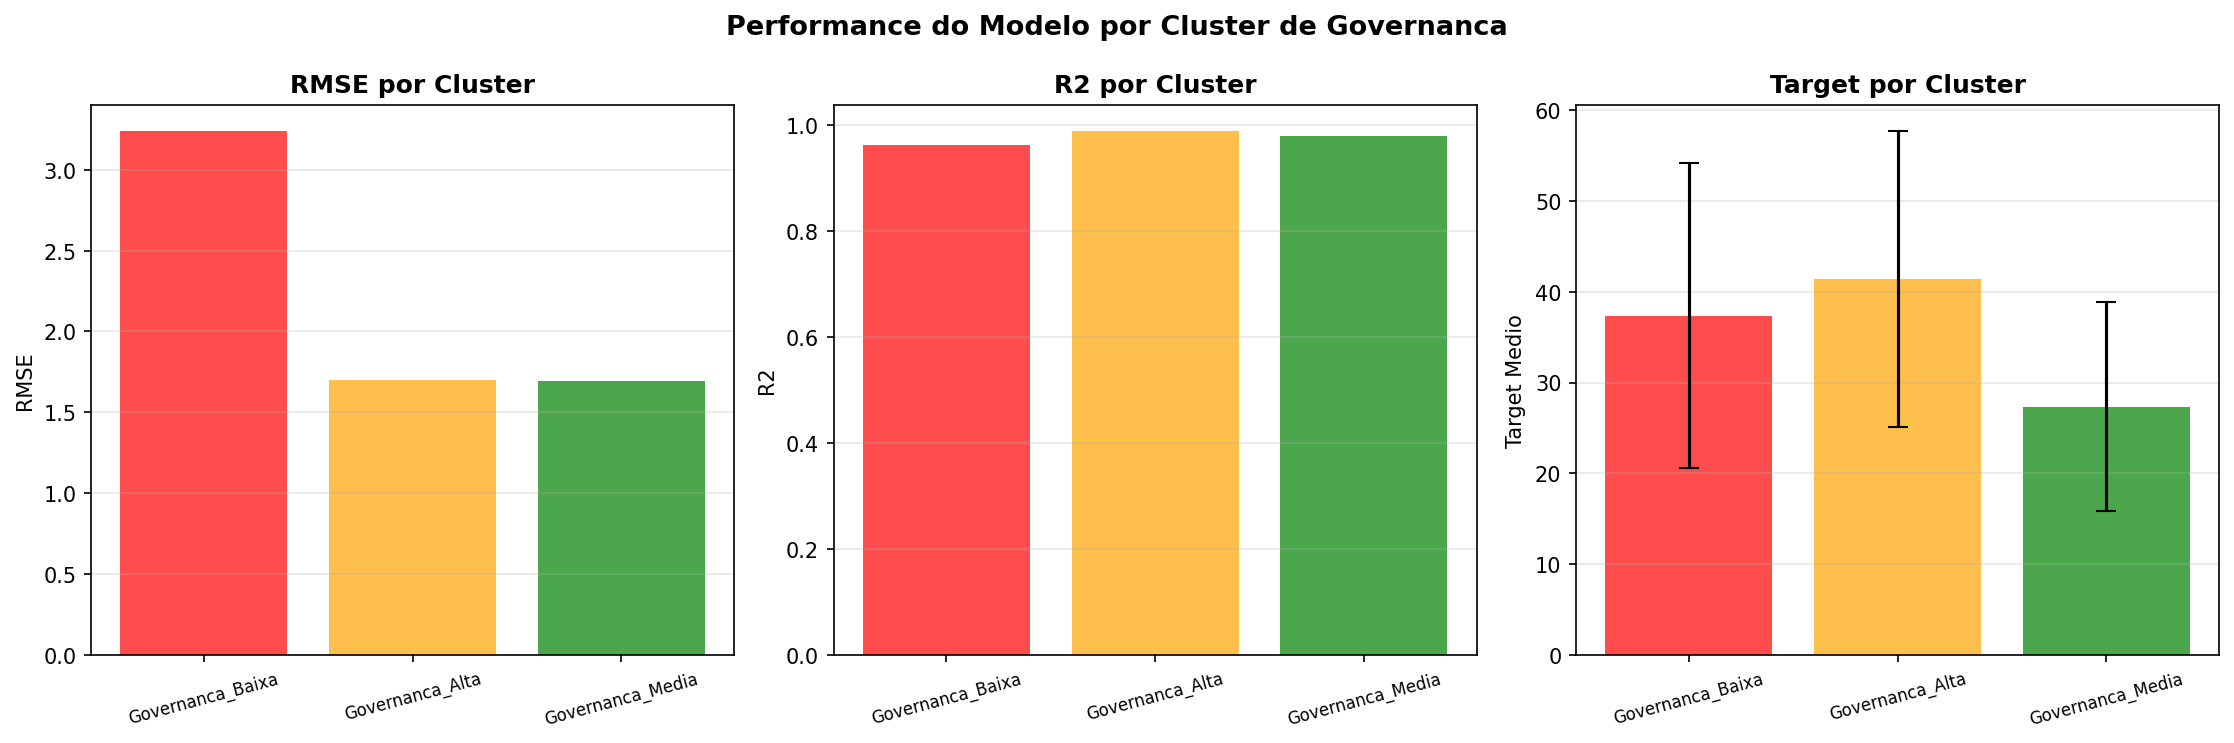

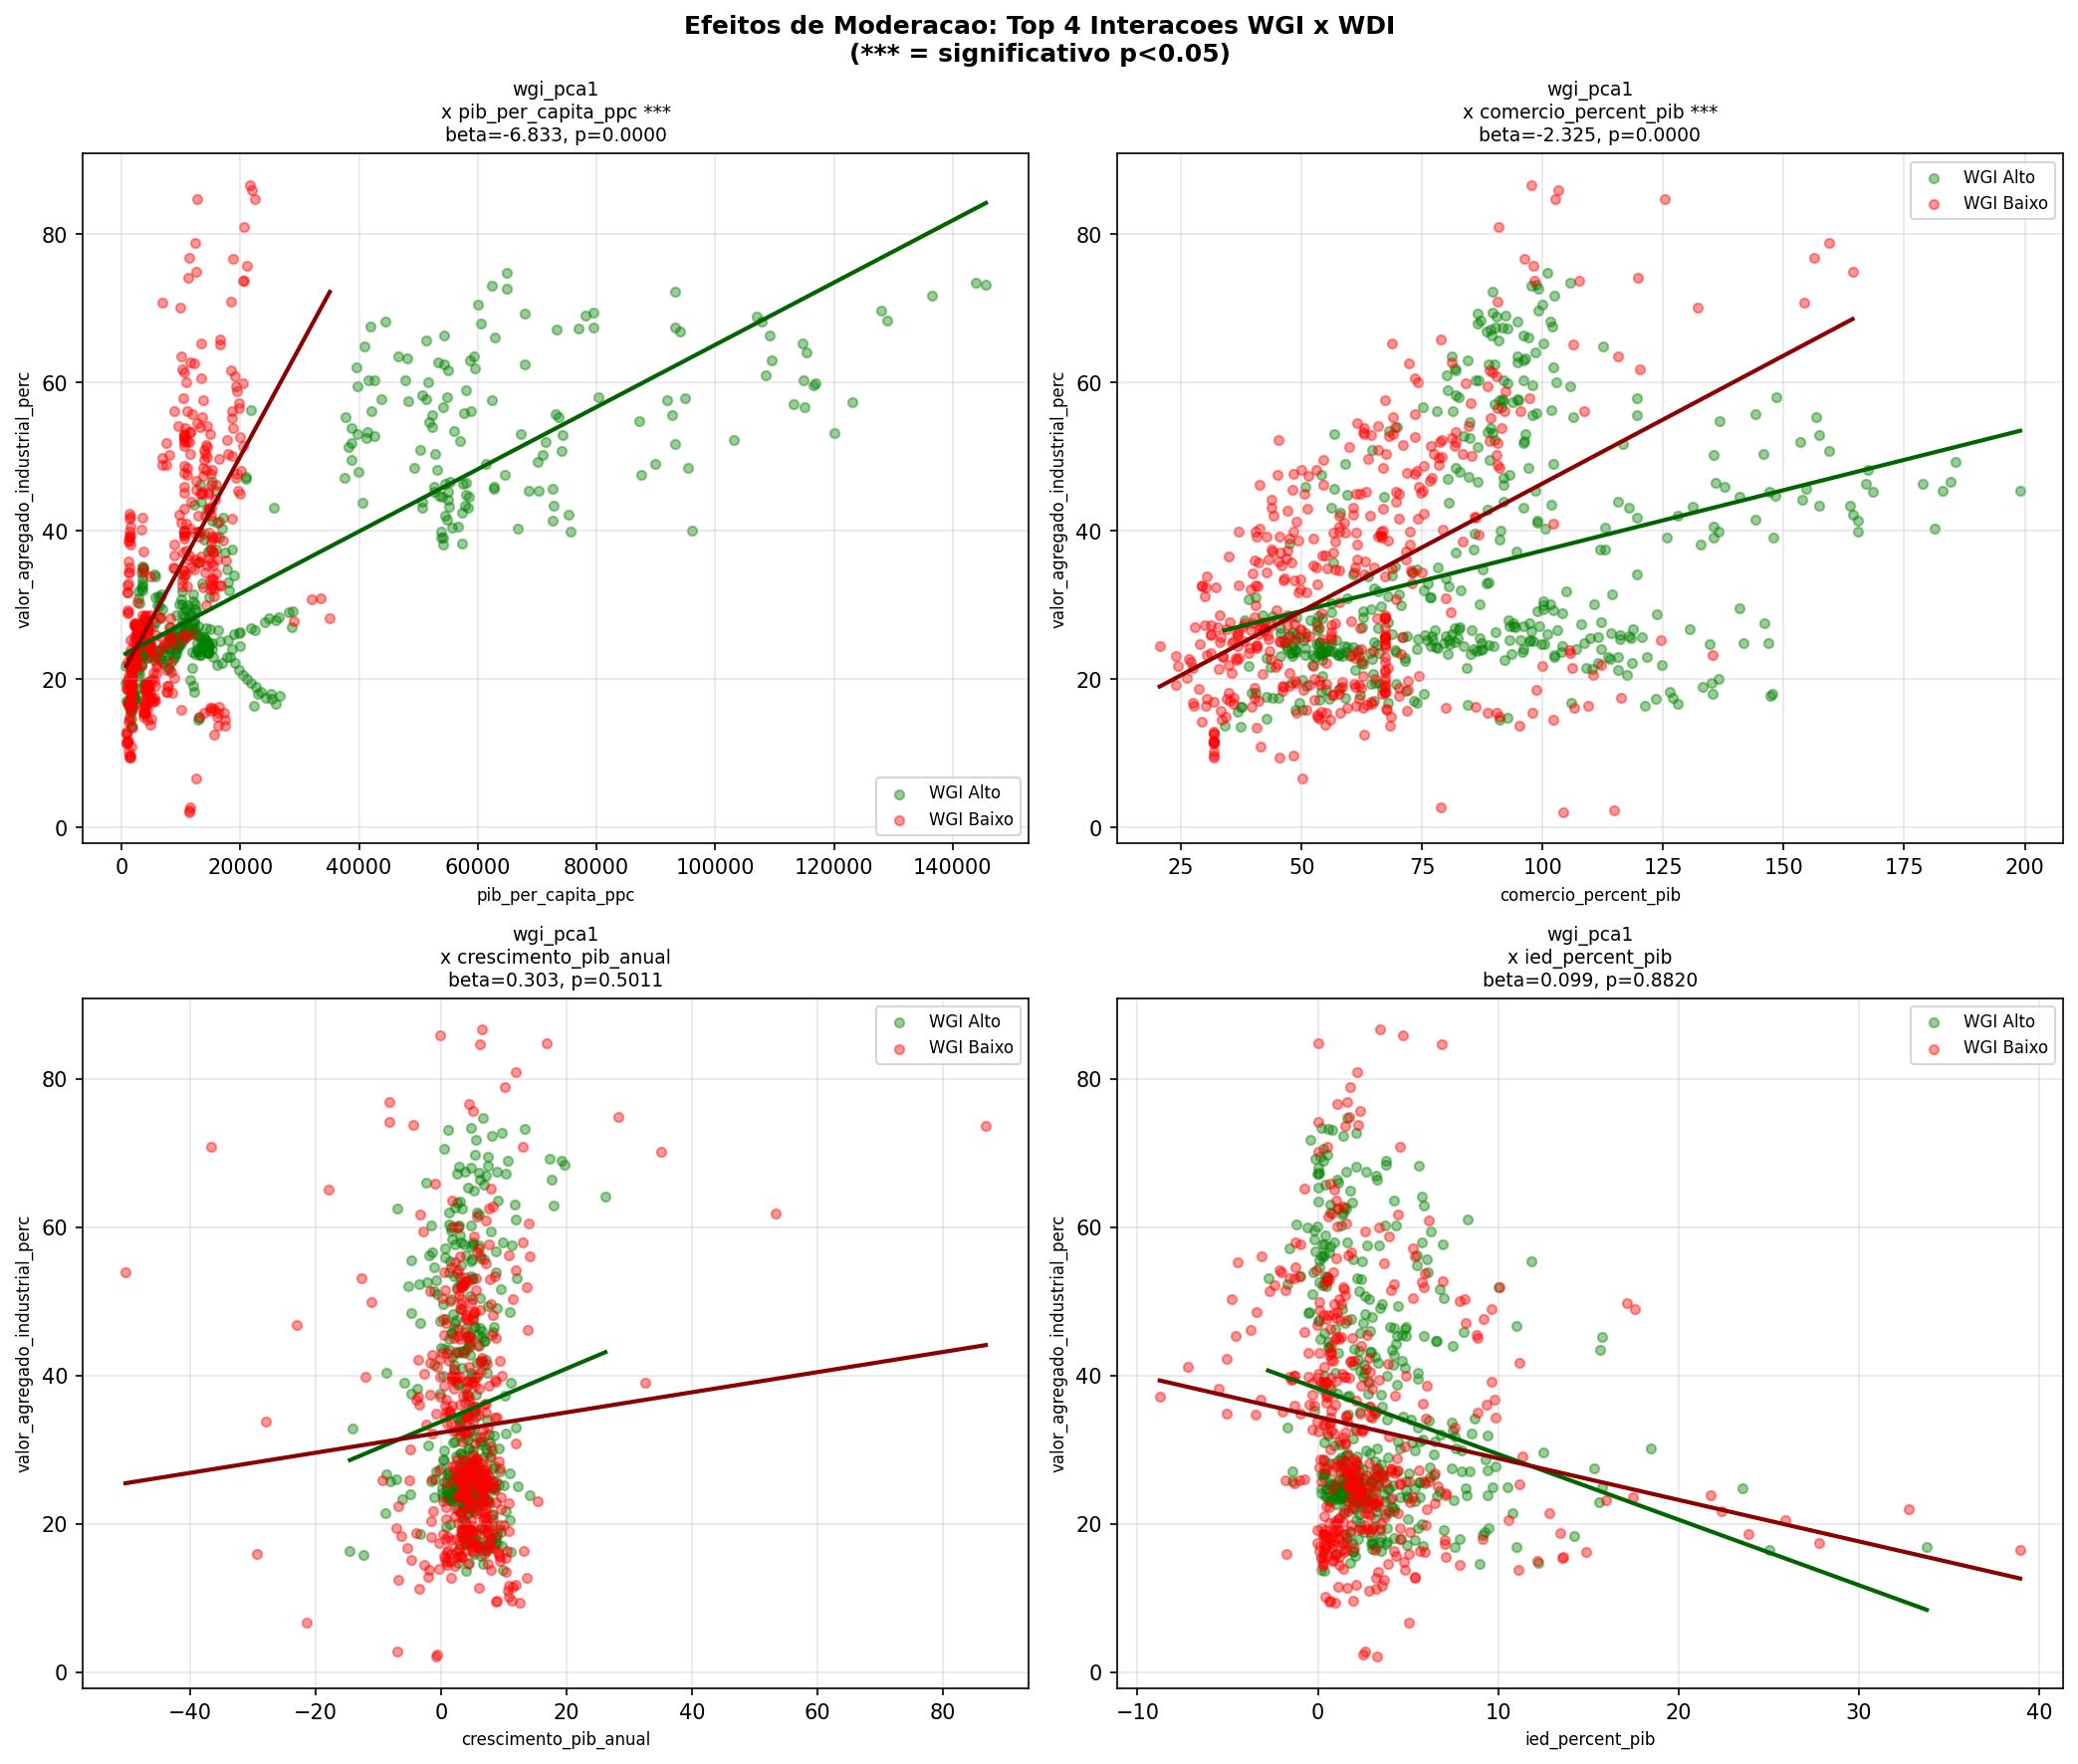

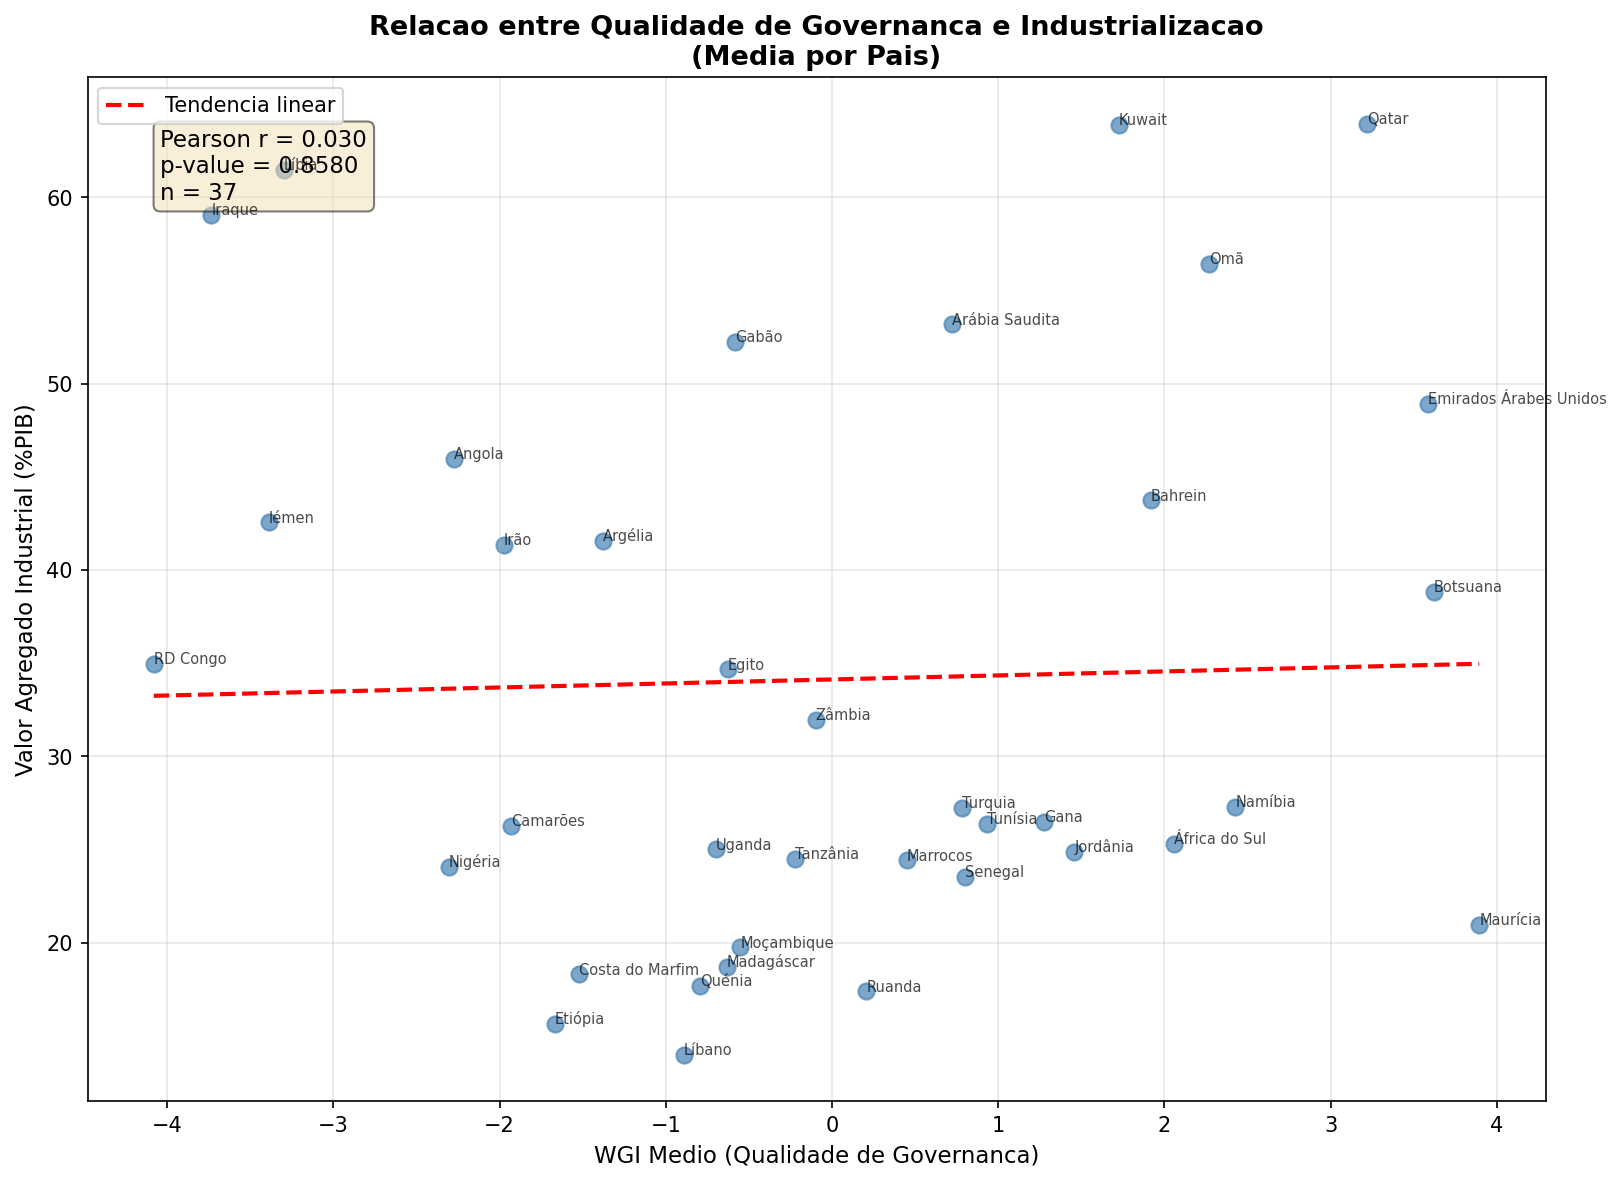


  ✓ 6 imagens visualizadas

✓ Visualização concluída!


In [31]:
# Visualizar Passo 6 com informações
print("\n" + "="*70)
print("  VISUALIZANDO PASSO 6 - ANÁLISE DE ESTRATÉGIAS")
print("="*70)

mostrar_imagens(['analise_estrategias'], titulo='Passo 6 - Análise de Estratégias')

print("\n✓ Visualização concluída!")


---
## 7. Interpretabilidade (SHAP)

In [33]:
import os
import shutil
from datetime import datetime

def sincronizar_todos_drive():
    """Sincroniza todos os ficheiros de resultados com Google Drive"""
    PIPELINE_DIR = '/content/repo/pipeline_africa_mo'
    DRIVE_DIR = '/content/drive/MyDrive/pipeline_africa_mo_resultados'

    os.makedirs(DRIVE_DIR, exist_ok=True)

    # Directórios a sincronizar
    diretorios = [
        'eda_brutos', 'eda_agregados', 'eda_engenharia',
        'resultados_avaliacao', 'analise_estrategias',
        'shap_analysis', 'analise_geografica', 'analise_avancada',
        'metadados'
    ]

    n_sync = 0
    for d in diretorios:
        src = os.path.join(PIPELINE_DIR, d)
        dst = os.path.join(DRIVE_DIR, d)

        if not os.path.exists(src):
            continue

        # Copiar directório
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)

        # Contar ficheiros
        for root, dirs, files in os.walk(dst):
            n_sync += len(files)

    return n_sync

print("✓ Função sincronizar_todos_drive() definida com sucesso!")


✓ Função sincronizar_todos_drive() definida com sucesso!


**CÓDIGO DE SINCRONIZAÇÃO**

In [45]:
# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  📁 11 ficheiros sincronizados com o Drive


In [35]:
print("\n" + "="*70)
print("  PASSO 7: INTERPRETABILIDADE (SHAP)")
print("="*70)

t0 = time.time()
from passo7_shap import executar_passo7
executar_passo7()

tempo_p7 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p7:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 7: INTERPRETABILIDADE (SHAP)

  PASSO 7: INTERPRETABILIDADE (SHAP + FEATURE IMPORTANCE)

  [1/8] Carregando modelos e dados...
    Datasets: 3 | Modelos: 9

  [2/8] Calculando SHAP values...
    SHAP: WDI_Limpo_RandomForest (500 obs)
    SHAP: WDI_Limpo_XGBoost (500 obs)
    SHAP: WDI_Limpo_GradientBoosting (500 obs)
    SHAP: Agregado_RandomForest (500 obs)
    SHAP: Agregado_XGBoost (500 obs)
    SHAP: Agregado_GradientBoosting (500 obs)
    SHAP: WDI_Sintetico_RandomForest (500 obs)
    SHAP: WDI_Sintetico_XGBoost (500 obs)
    SHAP: WDI_Sintetico_GradientBoosting (500 obs)

  [3/8] Permutation Importance completa...

  [4/8] Contribuicao relativa WGI vs WDI...
    WGI media: 0.3% | WDI media: 99.7%

  [5/8] Tabela top 20 features...

  [6/8] Gerando visualizacoes...
[METADADOS] passo7_shap → /content/repo/metadados/passo7_shap_metadata.json
[AUTO-SAVE] 2 ficheiros copiados para Google Drive

  RESUMO PASSO 7: 9 modelos | 8 graficos | 256.4s
  OK PASSO 7 CONCLUIDO

  ⏱ Temp

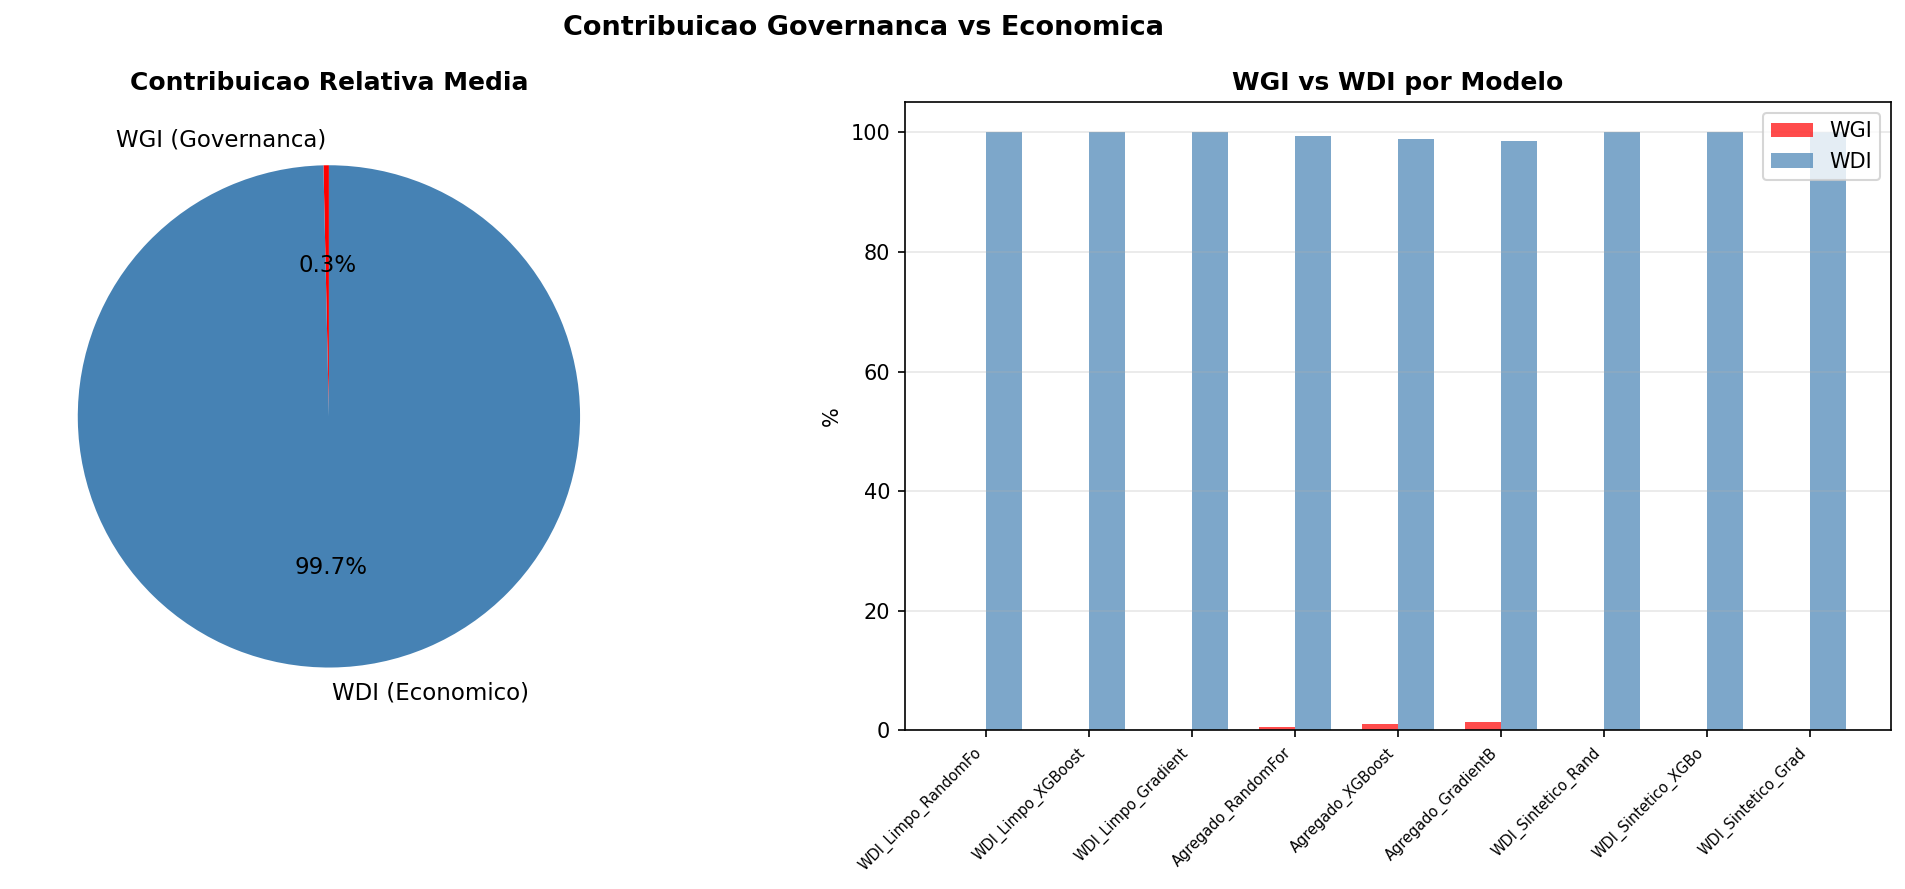

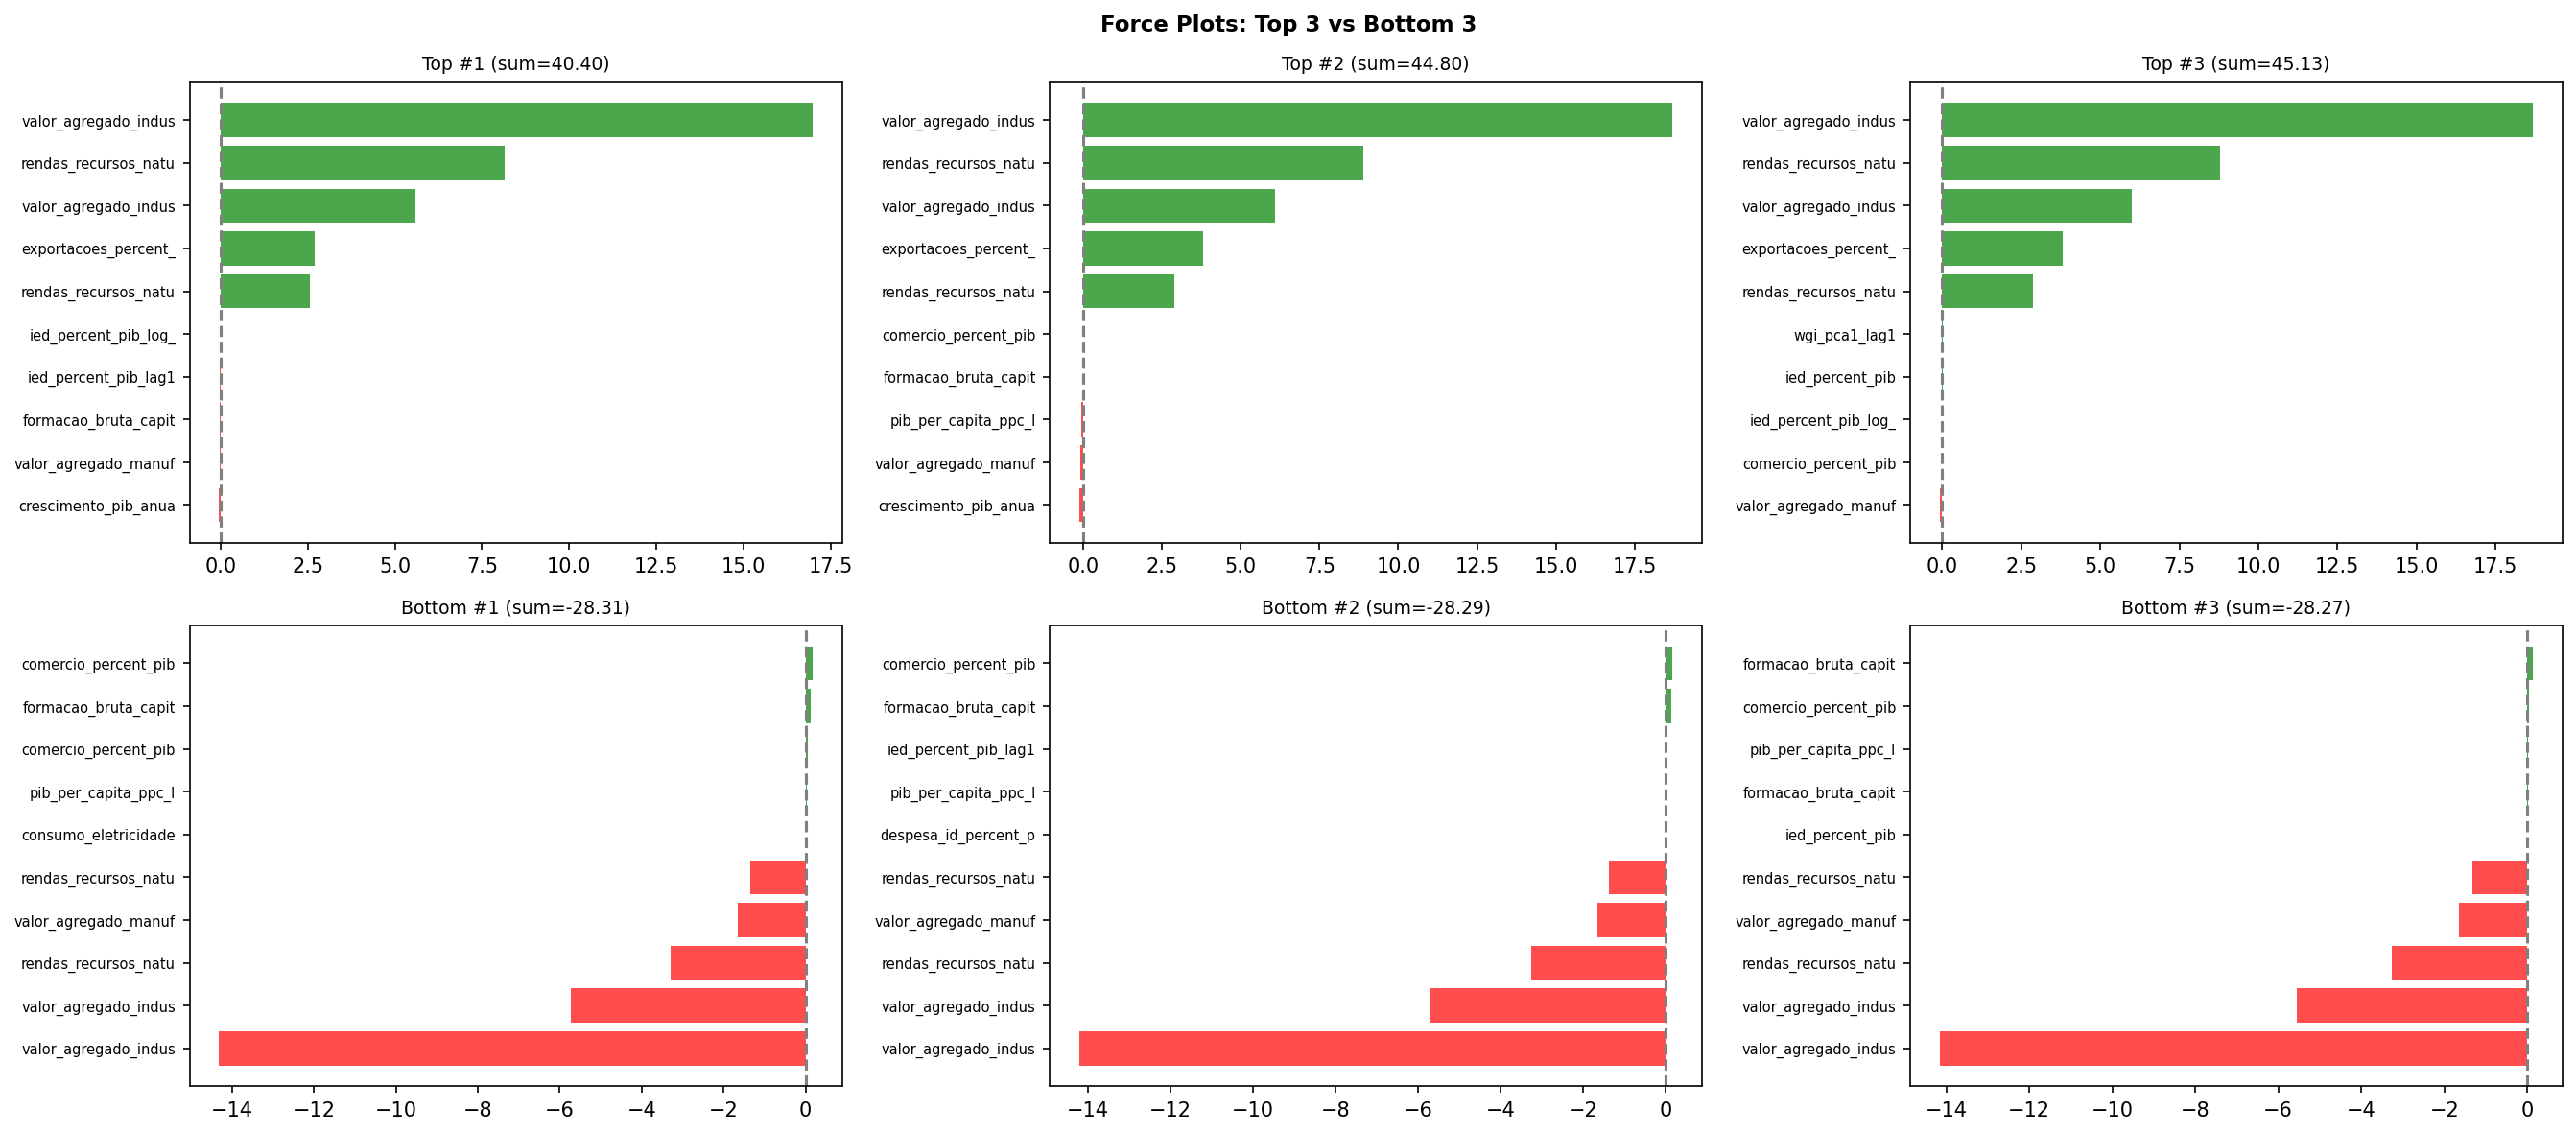

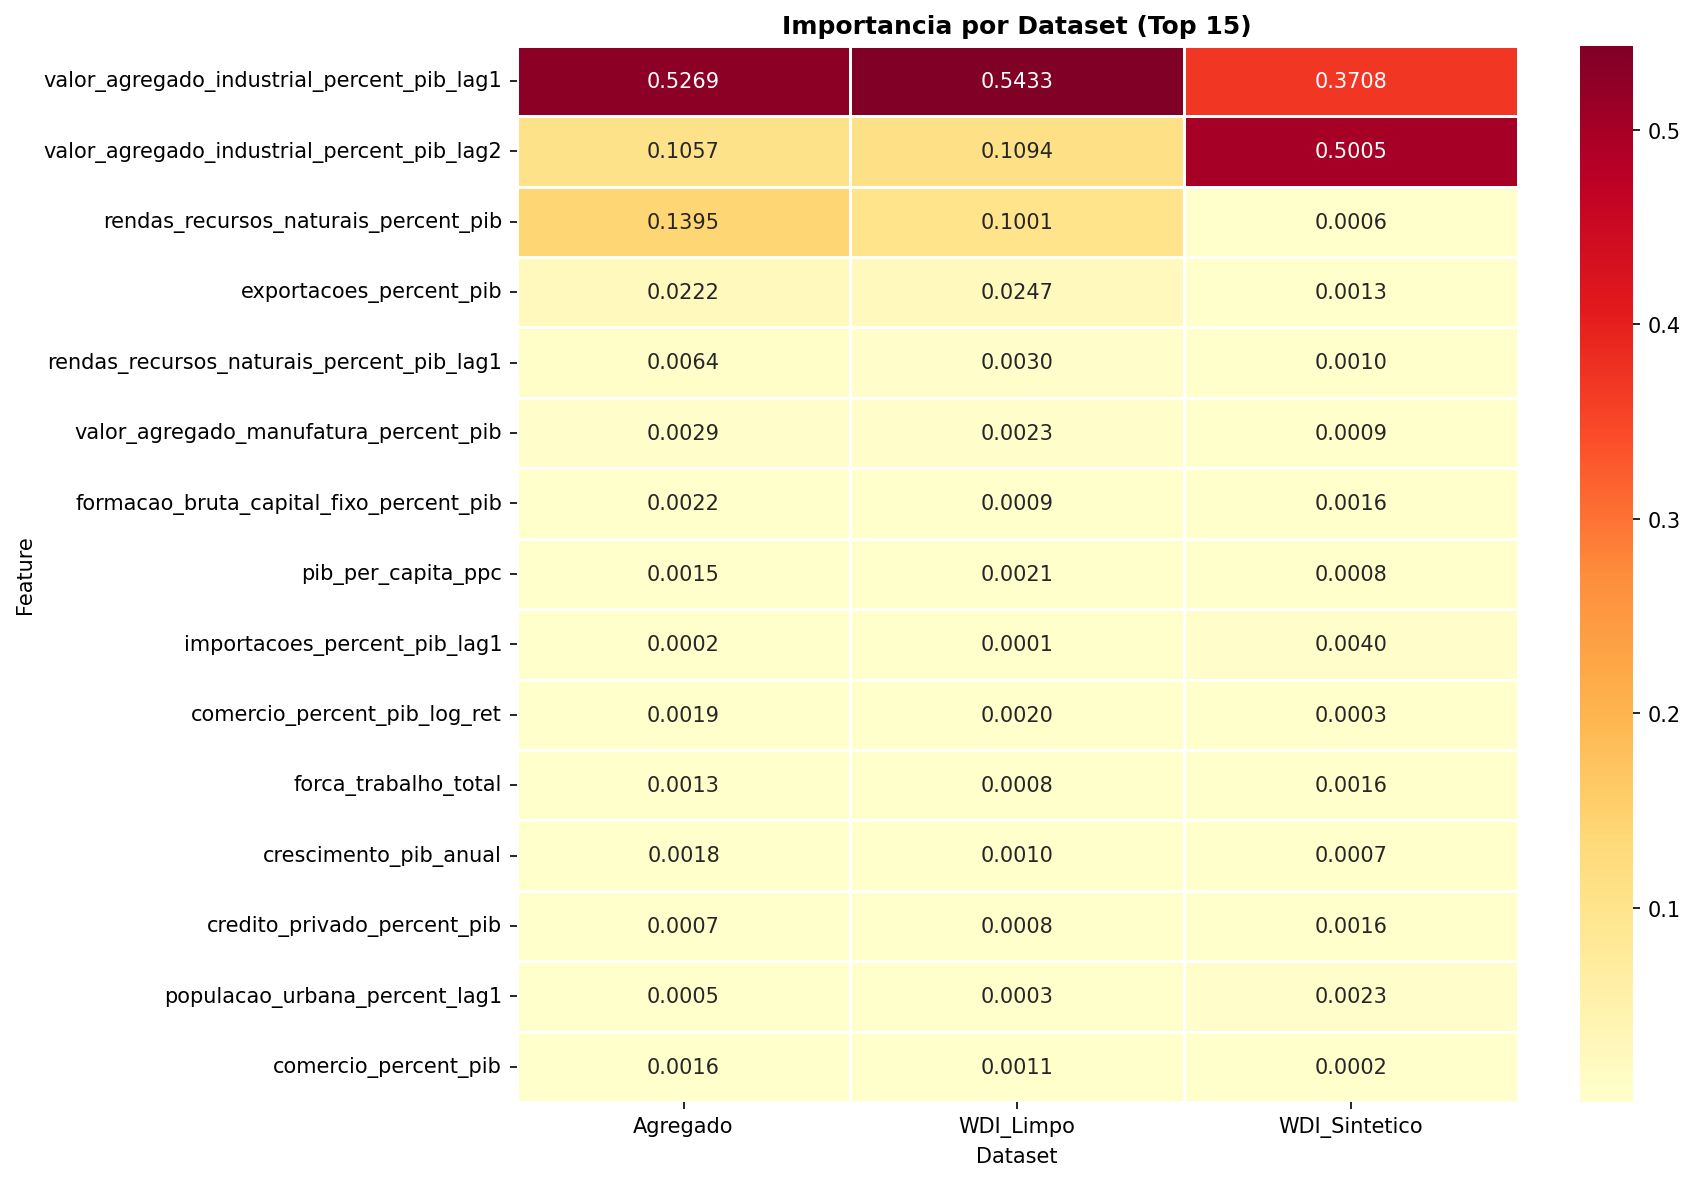

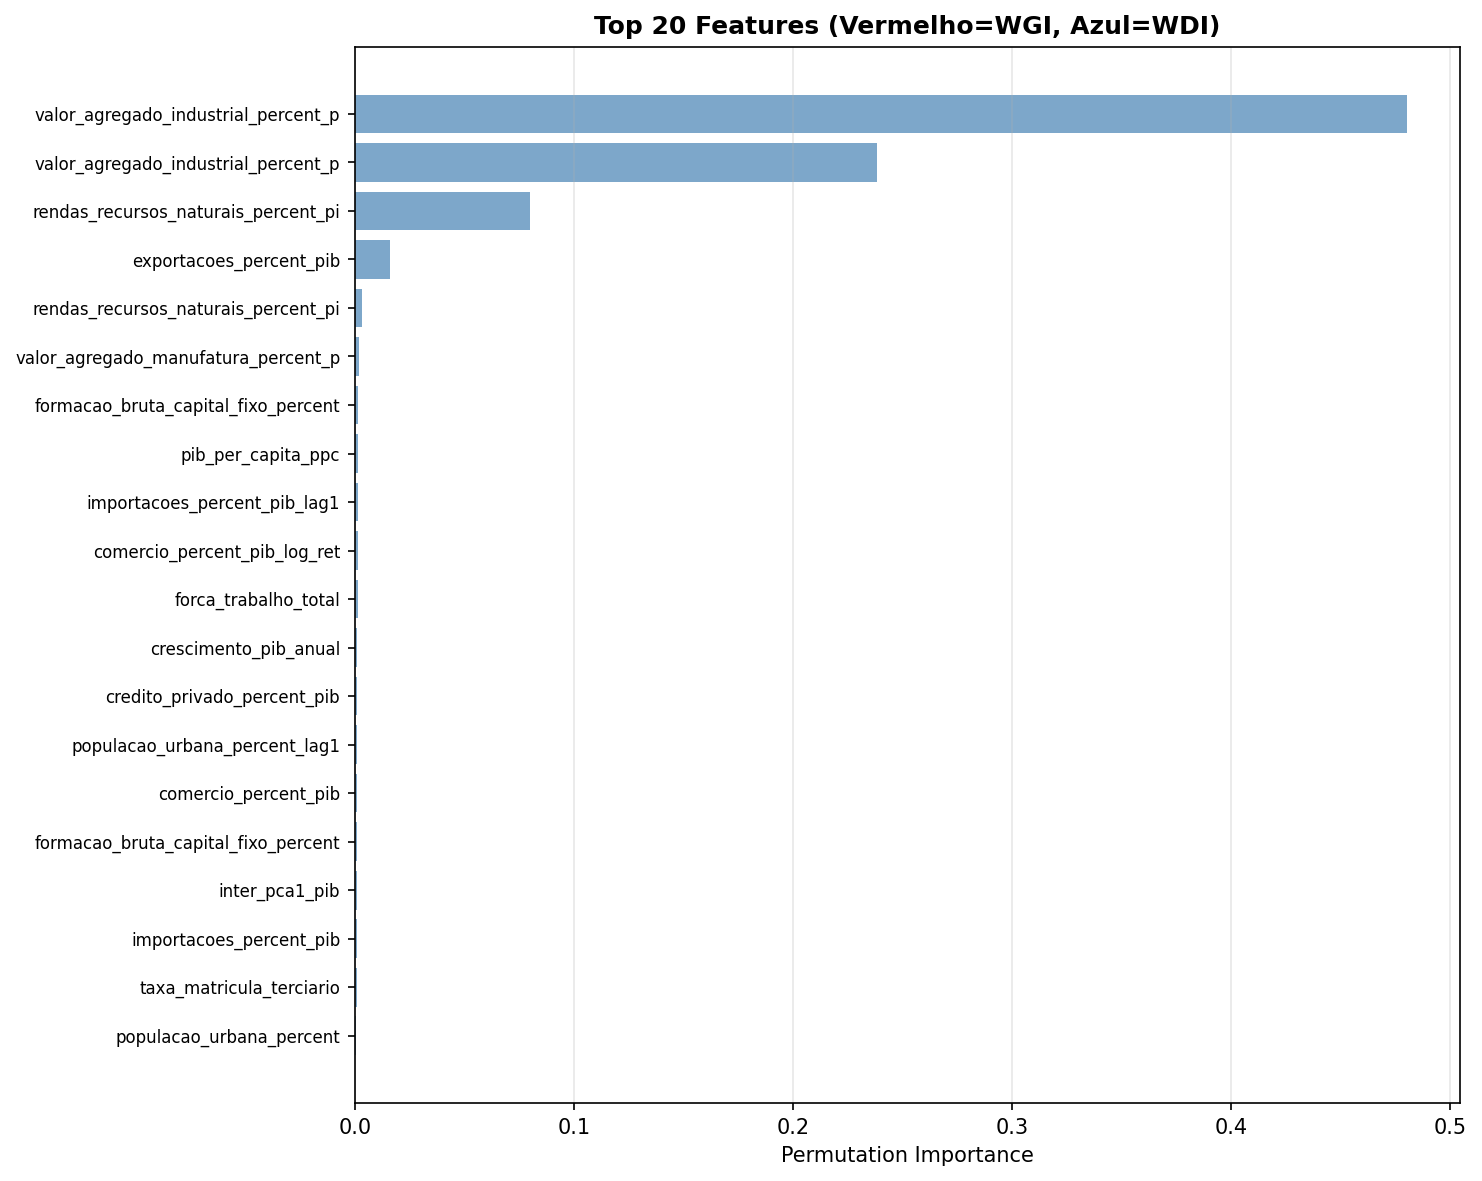

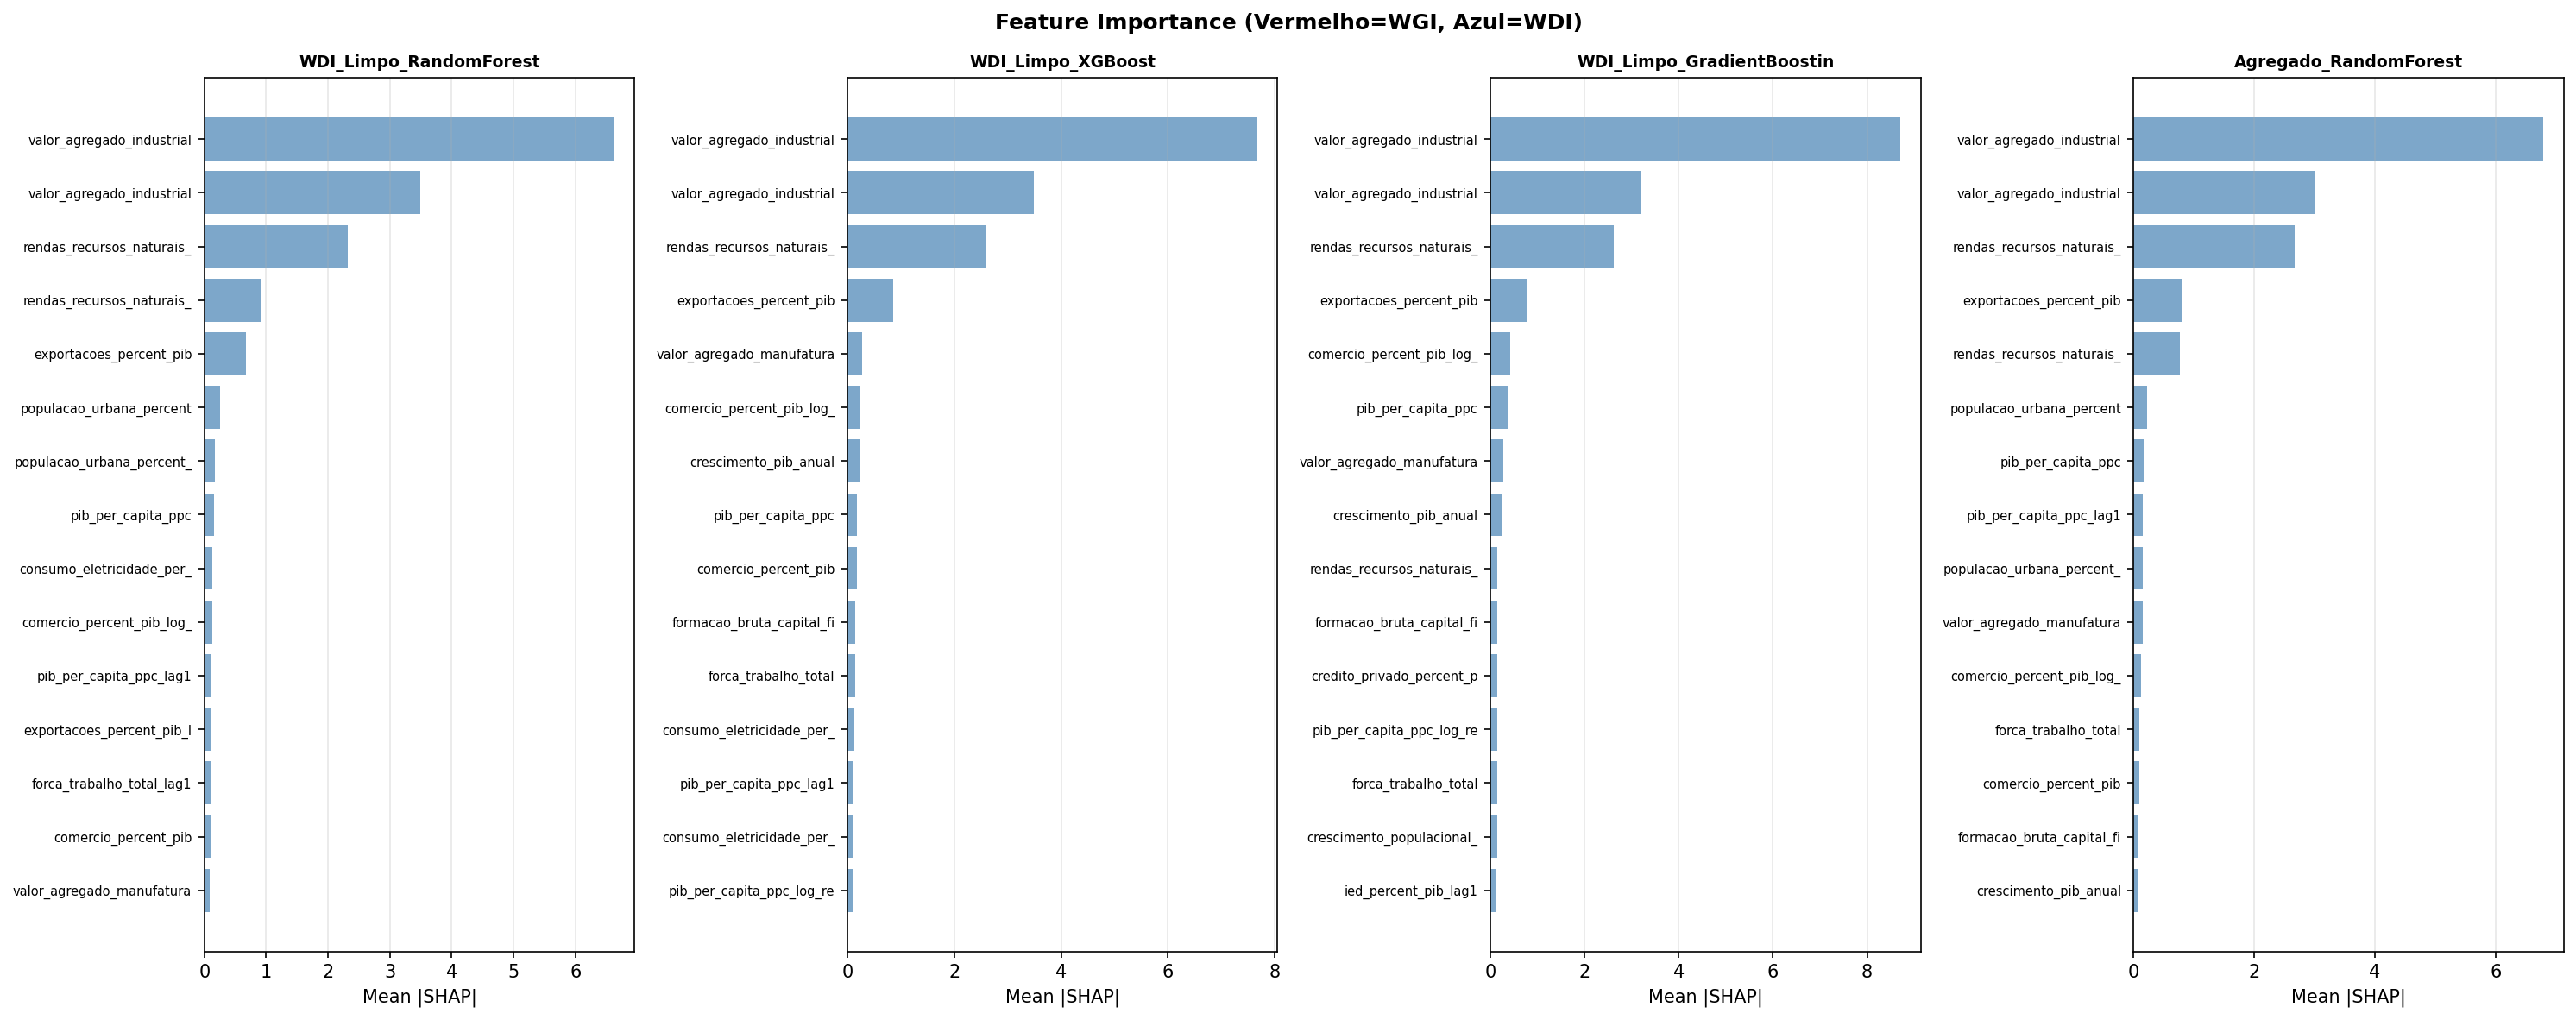

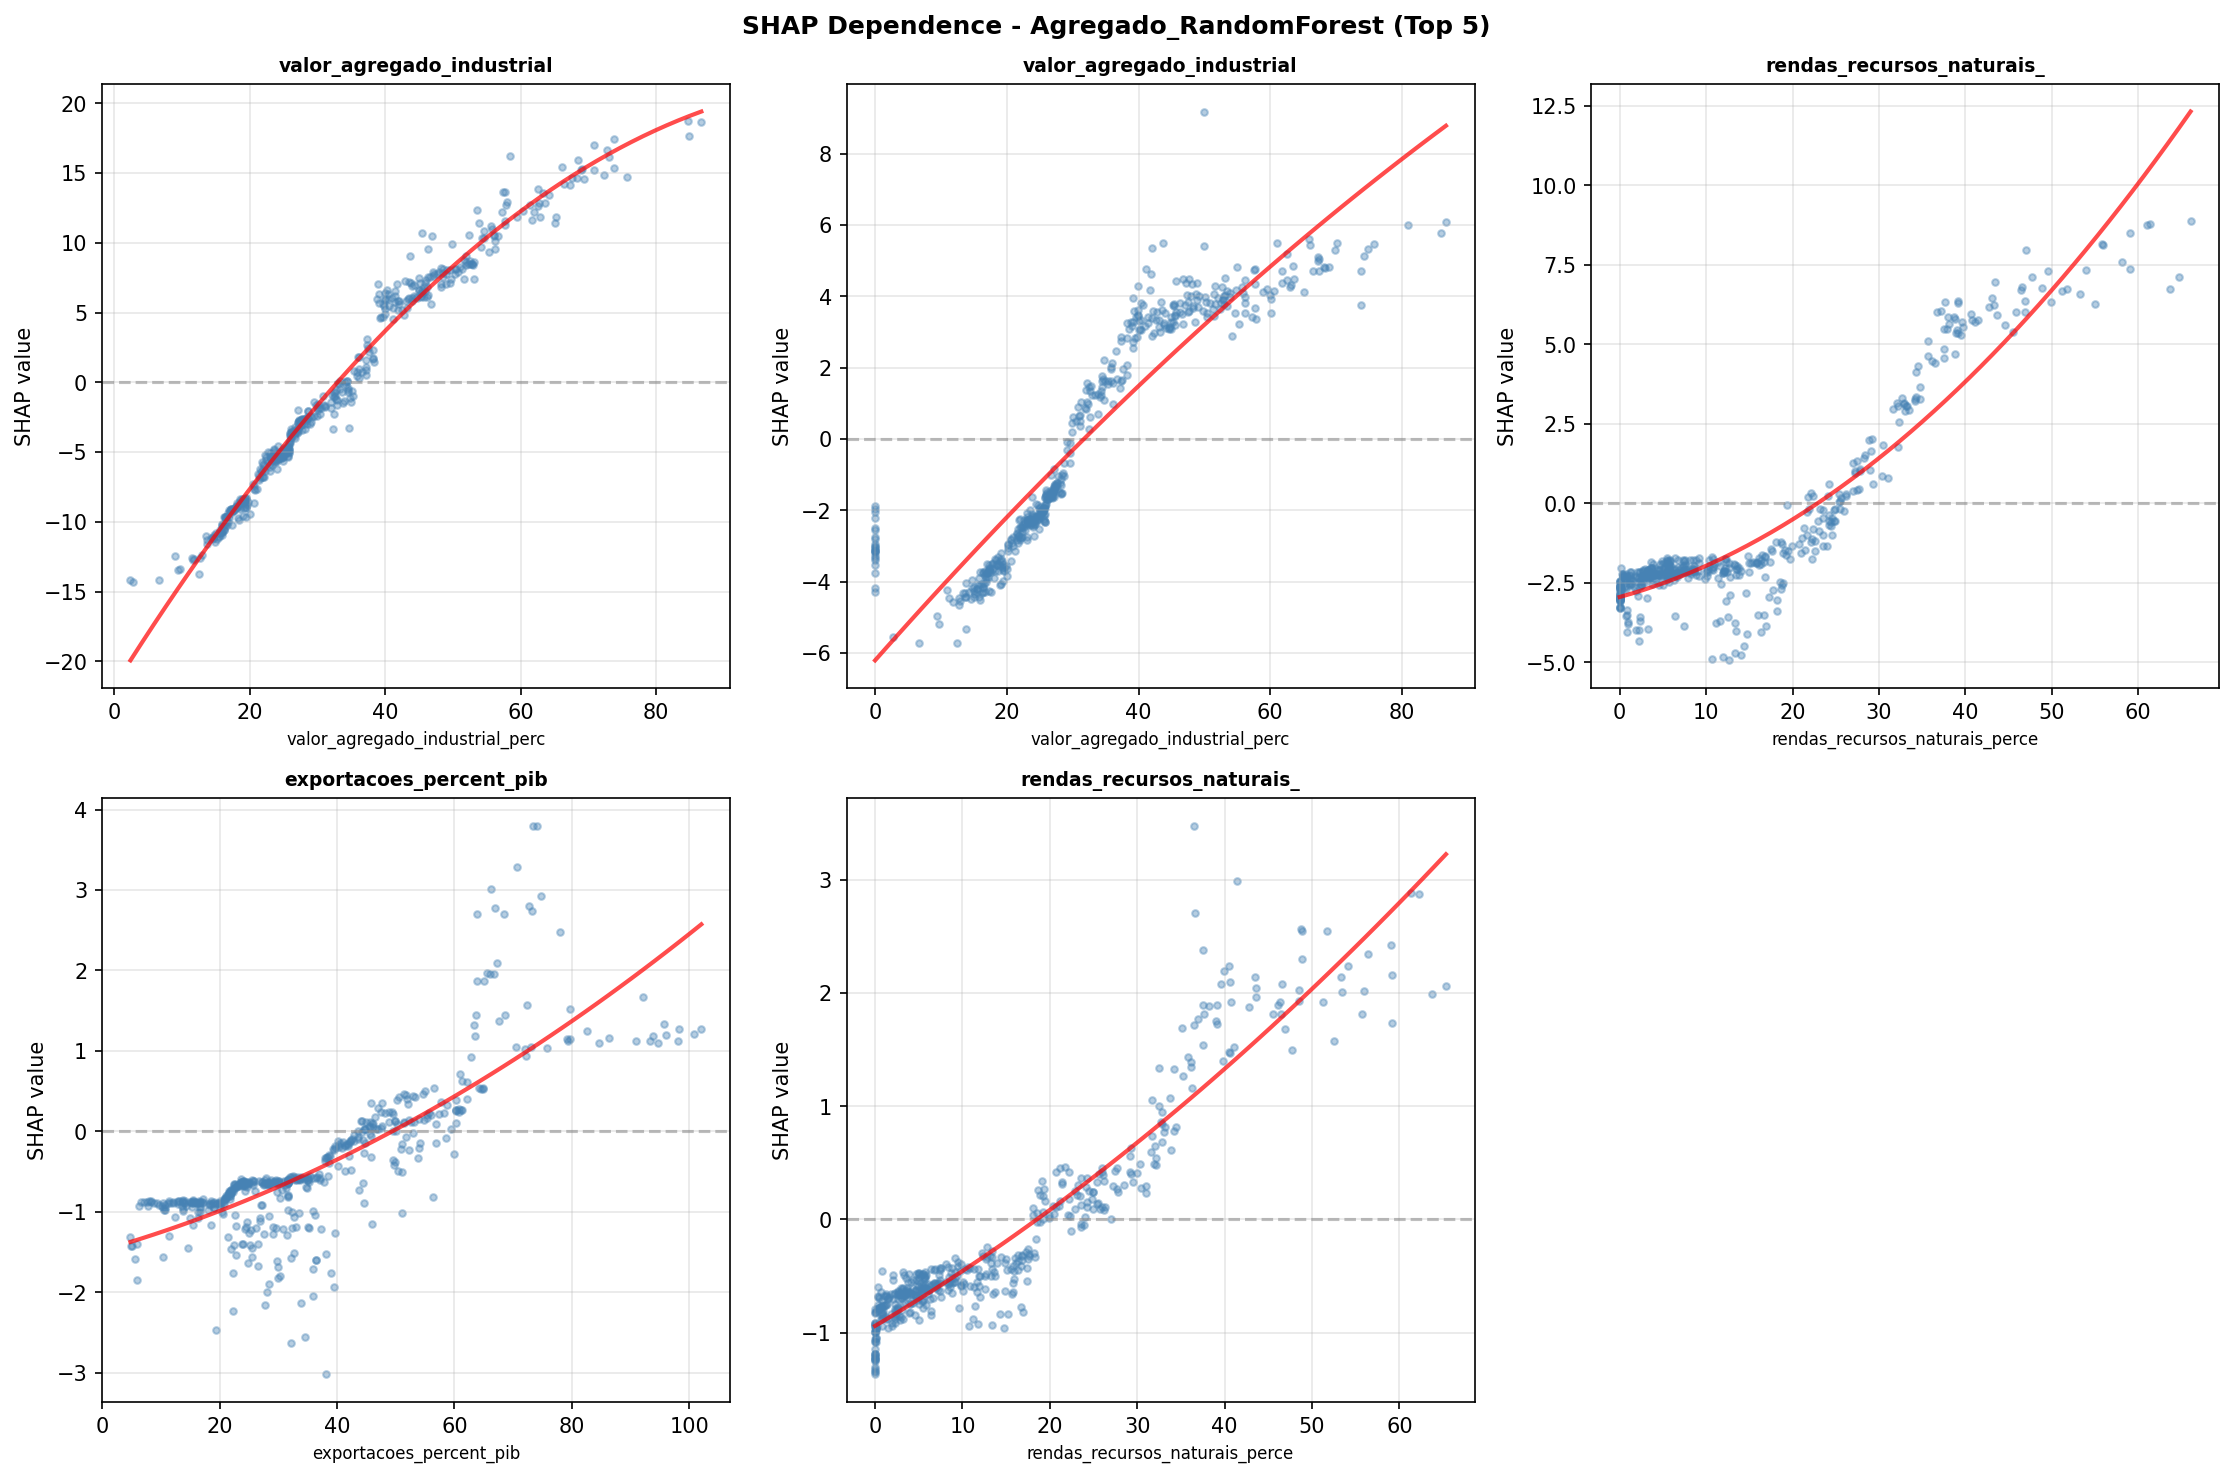

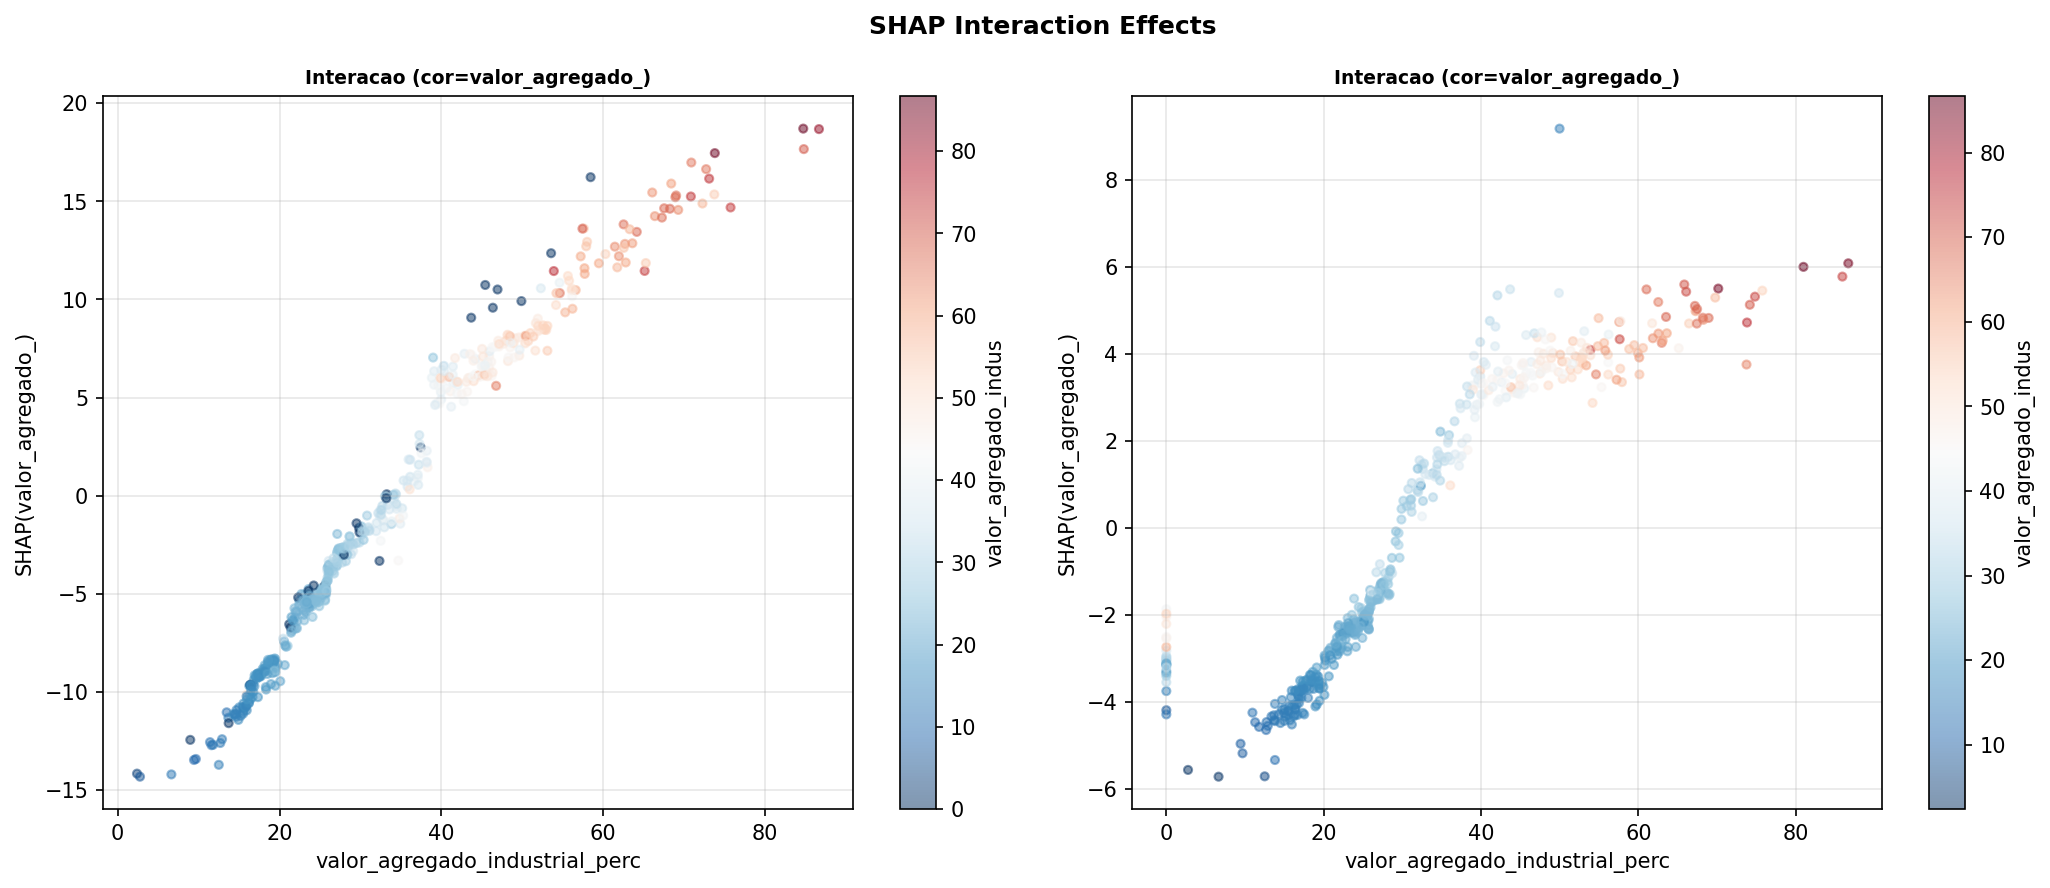

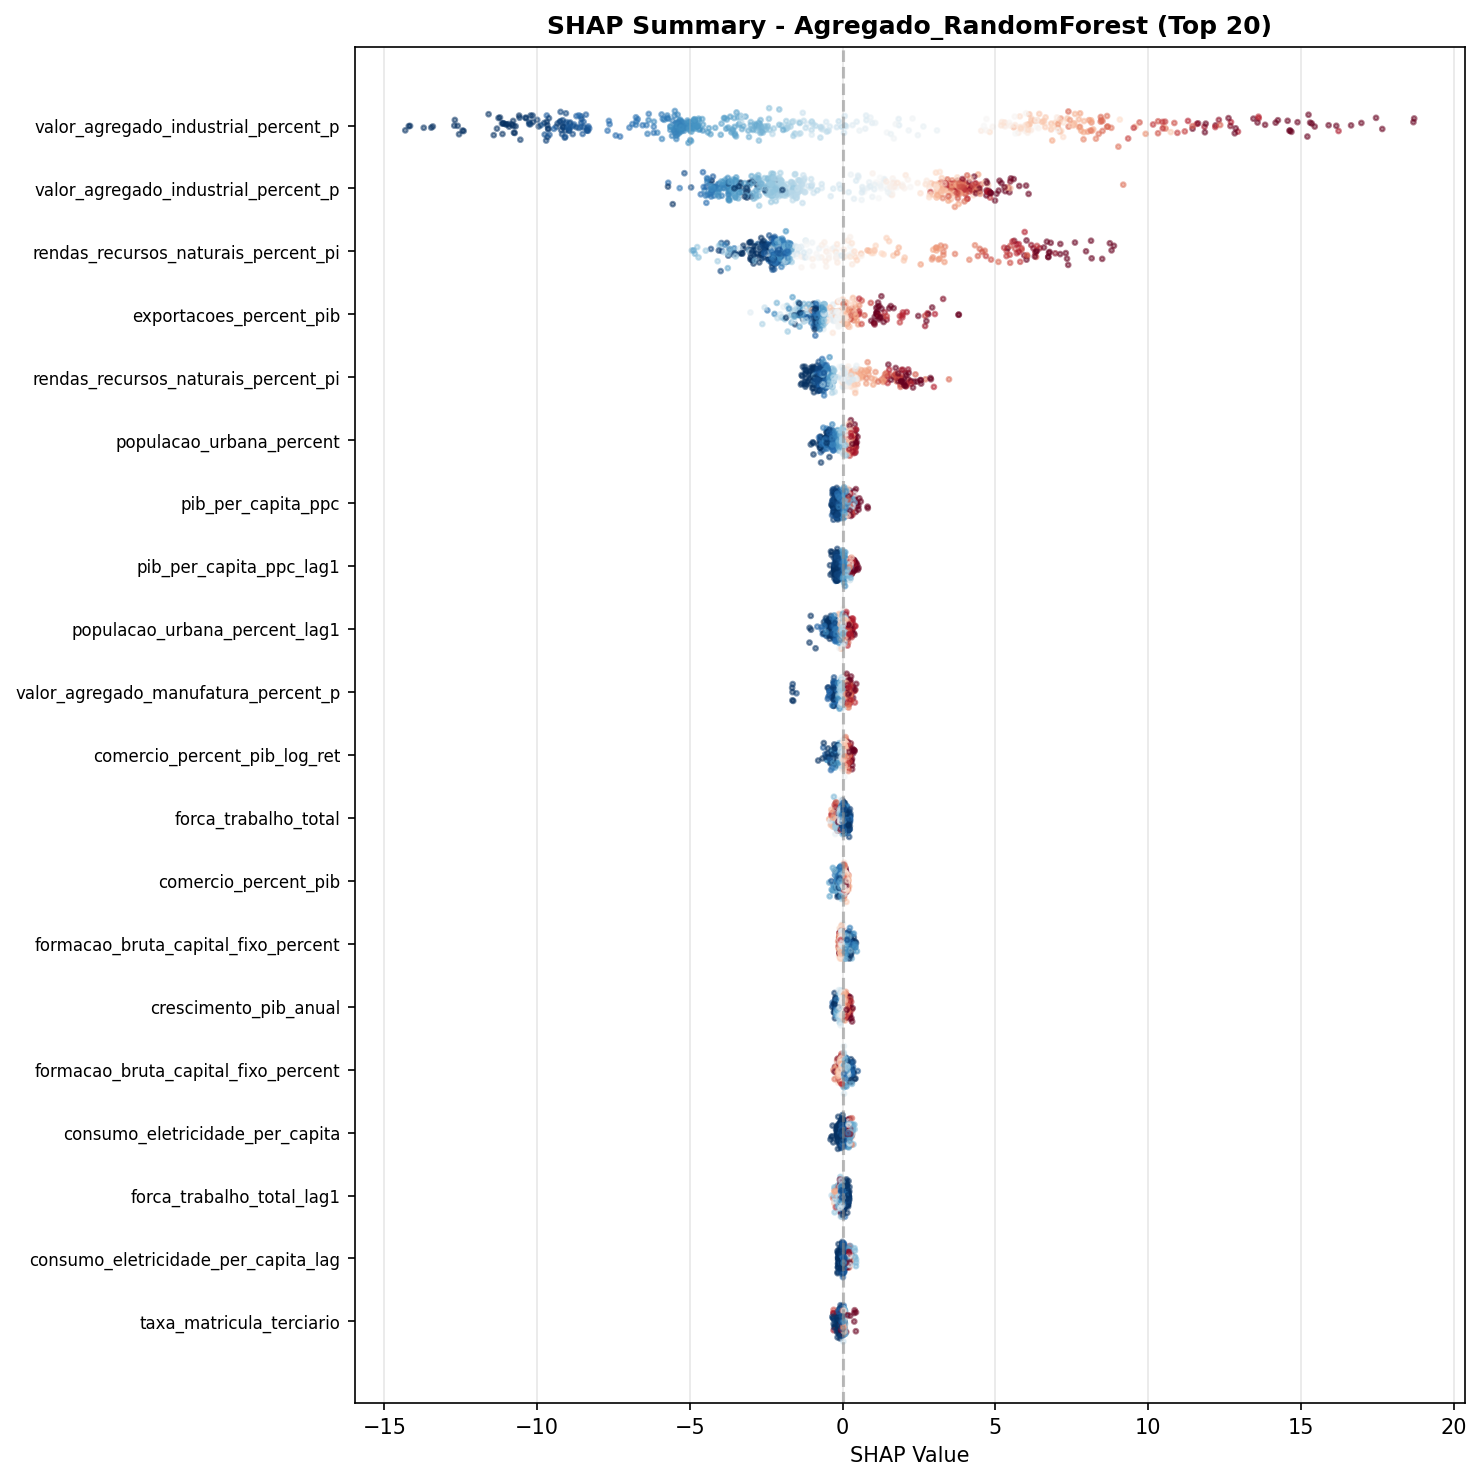


✓ 8 imagens visualizadas com sucesso!


In [47]:
# Visualizar imagens geradas no Passo 7
mostrar_imagens(['shap_analysis'], titulo='Passo 7 - SHAP Interpretabilidade')

---
## 8. Análise Geográfica

In [39]:
print("\n" + "="*70)
print("  PASSO 8: ANÁLISE GEOGRÁFICA")
print("="*70)

t0 = time.time()
from passo8_geografica import executar_passo8
executar_passo8()

tempo_p8 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p8:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 8: ANÁLISE GEOGRÁFICA

  PASSO 8: ANALISE GEOGRAFICA AVANCADA

  [1/7] Carregando dados e modelos...

  [2/7] Previsoes por pais...

  [3/7] Convergencia beta...
    Beta = -0.0087 (p=0.1212), IC95%=[-0.0159, 0.0022]
    Convergencia: Nao

  [4/7] Quebras estruturais (Chow test)...
    Quebras significativas: 34/37

  [5/7] Clusters geograficos...

  [6/7] Analise por regiao...

  [7/7] Gerando 7 visualizacoes...
[METADADOS] passo8_geografica → /content/repo/metadados/passo8_geografica_metadata.json
[AUTO-SAVE] 5 ficheiros copiados para Google Drive

  RESUMO PASSO 8: 37 paises | beta=-0.008691899218974675 | 34 quebras | 7 graficos | 9.6s
  OK PASSO 8 CONCLUIDO

  ⏱ Tempo: 9.6s
  📁 11 ficheiros sincronizados com o Drive


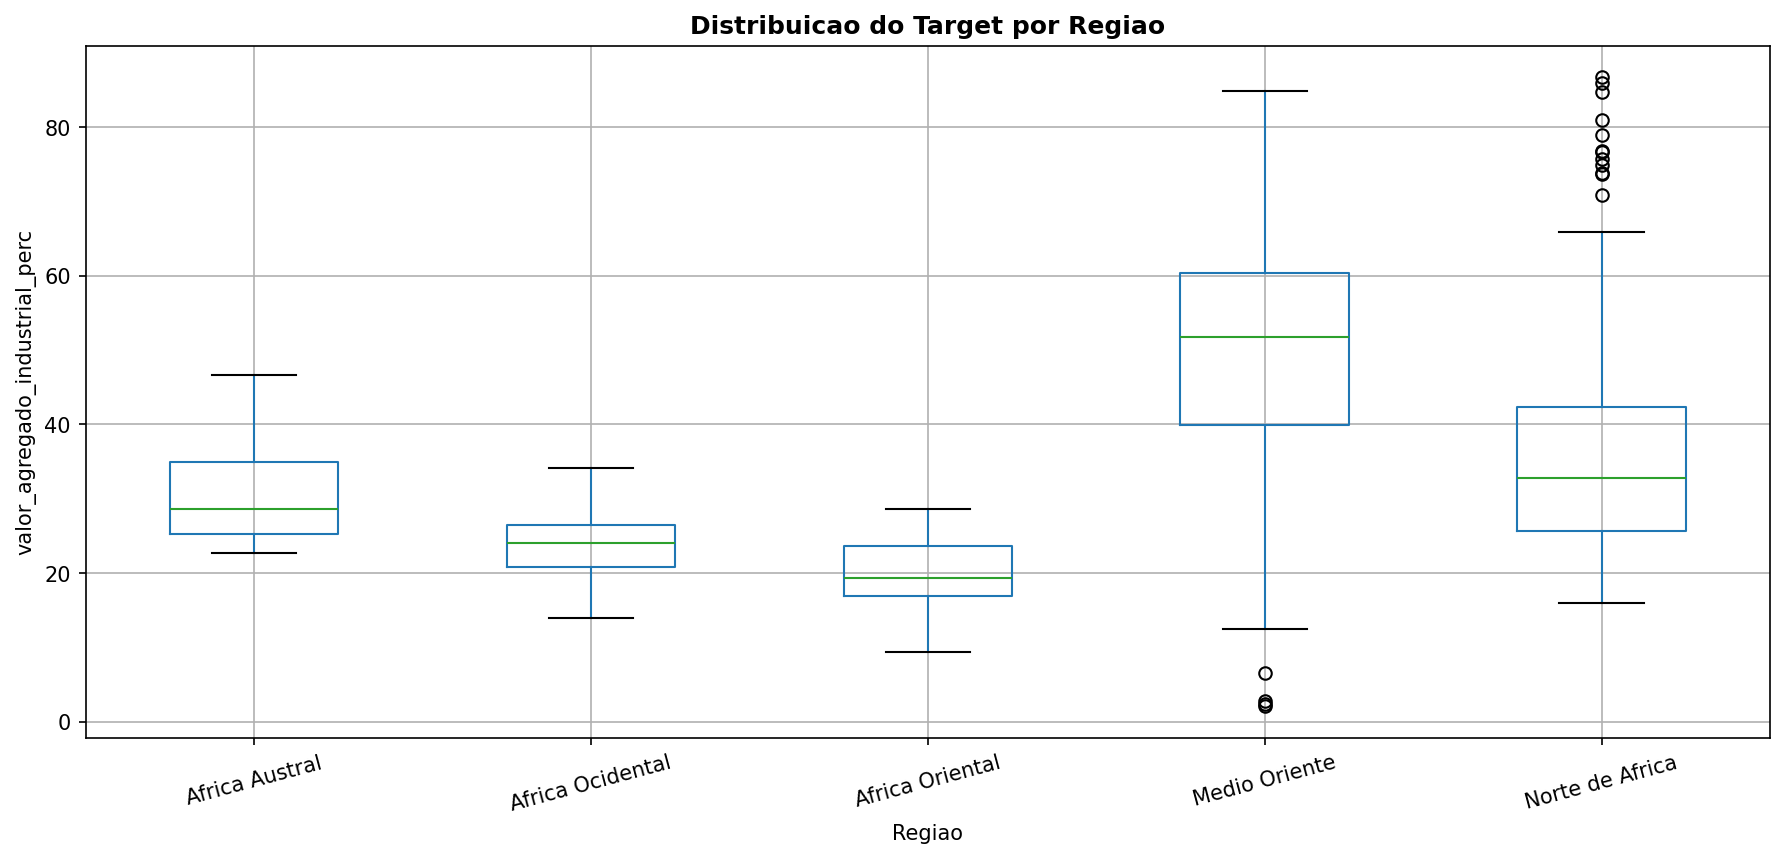

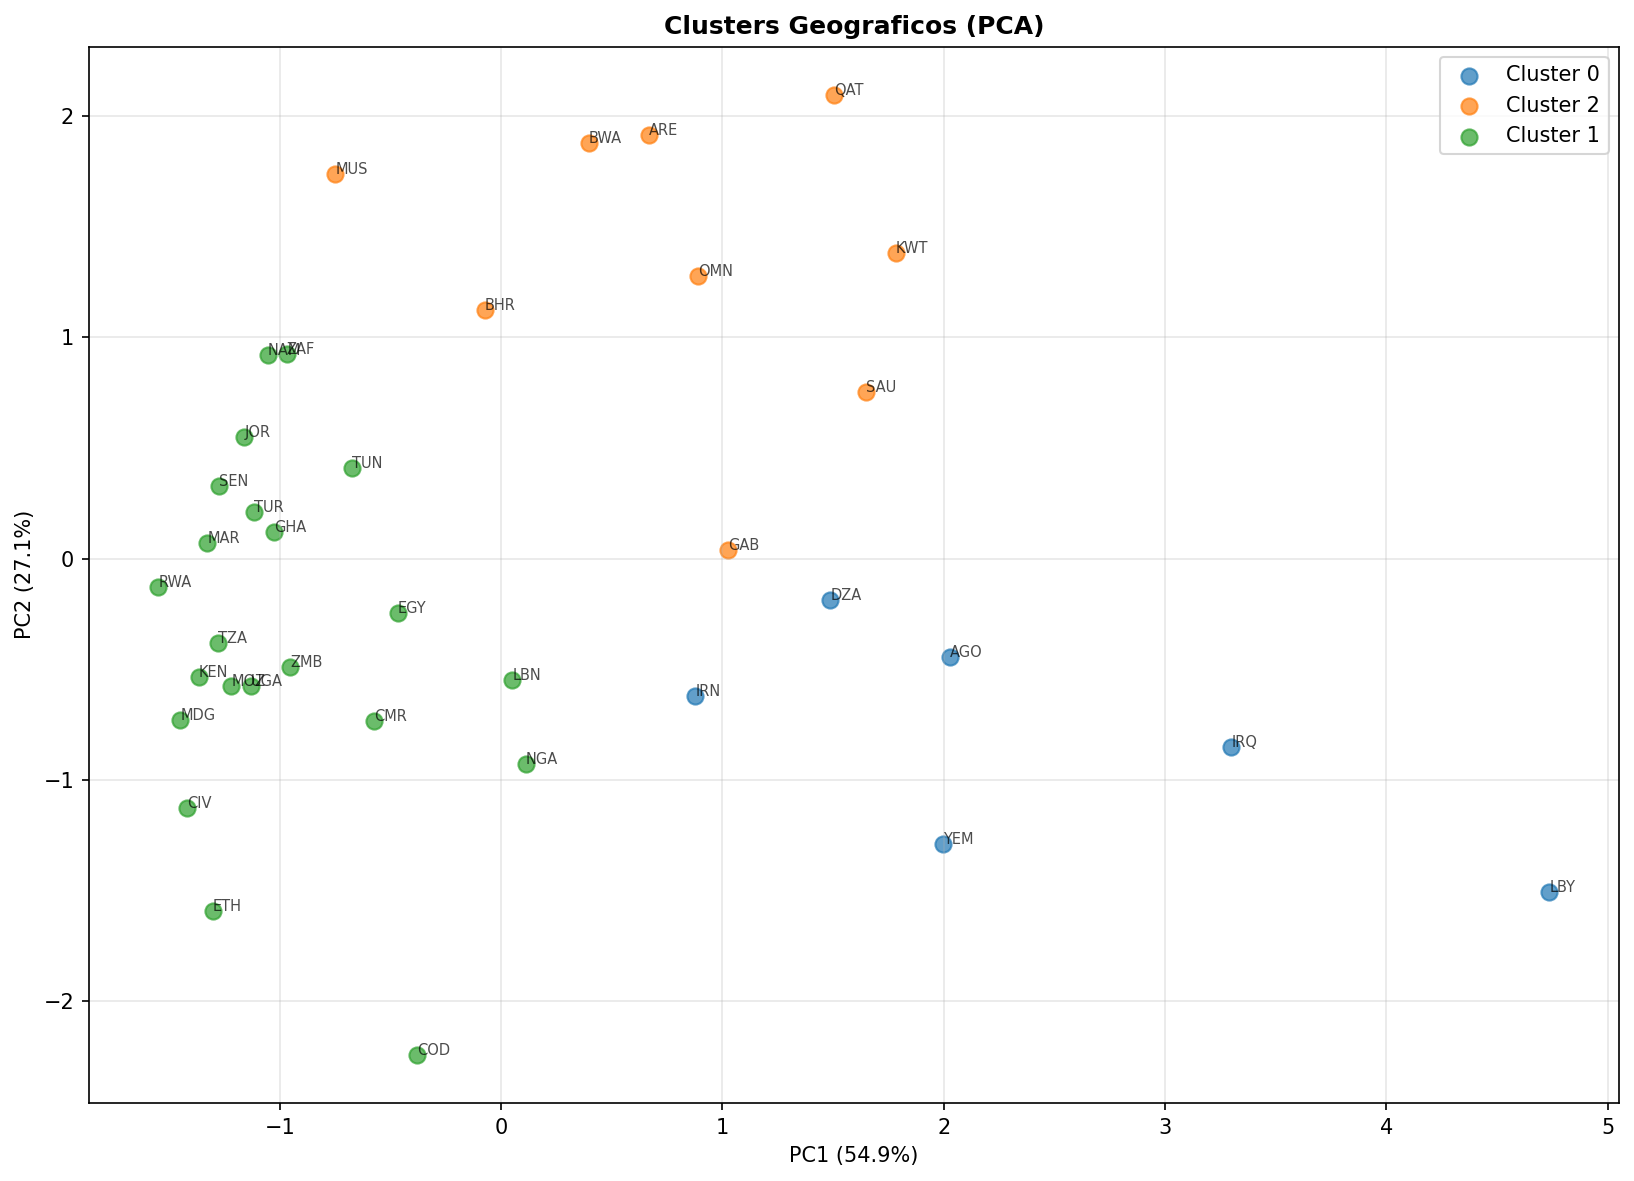

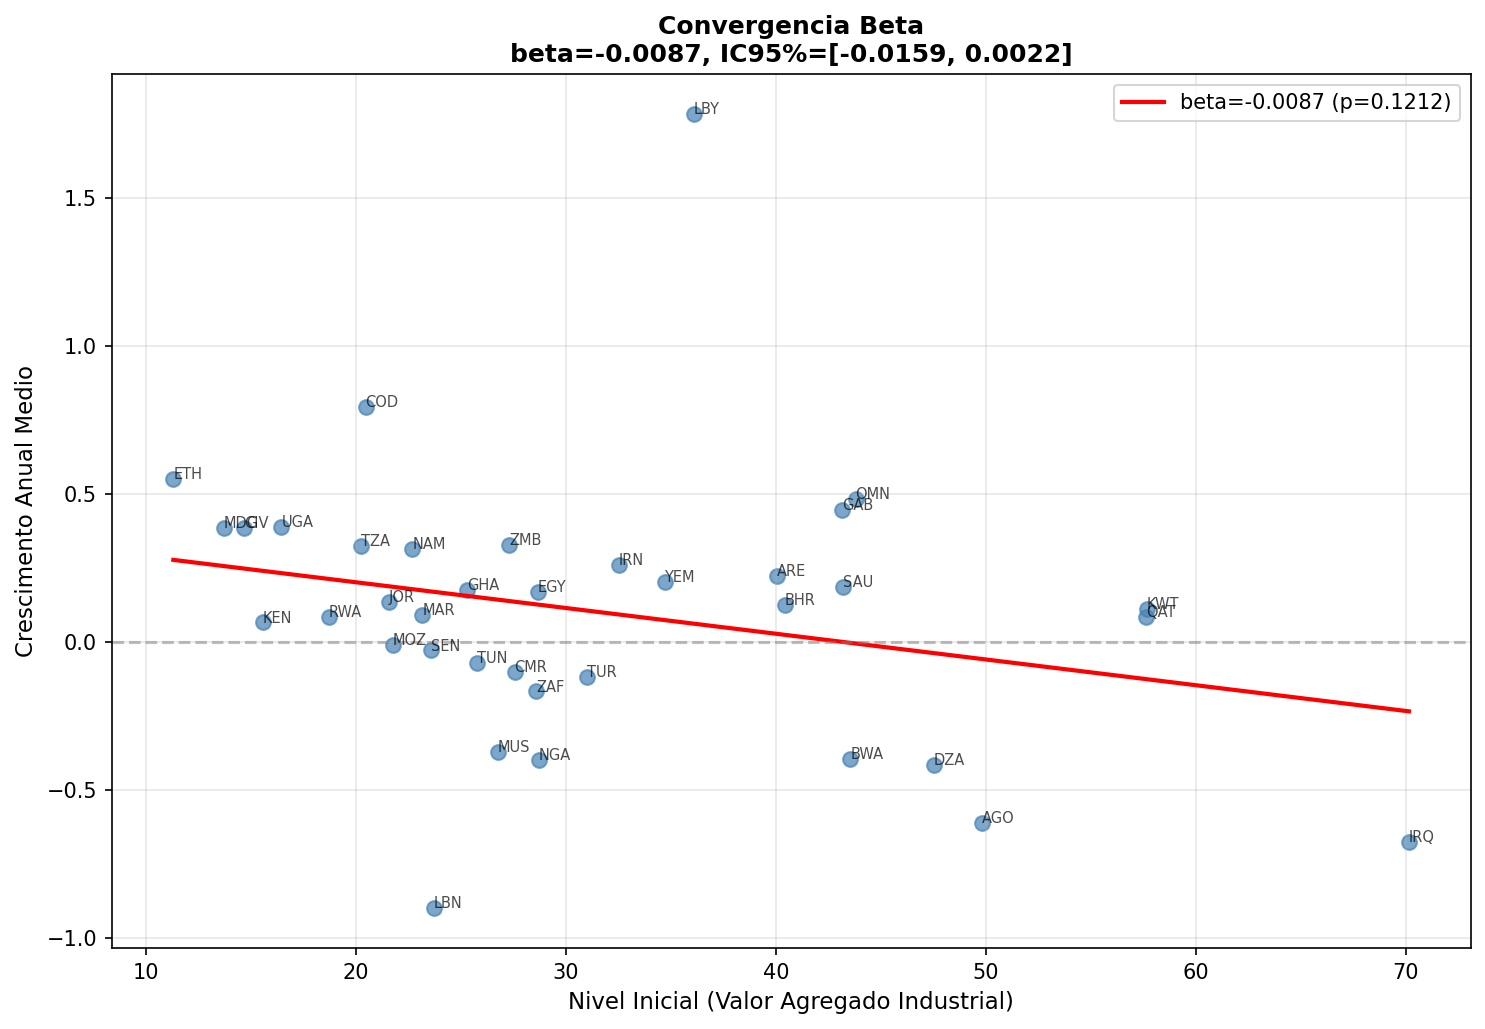

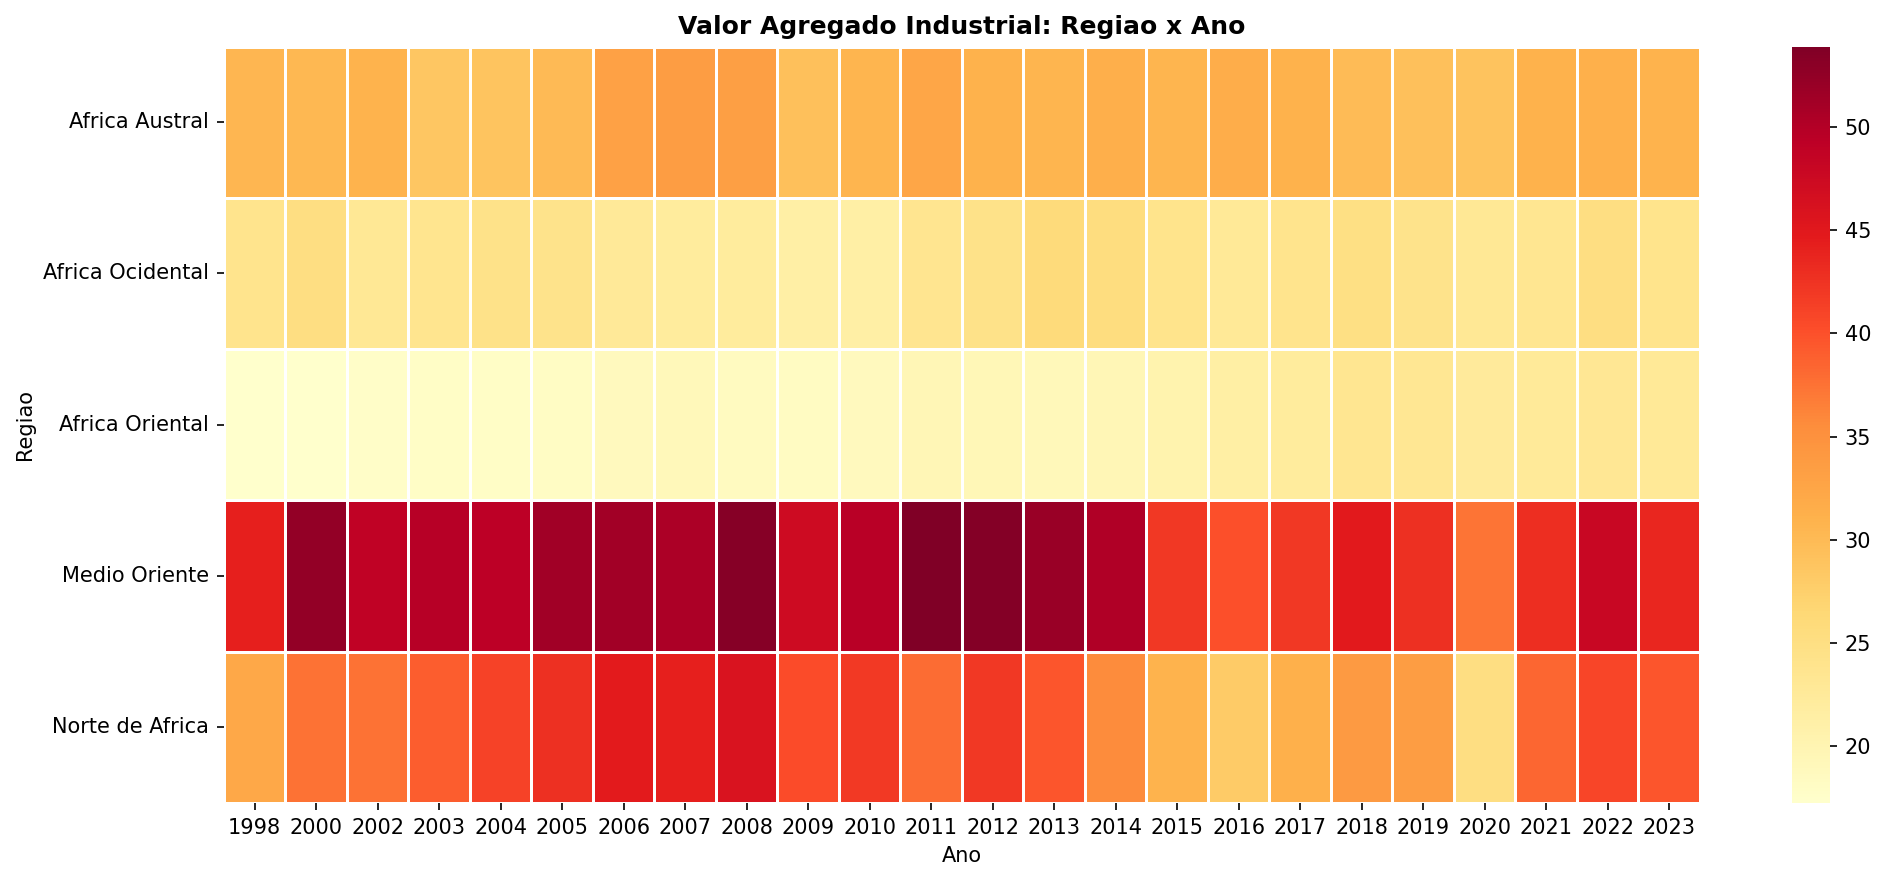

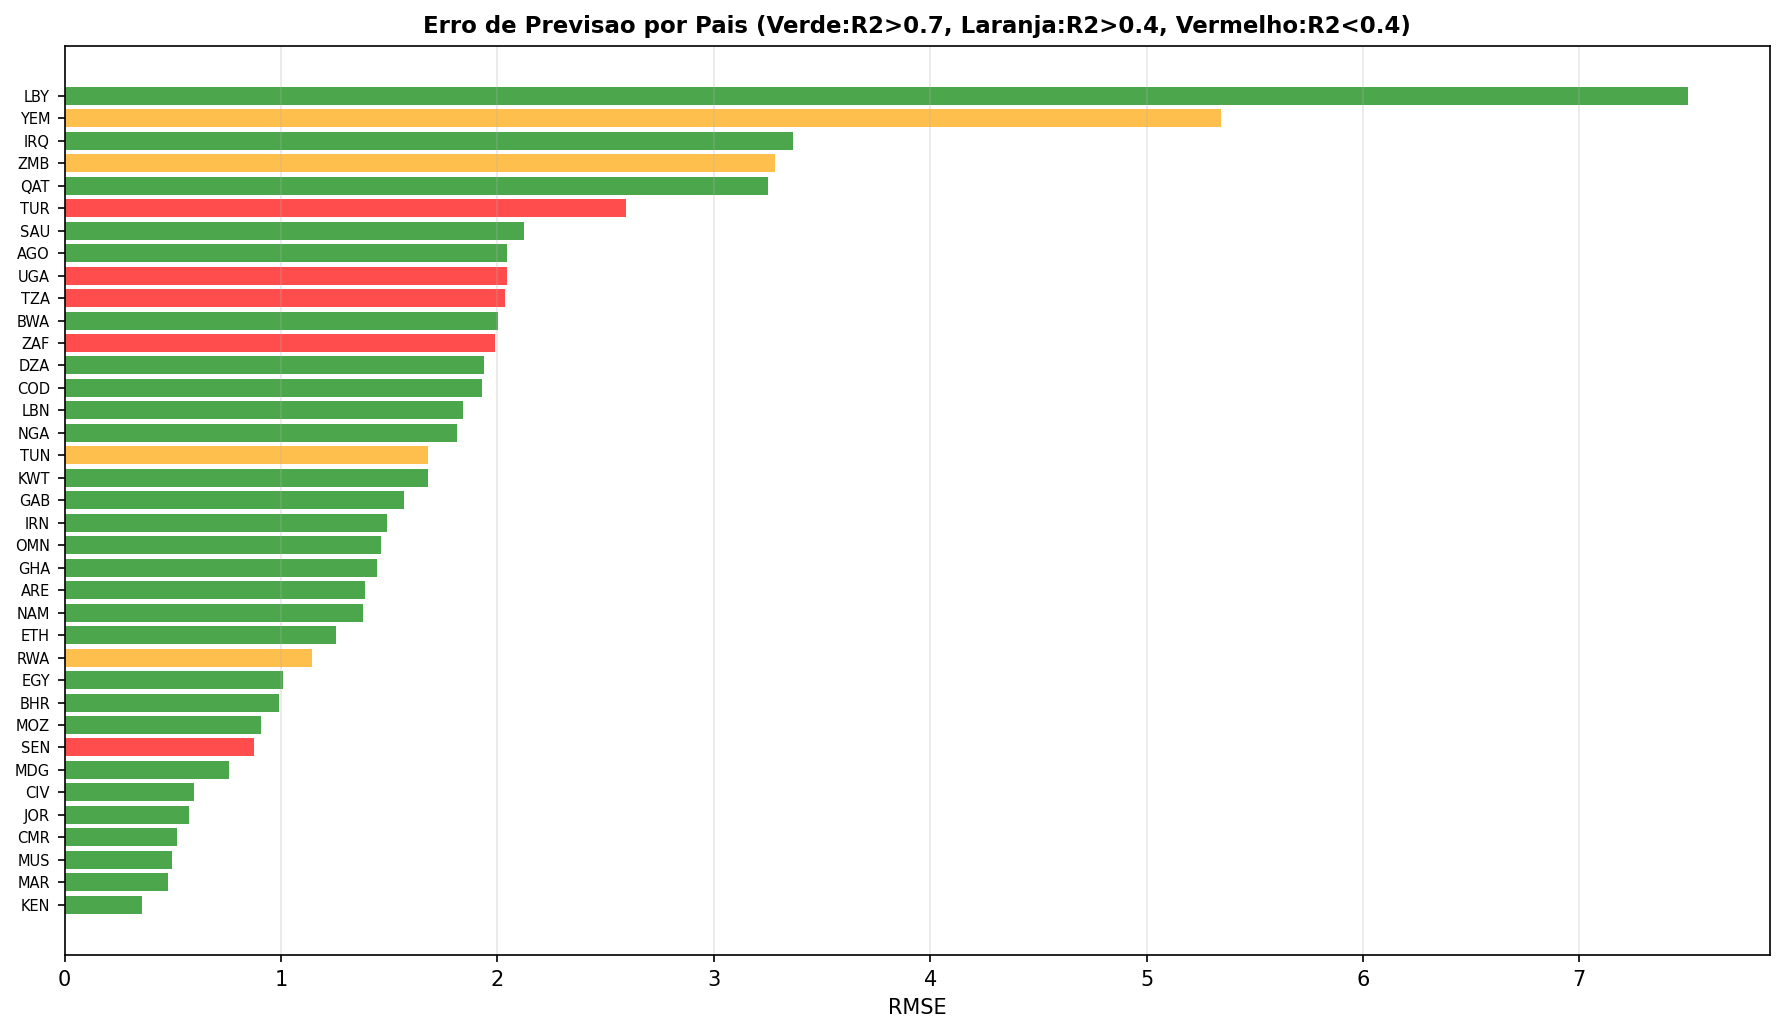

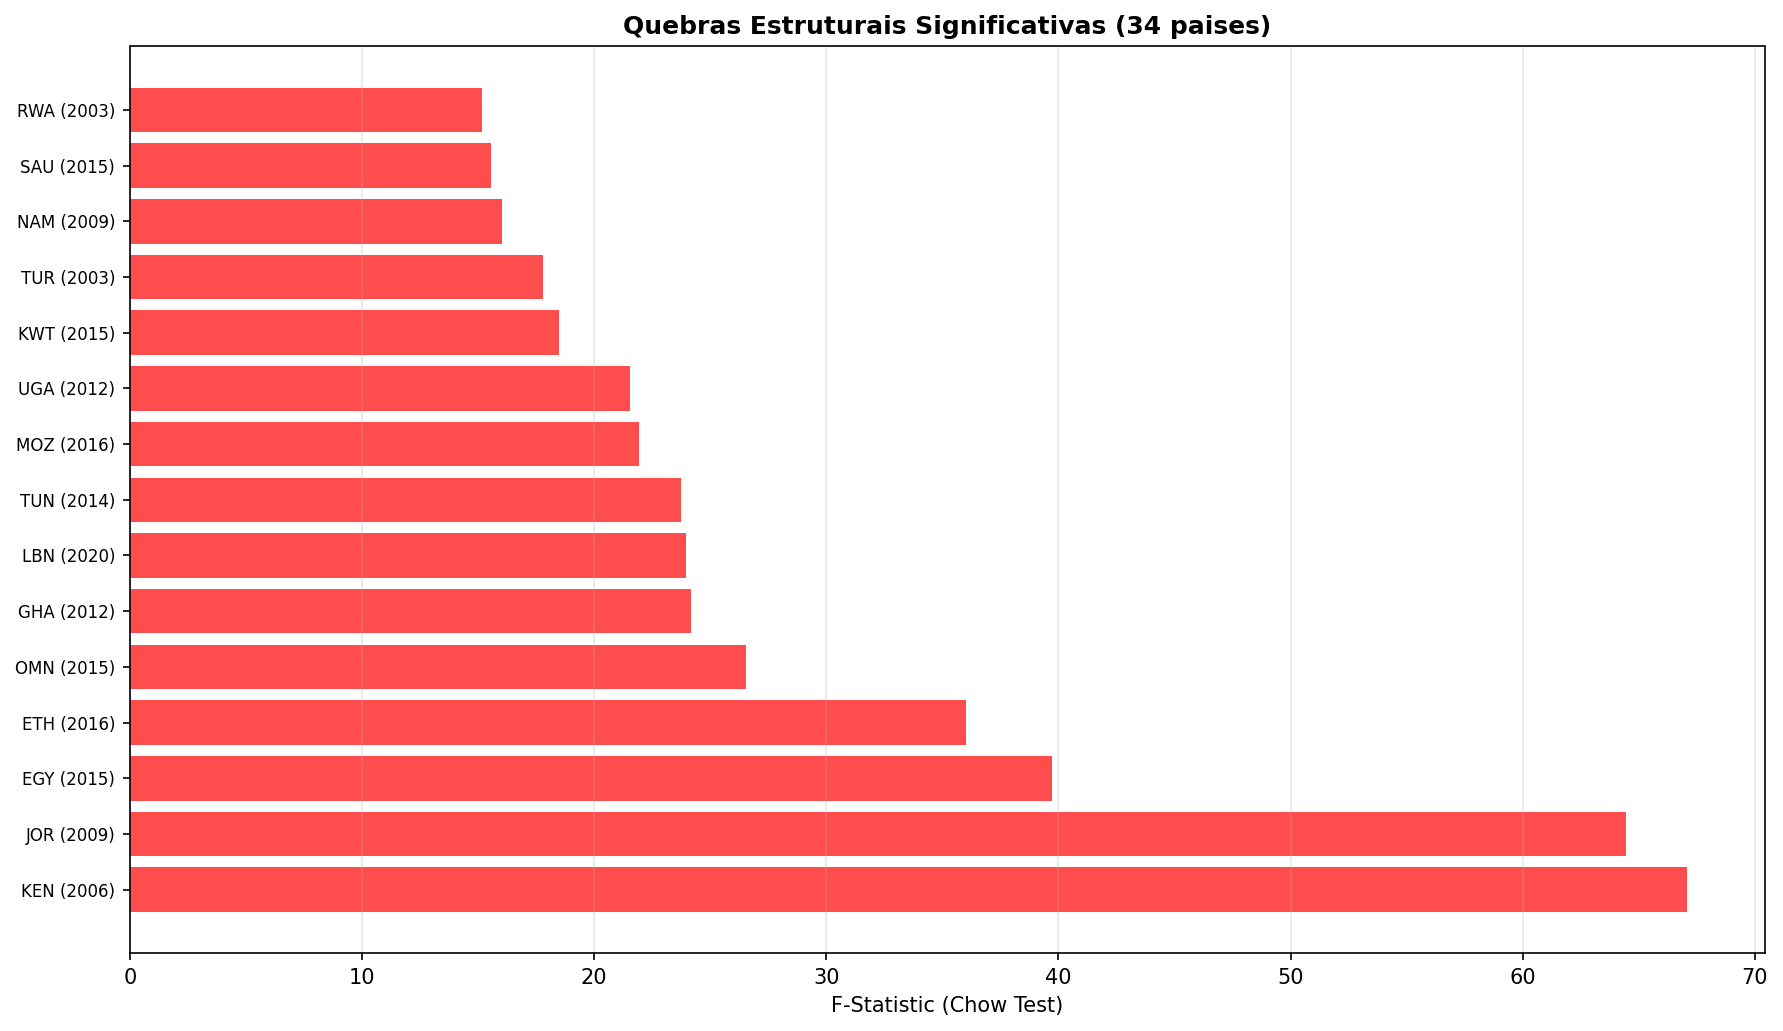

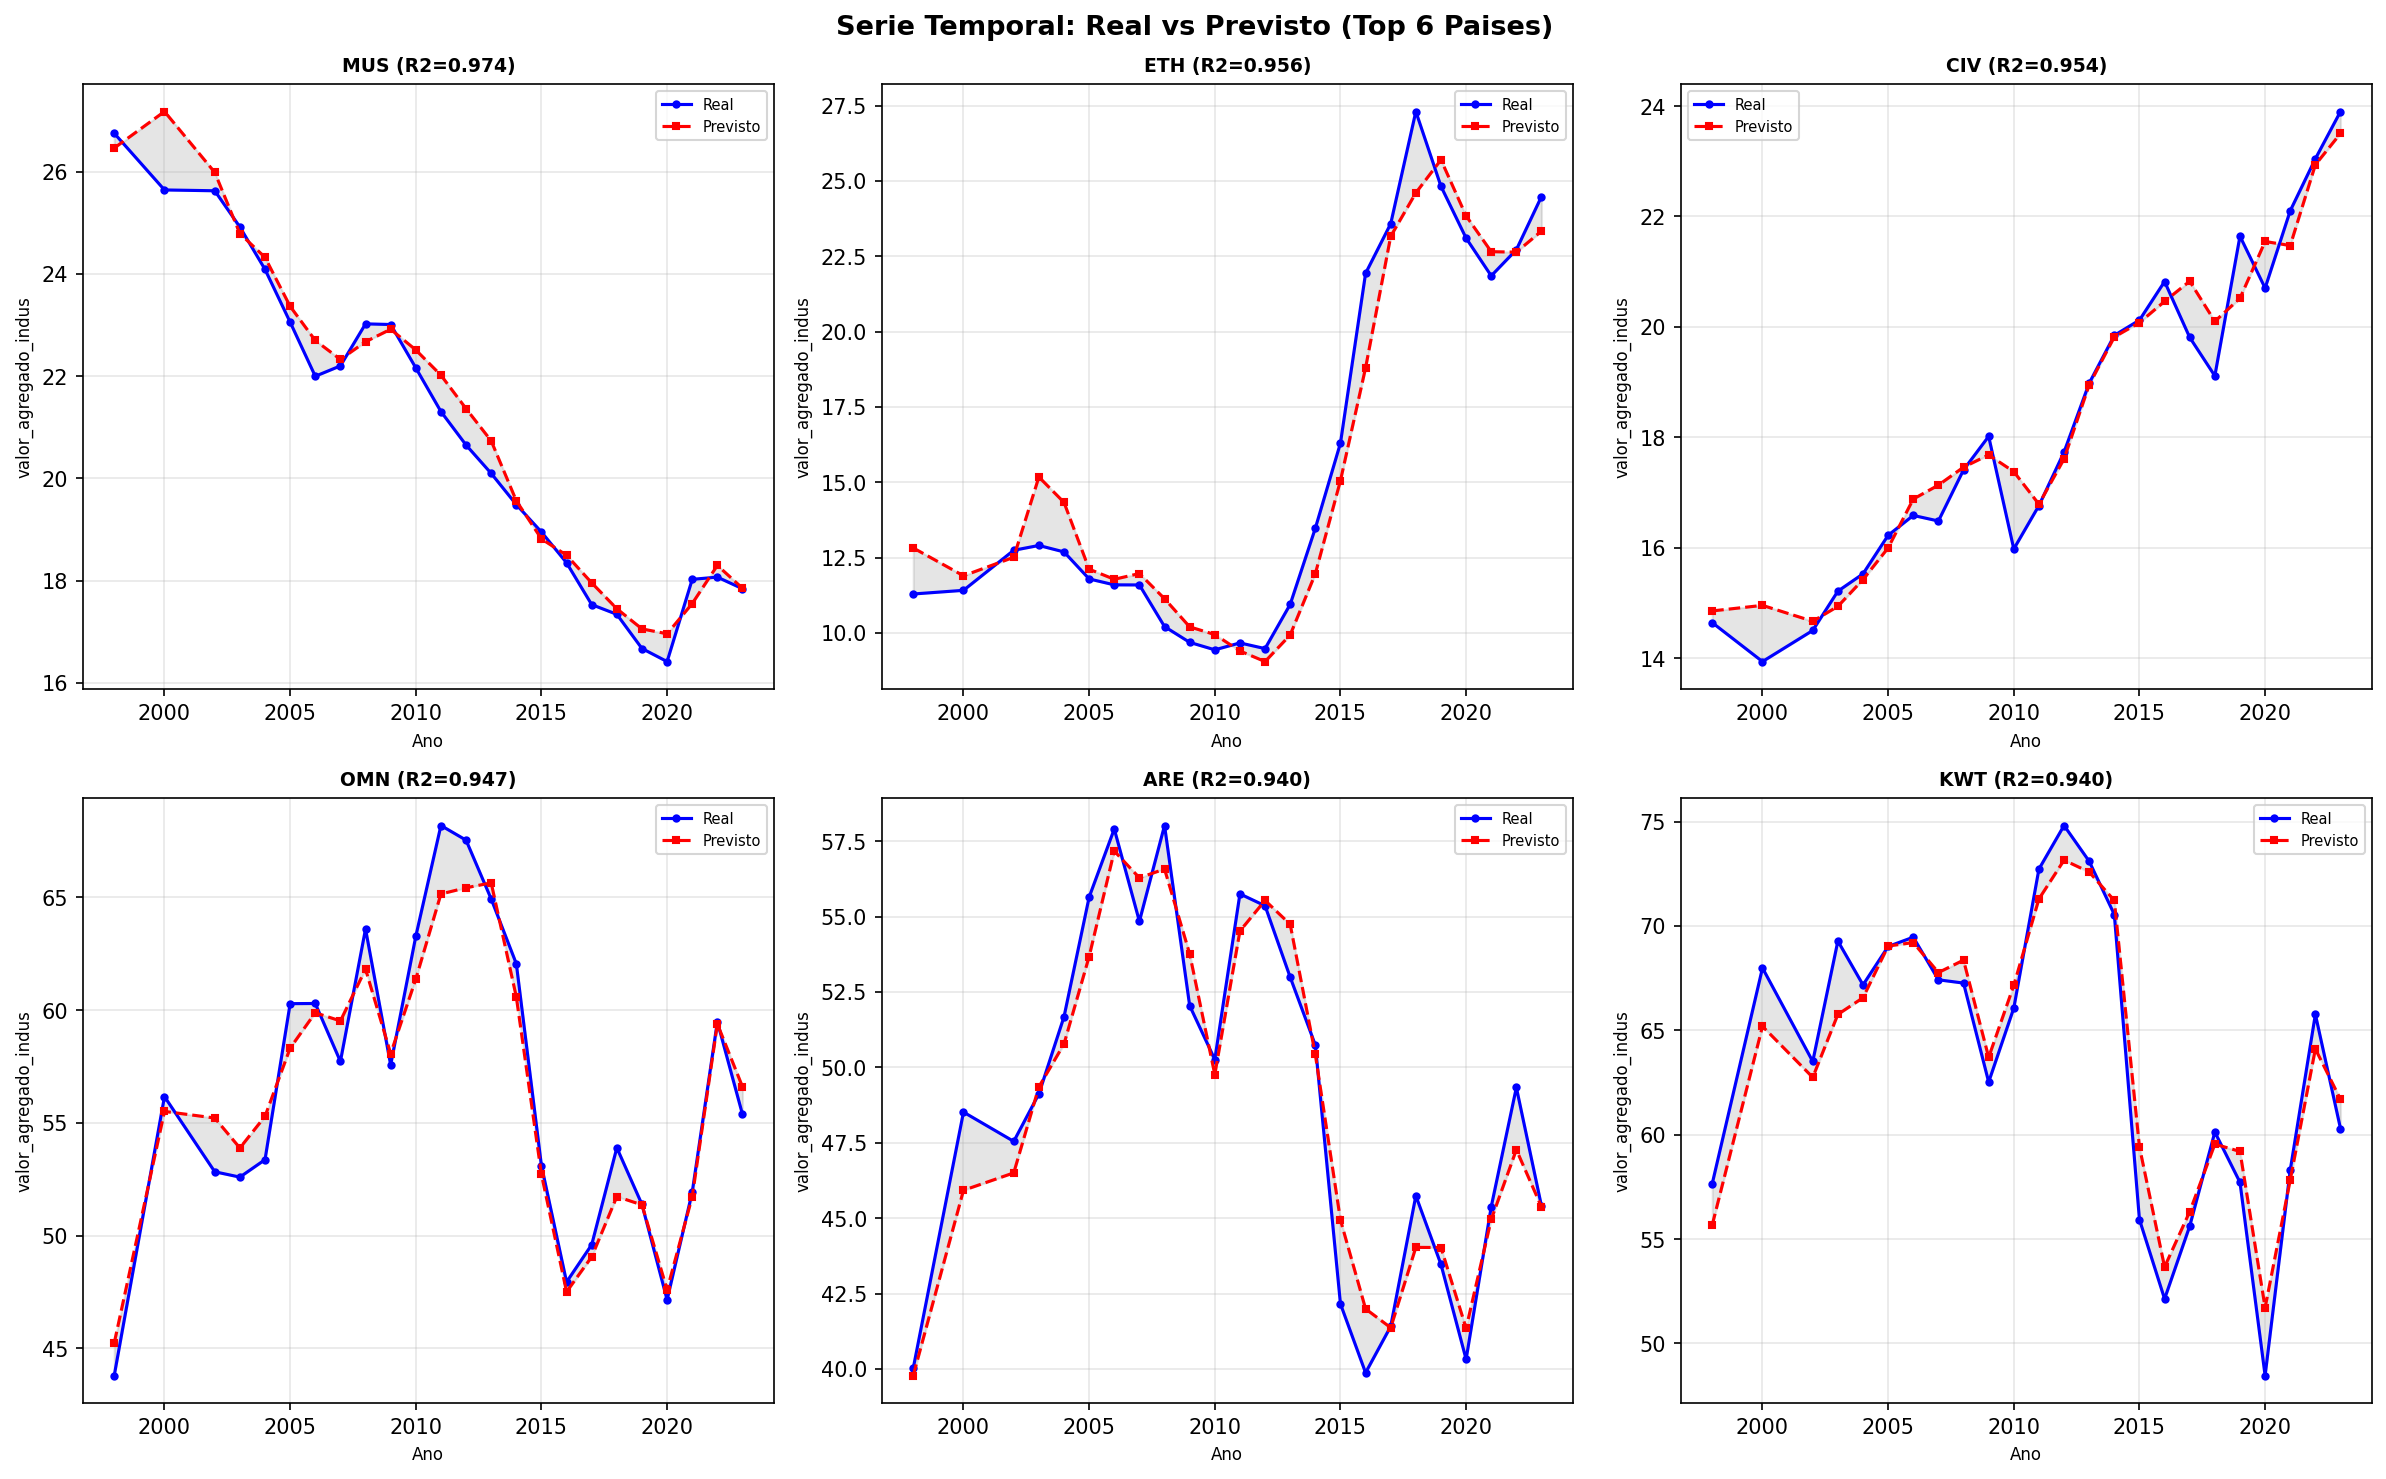


✓ 7 imagens visualizadas com sucesso!


In [49]:
# Visualizar imagens geradas no Passo 8
mostrar_imagens(['analise_geografica'], titulo='Passo 8 - Análise Geográfica')

---
## 9. Análises Avançadas

In [41]:
print("\n" + "="*70)
print("  PASSO 9: ANÁLISES AVANÇADAS")
print("="*70)

t0 = time.time()
from passo9_avancada import executar_passo9
executar_passo9()

tempo_p9 = time.time() - t0
print(f"\n  ⏱ Tempo: {tempo_p9:.1f}s")

# Sincronizar TODOS os ficheiros com Drive
n_sync = sincronizar_todos_drive()
print(f"  📁 {n_sync} ficheiros sincronizados com o Drive")


  PASSO 9: ANÁLISES AVANÇADAS

  PASSO 9: ANALISES AVANCADAS

  [1/7] Carregando dados e modelos...
    Datasets: 3 | Modelo: OK

  [2/7] Convergencia sigma...
    Sigma trend: slope=-0.2158 (p=0.0064) -> Convergencia

  [3/7] Analise de sensibilidade (tornado)...

  [4/7] Cenarios de politica...

  [5/7] Elasticidades...

  [6/7] Causalidade de Granger...
    Granger significativos: 2/15

  [7/7] Analise de robustez...

  Gerando 7 visualizacoes...
[METADADOS] passo9_avancada → /content/repo/metadados/passo9_avancada_metadata.json
[AUTO-SAVE] 6 ficheiros copiados para Google Drive

  RESUMO PASSO 9: sigma=Conv | 2 Granger sig | 7 graficos | 29.9s
  OK PASSO 9 CONCLUIDO

  ⏱ Tempo: 29.9s
  📁 11 ficheiros sincronizados com o Drive


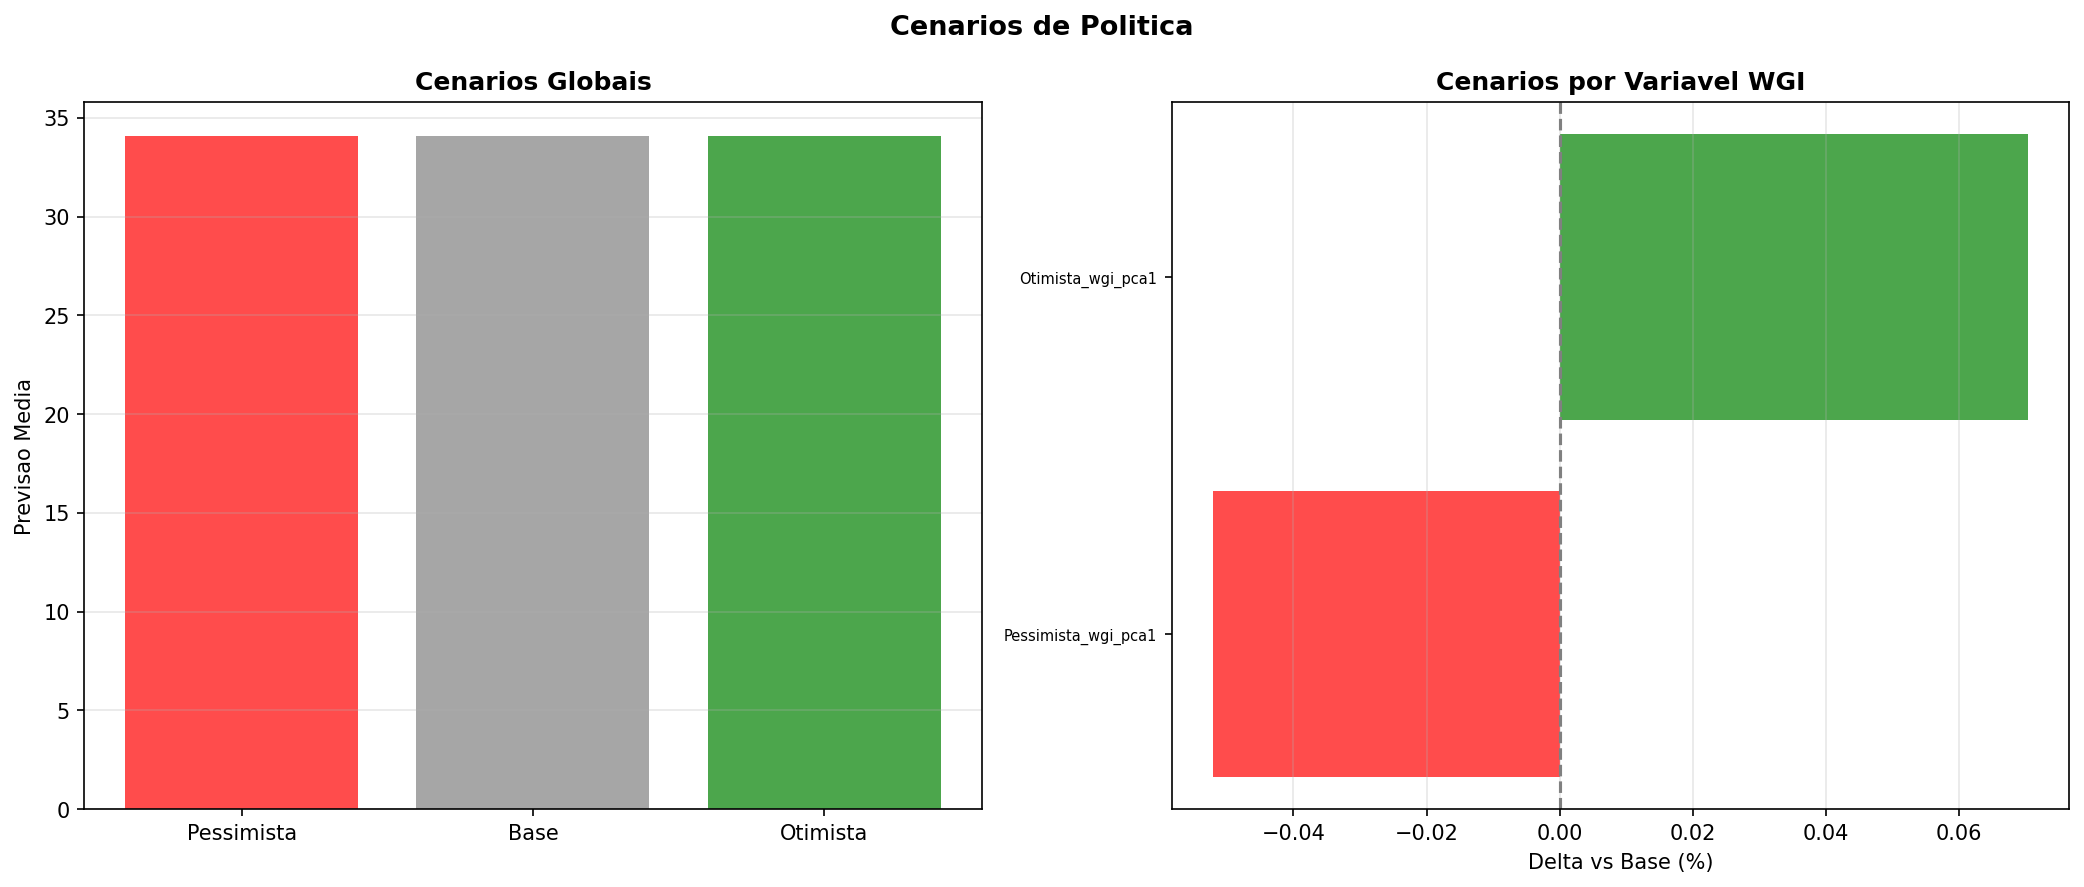

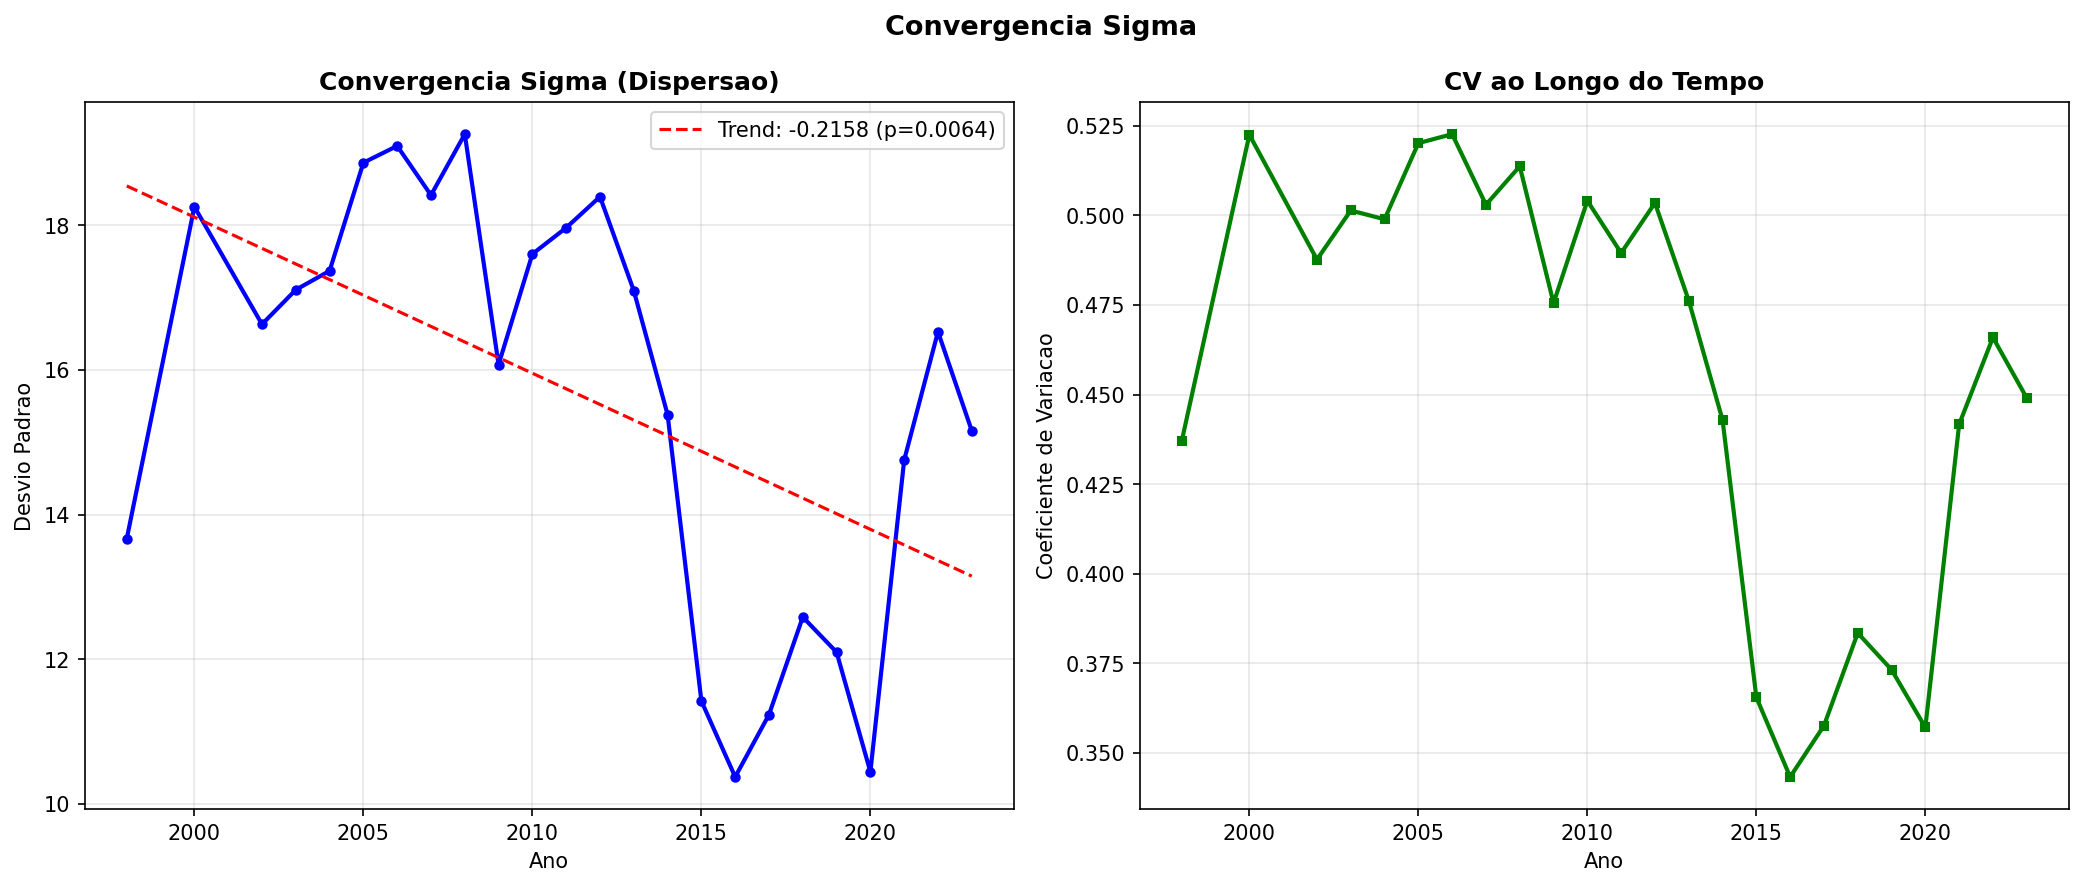

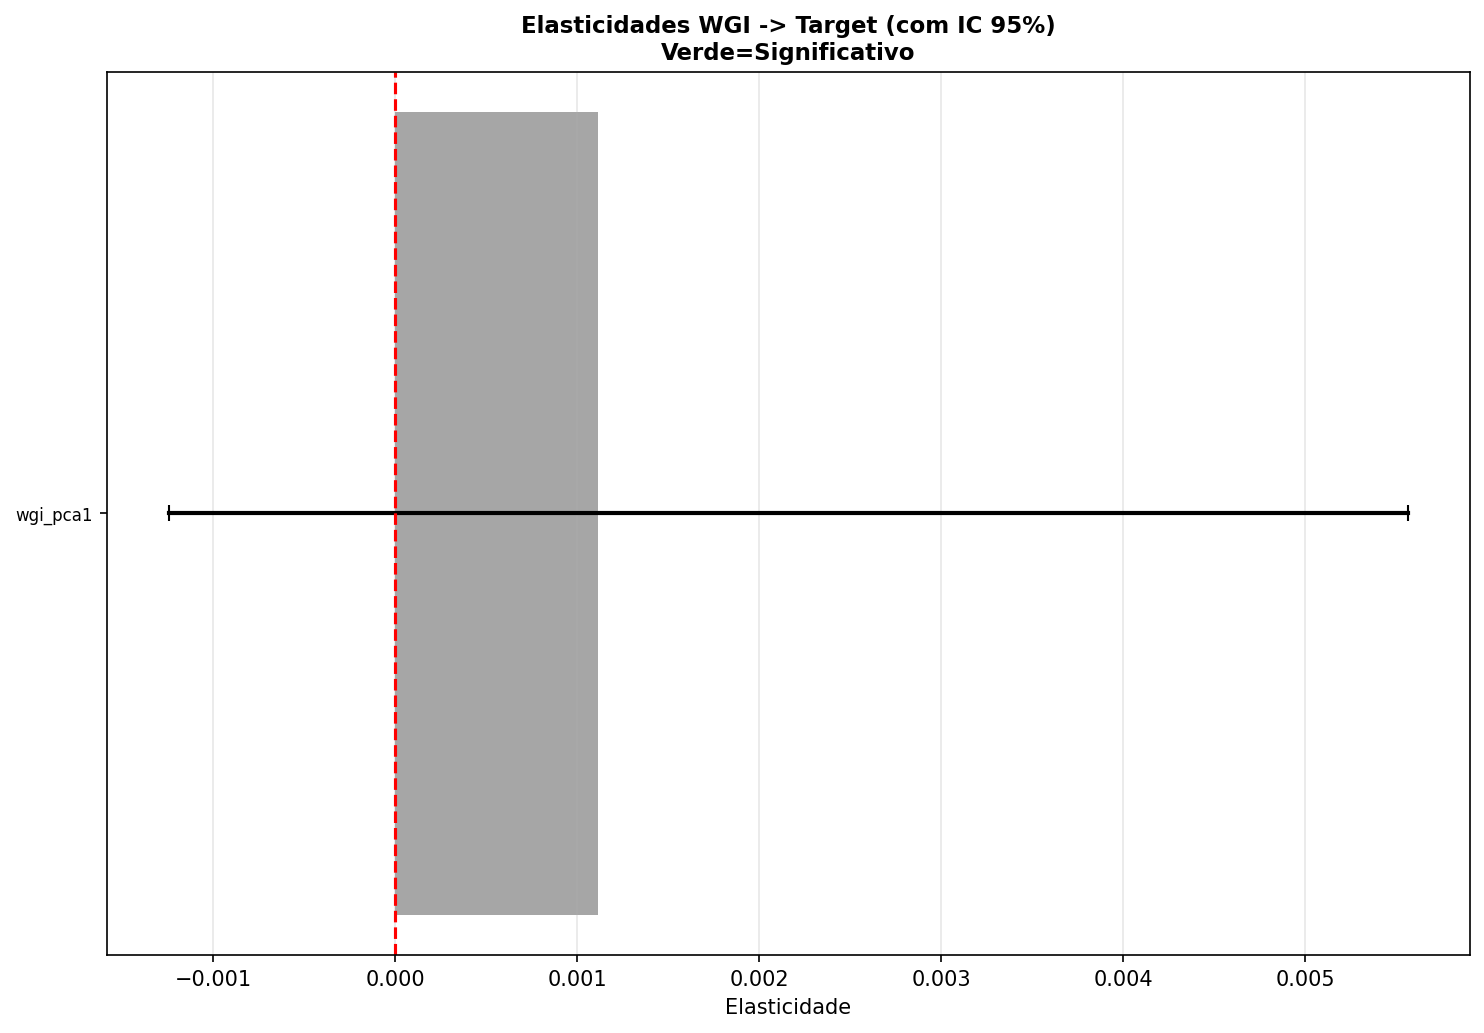

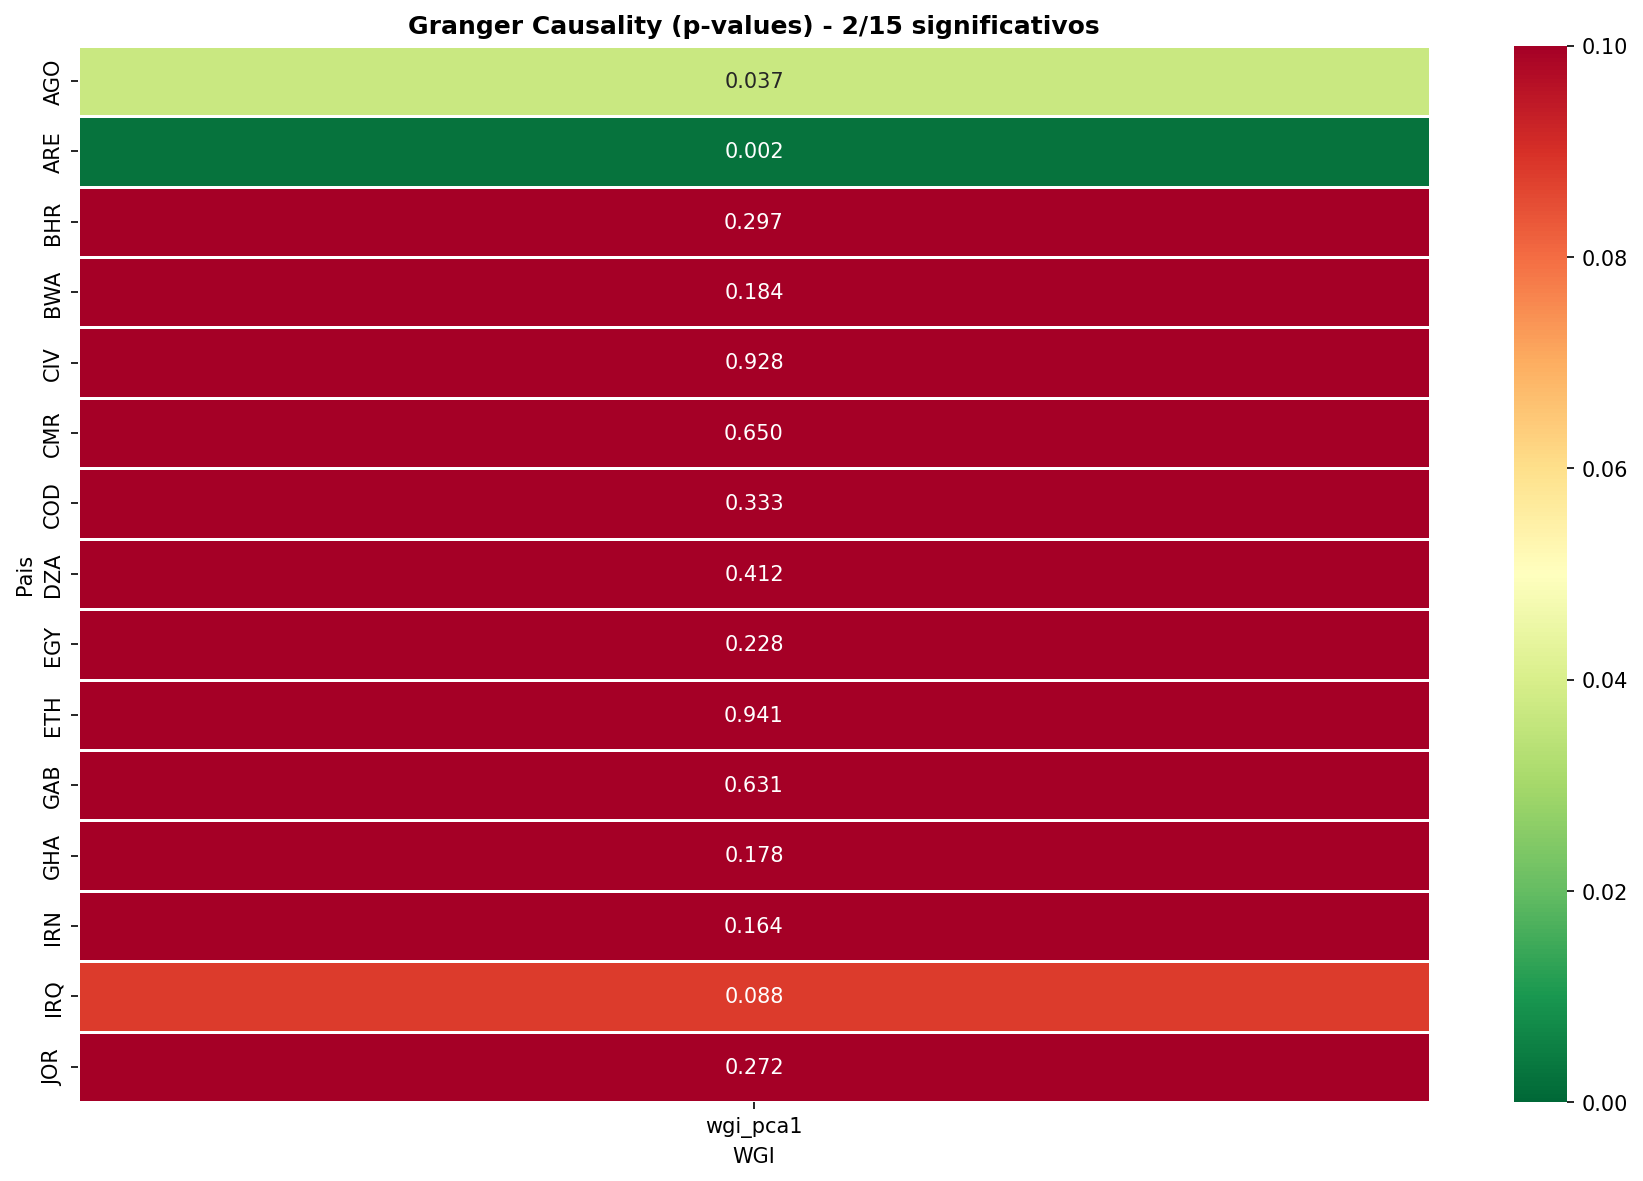

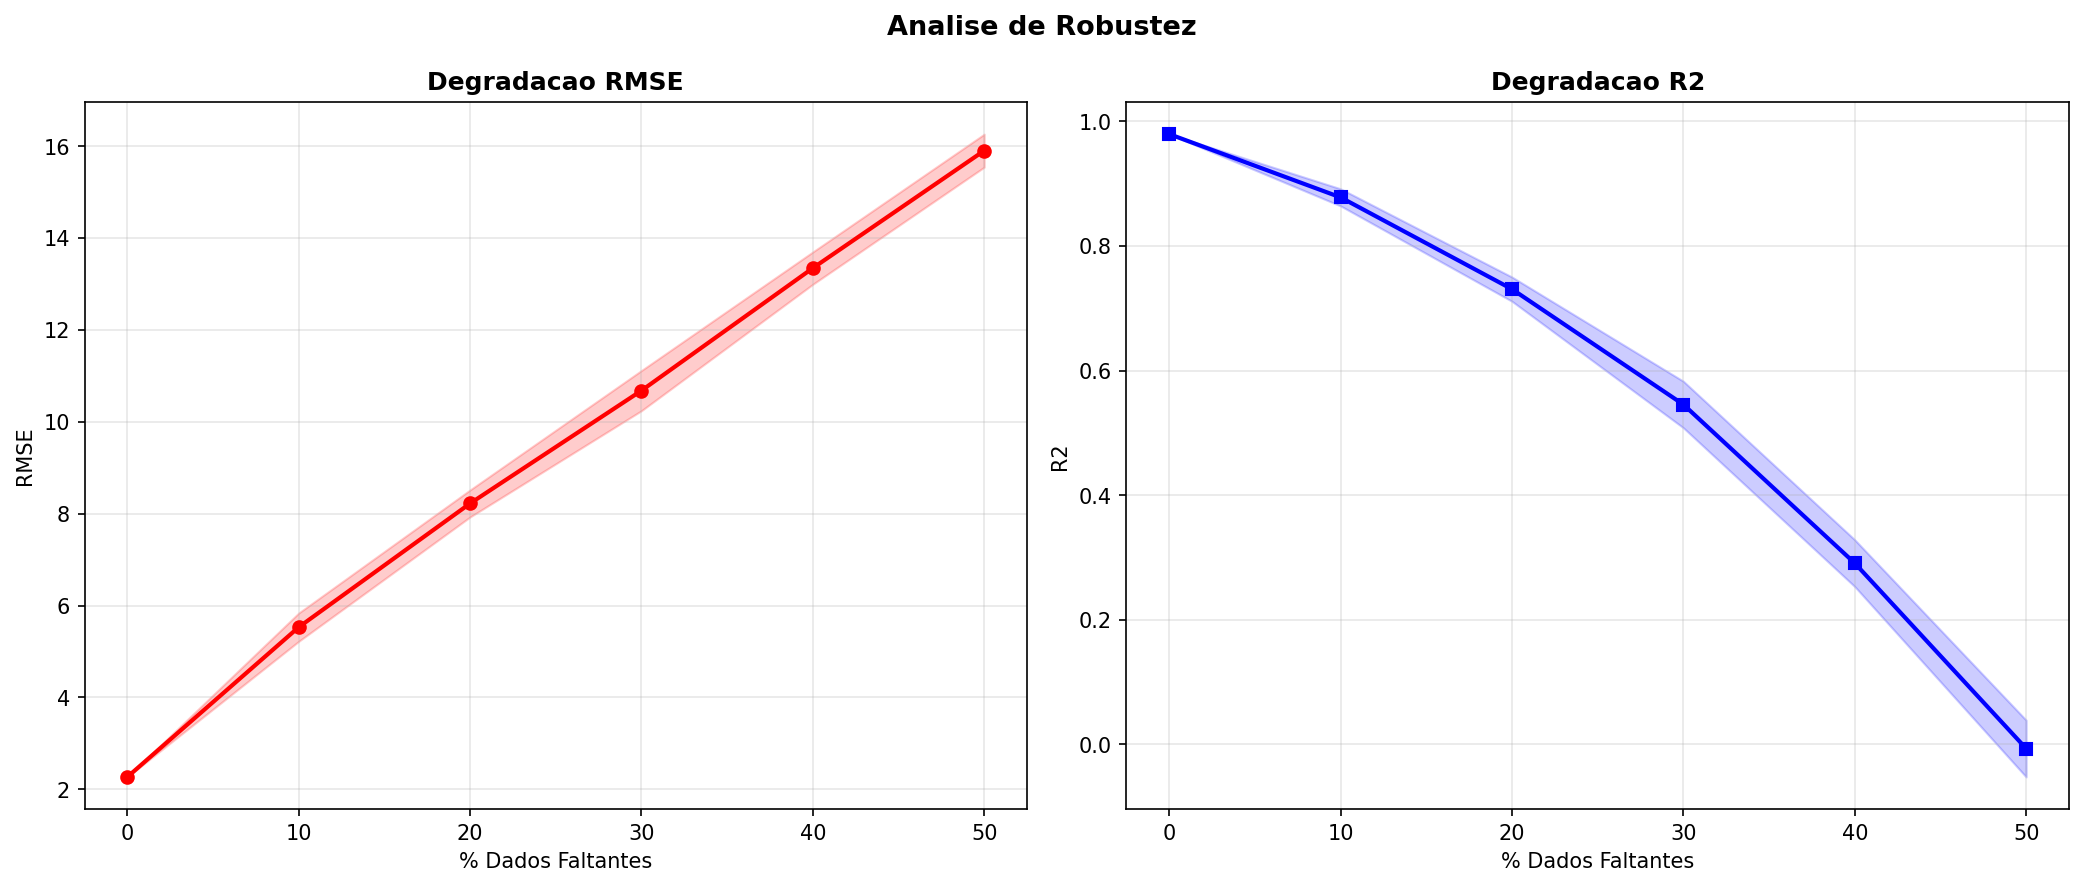

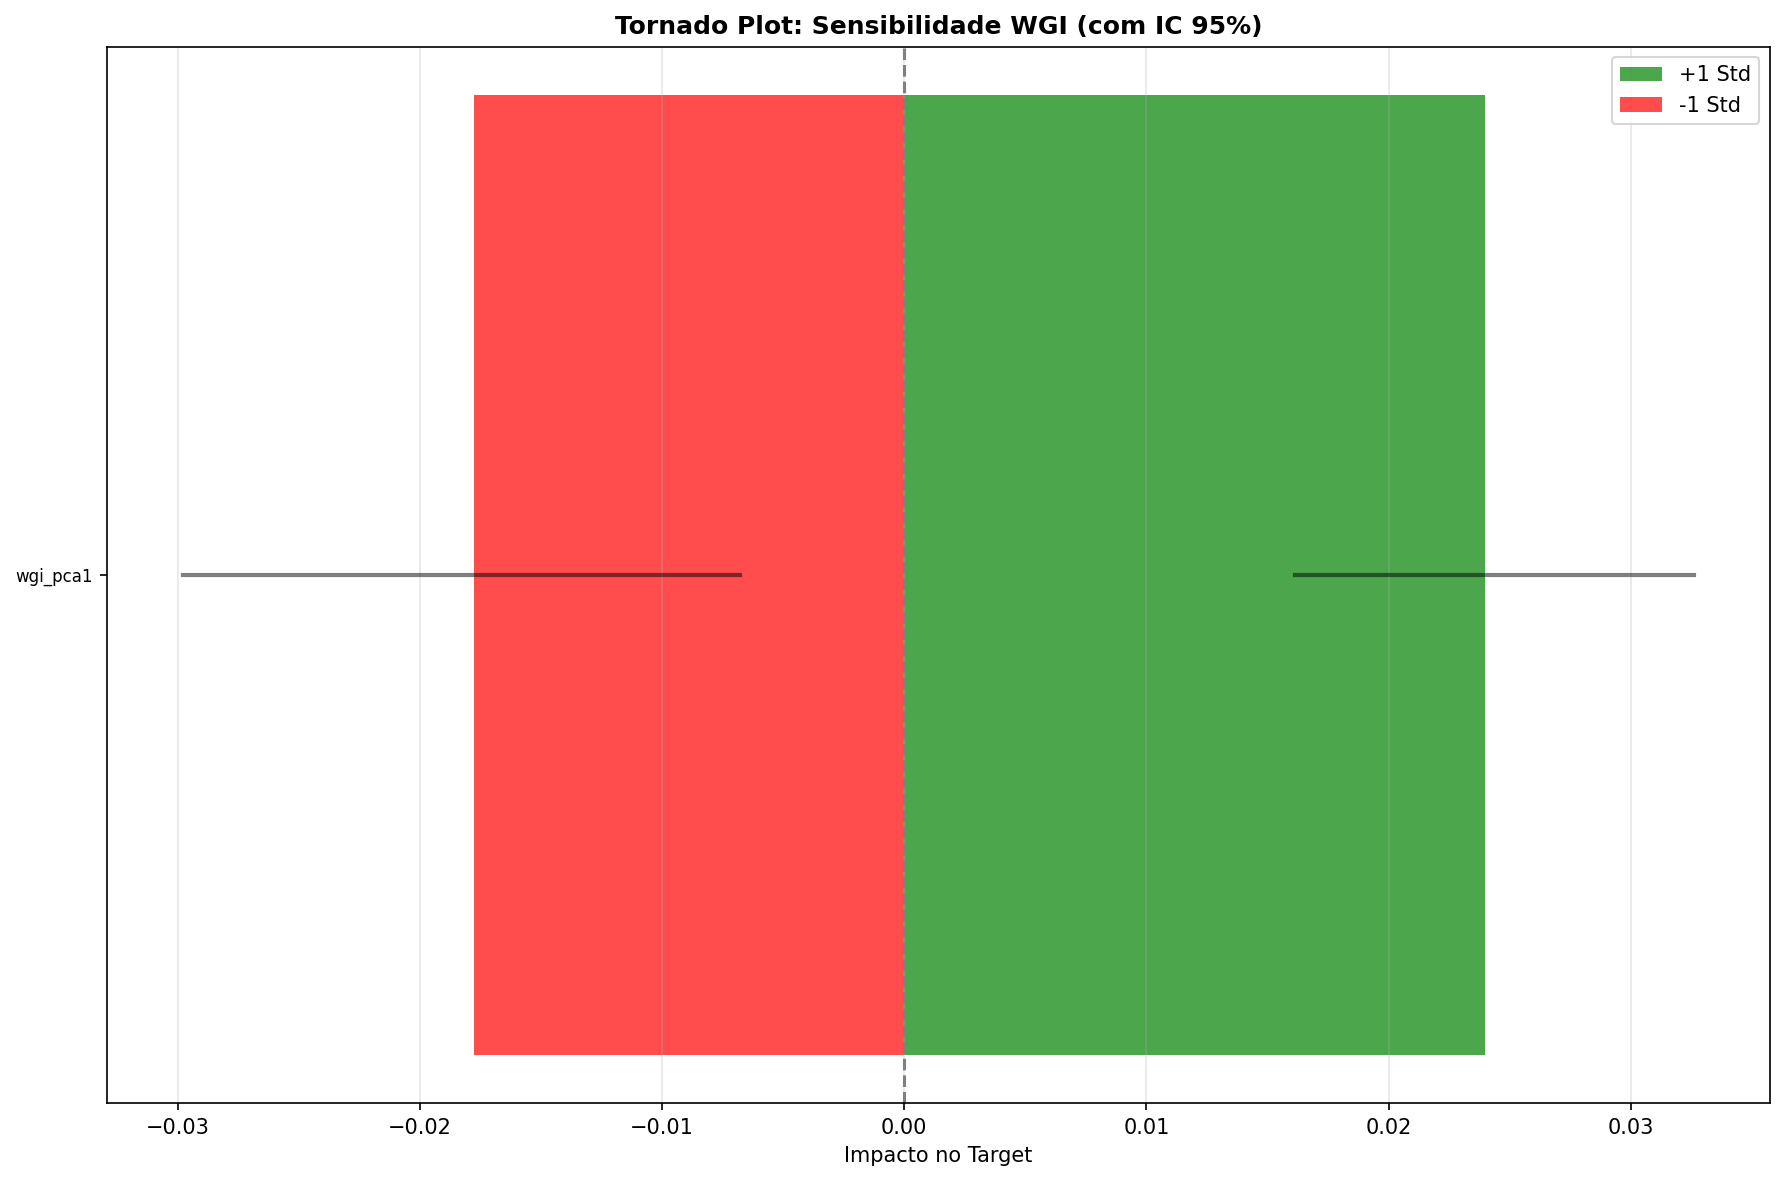


✓ 6 imagens visualizadas com sucesso!


In [50]:
# Visualizar imagens geradas no Passo 9
mostrar_imagens(['analise_avancada'], titulo='Passo 9 - Análises Avançadas')

---
## Resumo Final

In [43]:
print("\n" + "="*70)
print("  ✓ PIPELINE COMPLETO EXECUTADO COM SUCESSO!")
print("="*70)

# Resumo de tempos
tempos = {
    'Passo 1 (Extração)': tempo_p1,
    'Passo 2 (EDA Brutos)': tempo_p2,
    'Passo 2.1 (Limpeza)': tempo_p2_1,
    'Passo 2.2 (Agregação+Sintéticos)': tempo_p2_2,
    'Passo 2.3 (EDA Agregados)': tempo_p2_3,
    'Passo 3 (Features)': tempo_p3,
    'Passo 4 (Treino)': tempo_p4,
    'Passo 5 (Avaliação)': tempo_p5,
    'Passo 6 (Estratégias)': tempo_p6,
    'Passo 7 (SHAP)': tempo_p7,
    'Passo 8 (Geográfica)': tempo_p8,
    'Passo 9 (Avançada)': tempo_p9,
}

print("\n  Tempos de Execução:")
for passo, tempo in tempos.items():
    print(f"    {passo}: {tempo:.1f}s")

tempo_total = sum(tempos.values())
print(f"\n  ⏱ TEMPO TOTAL: {tempo_total:.1f}s ({tempo_total/60:.1f}m)")

print(f"\n  📁 Resultados:")
print(f"     Local (Colab): {PIPELINE_DIR}")
print(f"     Drive: {DRIVE_DIR}")

print(f"\n  📊 Ficheiros gerados:")
total_ficheiros = 0
total_imagens = 0
for d in sorted(os.listdir(PIPELINE_DIR)):
    full = os.path.join(PIPELINE_DIR, d)
    if os.path.isdir(full) and not d.startswith('.'):
        n_files = 0
        n_imgs = 0
        for root, dirs, files in os.walk(full):
            for f in files:
                n_files += 1
                if f.lower().endswith('.png'):
                    n_imgs += 1
        if n_files > 0:
            img_info = f' ({n_imgs} imagens)' if n_imgs > 0 else ''
            print(f"     📁 {d}/  ({n_files} ficheiros{img_info})")
            total_ficheiros += n_files
            total_imagens += n_imgs

print(f"\n  ✓ Total: {total_ficheiros} ficheiros gerados ({total_imagens} imagens)")
print(f"  ✓ Todos os ficheiros sincronizados com o Google Drive")


  ✓ PIPELINE COMPLETO EXECUTADO COM SUCESSO!


NameError: name 'tempo_p1' is not defined

---
## Galeria Completa de Imagens (Opcional)

Executar esta célula para ver TODAS as imagens geradas pelo pipeline de uma só vez.

In [ ]:
# Galeria completa - todas as imagens do pipeline
todos_dirs_imagens = [
    'eda_brutos',
    os.path.join('dados_limpos', 'eda_wdi'),
    os.path.join('dados_limpos', 'eda_wgi'),
    'eda_agregados',
    'eda_engenharia',
    'resultados_avaliacao',
    'analise_estrategias',
    'shap_analysis',
    'analise_geografica',
    'analise_avancada'
]
mostrar_imagens(todos_dirs_imagens, titulo='GALERIA COMPLETA - Todas as Visualizações do Pipeline')

---
## Atualizar Repositório GitHub (Opcional)

In [ ]:
# OPCIONAL: Fazer push dos resultados para o GitHub
# Descomente as linhas abaixo se quiser atualizar o repositório

# !cd {REPO_DIR} && git add -A && git commit -m "Resultados pipeline $(date +%Y-%m-%d_%H:%M:%S)" && git push
# print("✓ Resultados enviados para o GitHub")